# 🗓️ Week 07: Introduction to Unsupervised Learning and Dimensionality Reduction

**DS202A: Data Science for Social Scientists**
**Theme: Unsupervised Learning | Dataset: EU Emissions Trading System (EU ETS)**

**Date: 02 March 2026**
**Author: Dr Ghita Berrada**

---

## PART 1: FROM SUPERVISED TO UNSUPERVISED LEARNING

### What We Have Done So Far

In Weeks 2 through 5 we worked exclusively with **supervised learning**. The defining feature of supervised learning is simple: every observation in your training data comes with a label — a known answer that the model is trying to predict.

Consider what this looked like in practice:

- **Weeks 2 & 3 — ONS Local Authorities.** We predicted the unemployment rate for each local authority (a continuous outcome, so linear regression), and then asked whether an area should be classified as high or low unemployment (a binary outcome, so logistic regression). In both cases, the ONS had already measured the unemployment figure. We knew the answer for every row. The model's job was to learn the relationship between the features — population density, industry mix, qualification levels — and that known answer.

- **Week 4 — COMPAS Recidivism.** We classified defendants into risk categories (Low / Medium / High). The outcome — whether someone reoffended — had been observed and recorded. We were learning from historical cases where we already knew what happened.

- **Week 5 — S&P 500.** We tried to predict whether the market would go up or down. Again, we had historical data where the outcome (price direction the following day) was known. The lesson from Week 5 was that having a label does not guarantee you can predict it well — but you at least know what you are trying to predict.

The common structure is always:

```mermaid
flowchart LR
    A["Labelled training data<br/>(features + known outcome)"] --> B["Model training"]
    B --> C["Fitted model"]
    C --> D["Predict outcome <br/> for new observations"]
```

### What if we do not have a label?

A great deal of interesting data has no label attached. Think about what it would mean to collect data on thousands of industrial factories across Europe: their size, their sector, the country they operate in, how much CO₂ they emit each year, whether they met their regulatory obligations. None of that data comes pre-tagged with "this factory is type A" or "this factory is behaving unusually." Those categories do not exist until someone — or some algorithm — imposes them.

Or consider a different setting: imagine you work for a bank and you have transaction records for millions of customers: the amount spent, the merchant category, the time of day, the location. No one has labelled any transaction as "fraudulent" or "legitimate" (and even when fraud is eventually discovered, it is rarely flagged in real time). You have rich, detailed data about behaviour, but no outcome variable. What can you learn from it? Are there natural patterns of spending that cluster customers into meaningful types? Are there transactions so different from a customer's usual behaviour that they warrant automated review?

This is the territory of **unsupervised learning**. Instead of predicting a known answer, we are trying to discover structure that we did not know was there. The questions shift:

- Are there natural groups of observations that resemble each other? *(clustering)*
- Can we represent many correlated variables with a few meaningful dimensions? *(dimensionality reduction)*
- Which observations are so unusual that they do not fit the general pattern? *(anomaly detection)*

None of these questions have a single correct answer the way "what is the unemployment rate?" does. That makes unsupervised learning both more open-ended and, often, more scientifically interesting.

### The four families of unsupervised learning

#### 1. Dimensionality Reduction (*today's focus*)

Many datasets have dozens or hundreds of variables, but those variables are not all independent: they overlap, correlate, and partly measure the same underlying things. Dimensionality reduction methods find a compact representation of the data that preserves its essential structure while discarding redundancy.

**Example 1 — Political surveys.** A survey on political attitudes might ask 40 questions: views on immigration, taxation, welfare spending, crime, environmental regulation, and so on. These answers are not independent — someone who wants lower taxes tends also to want less regulation, and someone who favours generous welfare spending tends also to favour stronger environmental protections. Researchers have long argued that most of the variation across those 40 questions can be captured by two or three underlying dimensions — something like an economic left-right axis and a social liberal-conservative axis. Dimensionality reduction finds those dimensions automatically, without anyone deciding in advance what they should be.

**Example 2 — Health data.** A clinical dataset might record 30 blood biomarkers for each patient: cholesterol (LDL, HDL, total), triglycerides, blood glucose, insulin, C-reactive protein, and many others. Many of these are correlated — they all tend to move together in patients with metabolic syndrome. Rather than feeding all 30 into a model, a researcher might reduce them to a handful of composite scores that represent distinct physiological dimensions (metabolic health, inflammation, lipid balance). The model trained on three composite scores is more stable and easier to interpret than one trained on 30 correlated raw measurements.

The result of dimensionality reduction is always a small set of new variables — sometimes just two or three — that we can visualise, interpret, and feed into downstream models. Today we cover four methods for doing this: **PCA**, **MCA/FAMD**, **UMAP**, and **autoencoders**. Each will be introduced from first principles when we reach it.

#### 2. Clustering (*next week*)

Clustering asks whether the observations in a dataset naturally fall into groups, without those groups being defined in advance. The algorithm discovers them from patterns in the data.

**Example 1 — Customer segmentation.** A retailer has purchase history for two million customers: what they buy, how often, how much they spend, whether they respond to promotions. No one has labelled customers as "budget shopper" or "brand loyalist" — those labels do not exist yet. A clustering algorithm might nevertheless find that customers separate cleanly into a handful of distinct types: infrequent big-spenders, frequent small-basket shoppers, promotion-driven deal-seekers, and so on. Each cluster then suggests a different marketing strategy. The key point is that the groups emerged from the data; they were not defined beforehand.

**Example 2 — Medical subtyping.** Clinicians have long known that Type 2 diabetes is not a single homogeneous condition — patients respond very differently to the same treatments. A clustering study of newly diagnosed patients based on six variables (glutamate decarboxylase antibodies, age at diagnosis, BMI, HbA1c, and homoeostatic model assessment 2 estimates of β-cell function and insulin resistance) identified five distinct subtypes with meaningfully different prognoses and treatment responses — a finding that conventional diagnostic categories had obscured for decades. This work, published in *The Lancet Diabetes & Endocrinology* (Ahlqvist et al., 2018)<sup>1</sup>, is now influencing how diabetes is clinically classified.

Next week we will apply clustering to historical World Cup data. We will group national teams by performance patterns — goals scored, defensive record, tournament progression — and use the resulting clusters to think about which 2026 teams are likely to over- or under-perform.

```mermaid
flowchart LR
    A["Unlabelled data<br/>(features only)"] --> B["Clustering algorithm"]
    B --> C["Group A<br/>Group B<br/>Group C<br/>..."]
    C --> D["Interpret what<br/>each group represents"]
```

#### 3. Anomaly Detection (*Week 9*)

An anomaly is an observation that does not fit the patterns learned from the rest of the data. Anomaly detection methods score every observation by how surprising or unusual it is, then flag the most extreme ones for inspection.

**Example 1 — Government procurement.** A procurement database holds tens of thousands of contracts: each with a value, a supplier, a duration, and an award method. Most contracts look broadly similar to others in their category. But a handful might show unusual combinations — very high value awarded without competition, very short duration paired with an unusually large number of subcontractors, or a supplier appearing for the first time with a contract far larger than anything they have previously won. These are the contracts an auditor would want to examine first, not because any single feature is necessarily wrong, but because the *combination* is atypical. In Week 9 we will apply anomaly detection to exactly this kind of data: UK government contracts from the Contracts Finder database.

**Example 2 — Credit card fraud.** A bank processes millions of transactions per day, the vast majority of them legitimate. Fraud detection systems learn what "normal" looks like for each cardholder — typical transaction amounts, merchant categories, times of day, geographic locations — and then flag transactions that deviate significantly from that learned baseline. A transaction at 3am in a foreign country for an amount ten times the cardholder's usual maximum is not necessarily fraudulent, but it is anomalous enough to warrant a text alert. This is anomaly detection operating at industrial scale in real time.

In Week 9 we will cover several methods for building anomaly detectors, including Isolation Forest and Local Outlier Factor. One method — the autoencoder — we introduce today in the context of dimensionality reduction; its additional role in anomaly detection will become clear as we go.


#### 4. Association Rules (*not covered in this course*)

Association rule methods identify combinations of items or events that tend to co-occur more often than chance would predict, without any outcome variable to predict.

**Example 1 — Market basket analysis.** A supermarket analyses millions of shopping transactions and finds that customers who buy nappies on Friday evenings also tend to buy beer. Neither item predicts the other in a causal sense — but the co-occurrence is strong enough to be actionable: place them in adjacent aisles, or target the same customers with promotions for both. The classic paper introducing this idea to a broad audience is Agrawal & Srikant (1994), "Fast Algorithms for Mining Association Rules," *VLDB* <sup>2</sup>.

**Example 2 — Epidemiology.** Association rules have been used to discover unexpected comorbidities in electronic health records — combinations of diagnoses, medications, and lab results that tend to appear together in the same patients.<sup>3</sup> <sup>4</sup> A pattern like `{metformin, hypertension diagnosis} → {sleep apnoea diagnosis}` might suggest that GPs seeing patients on metformin for diabetes with hypertension should screen more actively for sleep apnoea. More recently, related ideas have been explored in the literature on phenome‑wide association studies (PheWAS), which use electronic health record–derived phenotypes to examine associations between a wide range of clinical conditions and specific genetic or environmental exposures.<sup>5</sup>

**Example 3 — Recommendation systems.** When a streaming platform suggests "because you watched X, you might like Y," the underlying logic is often association-based: users who watched both X and Y together are common enough that Y is a reasonable recommendation for someone who has only watched X so far.

These methods fall outside the scope of this course, but if you want to explore them independently, a good starting point are [Chapters 4 and 6 of *Introduction to Data Mining* (2nd Ed) by Tan, Steinbach, and Kumar](https://api.pageplace.de/preview/DT0400.9780273775324_A37747616/preview-9780273775324_A37747616.pdf), which covers the Apriori and FP-growth algorithms with worked examples.

### Why Dimensionality Reduction? The Curse of Dimensionality

Before introducing the methods, it is worth understanding why high-dimensional data is not merely inconvenient but genuinely analytically dangerous. This is what statisticians call **the curse of dimensionality**, a family of related problems that get worse as the number of variables grows.

#### Problem 1: Visualisation becomes impossible

With two variables we draw a scatterplot. With three we can manage a 3D plot. Beyond that, we have to resort to pairwise plots, i.e one scatterplot for every pair of variables. The number of such plots is:

$$\text{Number of pairwise plots} = \frac{p(p-1)}{2}$$

| Number of variables ($p$) | Pairwise plots needed |
|:---:|:---:|
| 5 | 10 |
| 10 | 45 |
| 20 | 190 |
| 50 | 1,225 |
| 100 | 4,950 |

And even a complete set of pairwise plots cannot reveal relationships that involve three or more variables simultaneously. Dimensionality reduction solves this by finding a 2D or 3D representation that captures the most important structure, giving us back the ability to look at the data.

#### Problem 2: Distances become unreliable

Many of the algorithms we will use in Weeks 7–9 (e.g clustering, nearest-neighbour methods, anomaly detection) rely on computing distances between observations. "Nearby" observations are treated as similar; "distant" observations are treated as different.

In high-dimensional spaces, something counterintuitive happens: **all points tend to become equidistant from each other**. The difference between the closest and furthest neighbour of any given point shrinks toward zero as $p$ grows. When distances become meaningless, so do all the algorithms built on them.

```mermaid
flowchart TD
    A["Low dimensions (p = 2 or 3)<br/>Points have clearly different distances<br/>'nearby' means something"] --> C["Distance-based algorithms work well<br/>Clustering, KNN, anomaly detection reliable"]
    B["High dimensions (p = 50+)<br/>All pairwise distances become similar<br/>'nearby' loses meaning"] --> D["Distance-based algorithms break down<br/>Clusters blend together, anomalies hidden"]
```

#### Problem 3: Correlated features destabilise models

When predictors are correlated, models struggle to assign stable coefficients to each one. We saw a version of this in Week 3 with the perfect separation problem in logistic regression, and earlier when adding collinear predictors increased standard errors without improving fit. With many correlated features, this instability is severe: small changes in the training data cause large swings in the estimated coefficients, and the model effectively cannot distinguish between features that carry the same information.

#### Problem 4: You need exponentially more data

To reliably estimate relationships in $p$ dimensions, the amount of data you need grows exponentially with $p$. The intuition is geometric: to cover a 1D space with points that are no more than distance $d$ apart, you need $1/d$ points. To cover a 2D space at the same density, you need $(1/d)^2$. For $p$ dimensions, you need $(1/d)^p$ — an exponential explosion.

A commonly cited rule of thumb in applied regression is that reliable estimation of regression coefficients requires on the order of **10–20 observations (or events) per parameter**. So a model with 10 parameters needs roughly 100–200 observations; a model with 50 parameters needs 500–1,000. For flexible non‑linear or highly adaptive methods, the effective data requirement is often higher. In practice, social science datasets frequently have many candidate features relative to the number of observations — a situation where dimensionality reduction is not just convenient but necessary for obtaining stable estimates.<sup>6</sup>

There is also a more fundamental geometric point. Imagine you are trying to understand a dataset by sampling it. In one dimension, if you place 10 evenly spaced points on the unit interval $[0, 1]$, they are 0.1 apart — reasonably dense. Now extend to 10 dimensions: to achieve the same density of 0.1 between neighbours, you would need $10^{10}$ — ten billion — points. Real data in high dimensions is almost always extraordinarily sparse relative to the volume of the space it nominally occupies. Patterns that look robust in a 2D projection may be artefacts of that sparsity.

#### The solution

Dimensionality reduction transforms $p$ original variables into $k$ new variables ($k \ll p$) that preserve the essential structure of the data, i.e its clusters, its gradients, its anomalies, while discarding the redundancy and noise. All four of the problems above improve when $k$ is small.

```mermaid
flowchart LR
    A["Original data<br/>p variables<br/>(correlated, redundant)"] --> B["Dimensionality<br/>Reduction"]
    B --> C["Compressed data<br/>k variables<br/>(k ≪ p, uncorrelated)"]
    C --> D["Visualisation<br/>possible"]
    C --> E["Distances<br/>meaningful"]
    C --> F["Models<br/>stable"]
    C --> G["Less data<br/>needed"]
```

---

<sup>1</sup>: Ahlqvist, Emma et al. “Novel subgroups of adult-onset diabetes and their association with outcomes: a data-driven cluster analysis of six variables.” The lancet. Diabetes & endocrinology vol. 6,5 (2018): 361-369. doi:10.1016/S2213-8587(18)30051-2


<sup>2</sup>Rakesh Agrawal and Ramakrishnan Srikant. 1994. Fast Algorithms for Mining Association Rules in Large Databases. In Proceedings of the 20th International Conference on Very Large Data Bases (VLDB '94). Morgan Kaufmann Publishers Inc., San Francisco, CA, USA, 487–499.

<sup>3</sup>: Wright, A et al. “Validation of an association rule mining-based method to infer associations between medications and problems.” Applied clinical informatics vol. 4,1 100-9. 6 Mar. 2013, doi:10.4338/ACI-2012-12-RA-0051

<sup>4</sup>: Ferreira-Santos, Daniela, and Pedro Pereira Rodrigues. “The Association Between Comorbidities and Prescribed Drugs in Patients With Suspected Obstructive Sleep Apnea: Inductive Rule Learning Approach.” *Journal of medical Internet research vol. 25 e39103*. 30 Jan. 2023, doi:10.2196/39103

<sup>5</sup>: Strayer, Nick et al. “PheWAS-ME: a web-app for interactive exploration of multimorbidity patterns in PheWAS.” Bioinformatics (Oxford, England) vol. 37,12 (2021): 1778-1780. doi:10.1093/bioinformatics/btaa870

<sup>6</sup>: The “one in ten” rule (about 10 events per variable) originates from simulation work in logistic and Cox regression; see, for example, Peduzzi, P et al. “A simulation study of the number of events per variable in logistic regression analysis.” Journal of clinical epidemiology vol. 49,12 (1996): 1373-9. doi:10.1016/s0895-4356(96)00236-3, and Concato, J et al. “Importance of events per independent variable in proportional hazards analysis. I. Background, goals, and general strategy.” Journal of clinical epidemiology vol. 48,12 (1995): 1495-501. doi:10.1016/0895-4356(95)00510-2. Later work (e.g. Vittinghoff, Eric, and Charles E McCulloch. “Relaxing the rule of ten events per variable in logistic and Cox regression.” American journal of epidemiology vol. 165,6 (2007): 710-8. doi:10.1093/aje/kwk052) shows that smaller events‑per‑variable ratios can sometimes be acceptable, so rules like “10–20 observations per parameter” should be treated as heuristics rather than strict requirements.



## PART 2: THE EU EMISSIONS TRADING SYSTEM — UNDERSTANDING THE DOMAIN

### What is a Carbon Market?

Burning fossil fuels releases CO₂ into the atmosphere. That CO₂ causes climate damage — floods, droughts, sea-level rise — but the cost of that damage is not paid by the company that burned the fuel. It is spread across society, often in other countries and future generations. Economists call this an **externality**: a cost imposed on others that is not reflected in the market price.

One way to fix this is to put a price on carbon emissions directly. If a factory has to pay for every tonne of CO₂ it emits, it now has a financial incentive to emit less. There are two main approaches:

- A **carbon tax** sets the price directly (e.g. £50 per tonne) and lets companies decide how much to reduce.
- A **cap-and-trade system** sets the *quantity* of total emissions allowed and lets the market determine the price.

The EU ETS is a cap-and-trade system. Here is how it works.

### How the EU ETS Works

**Step 1 — The cap.** Each year, the EU sets a maximum total volume of CO₂ that all covered facilities can collectively emit. This cap declines over time, so total emissions are forced down year by year.

**Step 2 — Allowances.** The cap is divided into **allowances**. One allowance = permission to emit one tonne of CO₂. Some allowances are distributed to facilities for free (based on their sector and production volume); the rest are sold at auction.

**Step 3 — Verify and surrender.** At the end of each year, every facility must have an independent auditor verify how much CO₂ it actually emitted. It must then **surrender** enough allowances to cover those verified emissions — one allowance per tonne.

**Step 4 — Trade.** If a facility emits less than its allocation, it has allowances left over — it can sell them on the carbon market. If it emits more, it must buy additional allowances. This trading is what makes it a *market*.

```mermaid
flowchart TD
    A["EU sets annual cap<br/>(total allowable emissions)"] --> B["Allowances distributed<br/>free allocation + auctions"]
    B --> C["Facilities operate throughout the year<br/>emitting CO₂"]
    C --> D["Independent auditor verifies<br/>actual emissions"]
    D --> E{"Emissions vs. allocation?"}
    E -- "Emitted LESS than allocated<br/>(surplus)" --> F["Sell surplus allowances<br/>on carbon market 💰"]
    E -- "Emitted MORE than allocated<br/>(deficit)" --> G["Buy extra allowances<br/>or face penalty ⚠️"]
    F --> H["Next year: cap declines"]
    G --> H
```

The EU ETS has been running since 2005. It is now in **Phase 4** (2021–2030), but we analyse **Phase 3** (2013–2020) because it is complete and well-documented. Phase 3 was a significant period: it introduced major reforms, including the removal of free allocation from the power sector.

### What Is an "Installation"?

In EU ETS terminology, an **installation** is any individual industrial facility that is large enough to be covered by the scheme. Think of it as one physical site with one set of equipment and one set of emissions.

Examples of installations:
- A **coal-fired power plant** in Poland: burns coal to generate electricity, emits CO₂ from the combustion process
- A **cement kiln** in Germany: heats limestone to produce clinker, releasing CO₂ both from combustion and from the chemical reaction itself
- A **steel blast furnace** in Belgium: smelts iron ore using coke, producing large volumes of CO₂
- A **oil refinery** in the Netherlands: processes crude oil into fuels, emitting CO₂ across many process units
- A **glass furnace** in Italy: melts silica sand at very high temperatures, typically fuelled by natural gas

Each of these is one installation. The EU ETS covers roughly **16,000** such installations across 30 countries. They collectively account for around 40% of total EU greenhouse gas emissions.

Each installation belongs to an **activity category**, a standardised classification of what kind of industrial process it operates. There are also finer-grained **NACE codes** (the EU's standard industrial classification system), which allow us to distinguish, say, a lime production plant from a cement plant even though both involve heating calcium carbonate.

### What Is "Compliance"?

An installation is **compliant** in a given year if it surrenders enough allowances to cover its verified emissions. Being non-compliant carries a penalty (currently €100 per excess tonne, plus the obligation to make up the shortfall the following year) — so the vast majority of installations comply every year.

The interesting variation is not in whether they comply, but in *how comfortably* they comply:

- An installation with a **surplus** surrendered fewer allowances than it held: it had room to spare and could sell the excess. This typically means either that it was very generously allocated, or that it reduced its emissions significantly.
- An installation with a **deficit** had to buy additional allowances on the market to make up the gap. This is more expensive: it means paying the carbon price on top of whatever the installation already spent on energy and operations.

The distinction between structural surplus facilities (typically in industries that received generous free allocation) and structural deficit facilities (typically power generators, who received no free allocation in Phase 3) is one of the most important dimensions of variation in this dataset, and one that dimensionality reduction (e.g PCA) will recover automatically.

### The EUTL: Where the Data Comes From

Every allowance allocation, every verified emission figure, and every surrender transaction is recorded in the **European Union Transaction Log (EUTL)**, a publicly accessible database maintained by the European Commission. This is not survey data or self-reported data: it is the official regulatory record, audited and verified.

We access this data through the `pyeutl` package, built by Jan Abrell at the Mercator Research Institute on Global Commons and Climate Change. The package downloads a cleaned, structured version of the EUTL and exposes it as pandas DataFrames.

The two tables we use are:
- **`installations`**: one row per installation — name, country, activity, NACE code, geographic coordinates, and whether it is an aircraft operator (we exclude those, as aviation operates under different rules).
- **`compliance`**: one row per installation per year — verified emissions for that year, how many allowances were allocated freely, how many were surrendered, and a compliance code indicating whether the installation met its obligations.

### Research Questions

We will pursue two questions:

> **1. What are the fundamental dimensions that characterise the compliance behaviour of EU ETS installations across Phase 3?** The dataset has many correlated variables. Can dimensionality reduction reveal a compact, interpretable structure — and can we name what those dimensions represent in policy terms?

> **2. Can low-dimensional representations of an installation's Phase 3 record predict whether it is a large emitter?** This brings dimensionality reduction into a supervised learning context: we use the compressed representation as features in a classifier, and compare it to using the raw features directly.

The first question is exploratory and unsupervised. The second connects back to the supervised learning of Weeks 2–5, using the EU ETS as the domain.

## PART 2.1 — Environment Setup

We recommend installing all dependencies using `conda` from the `conda-forge` channel, which provides better dependency resolution than pip alone. Run the following in a terminal **before** opening this notebook:

```bash
conda install -c conda-forge scikit-learn pandas numpy matplotlib seaborn umap-learn prince pytorch cpuonly
```

`pyeutl` is not yet available on conda-forge, so you'll need to install it into your conda environment with:

```bash
pip install git+https://github.com/jabrell/pyeutl.git
```

The 5 cells below imports everything and reports which optional packages are available. If a package is missing, the relevant section will fall back to a simpler alternative and print an explanation.


:::{.callout-warning title="`umap-learn`: launching JupyterLab and import hanging behaviour"}
Before running this notebook, make sure you are using **JupyterLab** rather than VS Code. VS Code handles some long-running imports less gracefully and can make it harder to tell whether a cell is still working or has genuinely crashed. JupyterLab is the recommended environment for this lecture.

**Launching JupyterLab and making your Python 3.12 kernel visible.**

You already have a Python 3.12 environment installed locally. The key step is making sure JupyterLab can see it as a kernel, rather than defaulting to a different Python installation.

1. Open a terminal and activate your Python 3.12 environment:
   ```bash
   conda activate your-env-name
   ```
   Replace `your-env-name` with whatever you named your environment when you set it up. If you are not sure, run `conda env list` to see all available environments.

2. Register the environment as a Jupyter kernel so that JupyterLab can find it:
   ```bash
   conda install -c conda-forge ipykernel
   python -m ipykernel install --user --name your-env-name --display-name "Python 3.12 (DS202)"
   ```
   You only need to do this once. The `--display-name` is what will appear in the JupyterLab kernel selector — call it something recognisable.

3. Launch JupyterLab from the same activated environment:
   ```bash
   jupyter lab
   ```
   This opens JupyterLab in your browser.

4. Open this notebook, then check that the correct kernel is selected. The kernel name appears in the top-right corner of the notebook interface. If it does not show "Python 3.12 (DS202)" (or whatever display name you chose), click on it and select the correct one from the dropdown.

If the kernel is not listed even after step 2, try closing and relaunching JupyterLab — it sometimes needs a restart to pick up a newly registered kernel.

---

**The umap import hang.** When you run `import umap` for the first time, you will notice the cell sits at `[*]` for what feels like a long time — anywhere from 30 seconds to 2 minutes. This is expected and does not mean anything has gone wrong.

Here is why it happens. The `umap` library relies on a package called `numba` to run its computations quickly. `numba` works by translating Python code into fast, low-level machine code the first time it is needed — a process called just-in-time (JIT) compilation. This translation has to happen before `umap` can do anything, and it takes time. Crucially, it produces no visible output while it is working, which is why the cell just looks frozen. Once this compilation is done, the results are saved to disk, so every subsequent import in any future session will be fast.

```python
# Run this cell and wait — it may take 1–2 minutes the first time
import umap
```

In JupyterLab you can tell the kernel is still active because the browser tab shows a spinning favicon and the cell remains marked `[*]`. Once the counter changes to a number (e.g. `[3]`), the import is complete and you can proceed.

**If it appears to hang indefinitely.** After 5 minutes with no change, it is safe to interrupt the kernel (Kernel → Interrupt Kernel) and try again. The most common cause of a genuine hang — rather than just slow compilation — is running the import while another heavy computation is still running in the background. Make sure all previous cells have finished before importing `umap`.

**Subsequent sessions.** Once the compilation has been saved to disk, future imports of `umap` in new sessions will complete in a few seconds.
:::


In [1]:
import os
os.environ["NUMBA_THREADING_LAYER"] = "tbb"

In [2]:
import umap
print("umap done")

umap done


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, precision_recall_curve, roc_curve
)
from sklearn.ensemble import ExtraTreesRegressor
print('standard imports done')

standard imports done


In [4]:
# Optional: Prince  (conda install -c conda-forge prince)
try:
    import prince
    PRINCE_AVAILABLE = True
    print("✔  prince available (MCA / FAMD)")
except ImportError:
    PRINCE_AVAILABLE = False
    print("✘  prince not found — Sections 3.2 and 3.3 will fall back to PCA on dummies\n"
          "   Install with: conda install -c conda-forge prince")

# Optional: PyTorch  (conda install -c conda-forge pytorch cpuonly)
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
    print("✔  PyTorch available")
except ImportError:
    TORCH_AVAILABLE = False
    print("✘  PyTorch not found — Section 3.5 (autoencoders) will be skipped\n"
          "   Install with: conda install -c conda-forge pytorch cpuonly")

✔  prince available (MCA / FAMD)
✔  PyTorch available


In [5]:
from pyeutl import download_data
from pyeutl.ziploader import get_installations, get_compliance

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})
SEED = 42
np.random.seed(SEED)

### 2.2 Downloading the Data

The `pyeutl` package fetches the EUTL database directly from `euets.info` as a zip file (~100 MB). The download only happens once; on subsequent runs the cached local file is used.

We load two tables:
- `df_inst` — the installation catalogue (one row per facility)
- `df_comp` — the annual compliance records (one row per facility per year), enriched with installation metadata

In [6]:
FN_ZIP = "eutl.zip"

if not os.path.exists(FN_ZIP):
    print("Downloading EUTL data (~100 MB) from euets.info — this takes a minute ...")
    download_data(fn_out=FN_ZIP)
    print("Download complete.")
else:
    print(f"Found cached data file: {FN_ZIP}")

df_inst = get_installations(FN_ZIP)
df_comp = get_compliance(FN_ZIP, df_installation=df_inst)

print(f"\nInstallation catalogue:  {df_inst.shape[0]:,} rows × {df_inst.shape[1]} columns")
print(f"Compliance records:      {df_comp.shape[0]:,} rows × {df_comp.shape[1]} columns")

Download complete.

Installation catalogue:  19,624 rows × 39 columns
Compliance records:      525,010 rows × 55 columns



### 2.3 Building the Analysis Dataset

#### From panel to cross-section

The compliance table is structured as a **long panel**: each row represents one installation in one year.

| installation_id | year | verified | allocatedFree | allocatedTotal | surrendered | ... |
|:---|:---:|---:|---:|---:|---:|:---:|
| DE_1234 | 2013 | 450,000 | 480,000 | 480,000 | 450,000 | ... |
| DE_1234 | 2014 | 430,000 | 475,000 | 475,000 | 430,000 | ... |
| DE_1234 | 2015 | 410,000 | 470,000 | 470,000 | 410,000 | ... |
| FR_5678 | 2013 | 12,000 | 14,000 | 14,000 | 12,000 | ... |
| ... | ... | ... | ... | ... | ... | ... |

Dimensionality reduction methods (PCA, MCA, FAMD, UMAP, autoencoders) all require a matrix of the form $X \in \mathbb{R}^{n \times p}$, where $n$ is the number of observations and $p$ is the number of features. We want **one row per installation** — a single vector that summarises each facility's entire Phase 3 history (2013–2020).

```mermaid
flowchart LR
    A["Installation-year panel<BR/>~110,000 rows<br/>(~16,000 installations × 8 years)"] --> B["Aggregate across<br/>2013–2020"]
    B --> C["Cross-sectional dataset<br/>~16,000 rows<br/>(one row per installation)"]
```

We are not modelling how emissions change over time — that would be a time series problem. We are asking: **what kinds of installations exist in the EU ETS, and what dimensions of variation organise them?** To answer that, we need each installation represented by a single feature vector capturing its structural and behavioural characteristics across the whole period.

#### Missingness during aggregation

Before aggregating, we need to think carefully about **which fields are missing and why**. This is not a data cleaning formality — it is substantively important. The EU ETS data encodes regulatory design decisions, and treating all NaN values as equivalent would erase that institutional structure.

The missingness in this dataset is not random noise. It reflects policy rules, eligibility criteria, and installation lifecycle events. Understanding the mechanism behind each type of missingness determines how we should treat it.

```mermaid
flowchart LR
    A["Missing value"] --> B{"Why is it missing?"}
    B --> C["Structural zero<br/>(policy rule)<br/>→ recode to zero"]
    B --> D["Lifecycle absence<br/>(entry / exit)<br/>→ average over active years"]
    B --> E["True unknown<br/>(data uncertainty)<br/>→ defer to imputation\nin Section 3.1"]
```

In the EU ETS data, most missingness falls into the first two categories. Only the third requires statistical imputation, and that happens later.

**`allocatedFree` in the power sector — structural zeros**

From 2013 onwards, power generators were excluded from free allocation by policy. This means `allocatedFree` is structurally zero for power sector installations — the absence of a value reflects a regulatory rule, not a measurement failure.

This is sometimes loosely described as MNAR (Missing Not At Random) because the probability of missingness depends on the underlying value. But that framing understates the precision of what we know here. These are not stochastically missing values whose mechanism we are inferring — they are **deterministic structural zeros** whose cause we know exactly. The regulatory rule determines the value.

If we replaced these NaNs with the column mean, a median, or a regression estimate, we would be artificially assigning free allocation to the power sector. That would distort compliance behaviour, inflate apparent surpluses for power plants, and corrupt every sectoral comparison in the analysis. We recode them to zero before aggregating.

**`verified` missing in some years — lifecycle absences**

Verified emissions can be missing because an installation had not yet entered Phase 3, temporarily suspended operations, or permanently exited the system. The missingness here depends on observable characteristics — entry year, exit year, activity type — but not directly on the unobserved emissions value itself. This is closer to **MAR (Missing At Random)** in the statistical sense.

Crucially, we are not trying to guess the missing emissions. We are asking: *what was the typical scale of this installation during the years it was active?* `pandas` `.mean()` naturally ignores NaN values, so an installation active for five of the eight Phase 3 years will have its mean computed over those five years. We are not imputing — we are summarising observed activity, which is exactly what we want.

**`allocatedNewEntrance` and `allocated10c` — eligibility-based zeros**

These fields are only populated for installations that qualified for specific allocation mechanisms: the new entrant reserve and the Article 10c derogation for certain power sectors in newer member states. A NaN here does not mean "unknown" — it means the installation was not eligible. Again, these are structural zeros and we recode them accordingly before computing total allocation aggregates.

**Why we do not drop observations**

A common reflex when encountering missing data is to drop rows with NaN values. Here, that would be analytically disastrous. Dropping installations with missing `allocatedFree` would remove the entire power sector — some of the largest emitters in the dataset, and precisely the facilities most exposed to carbon price risk, since they had to purchase every allowance at auction. Their structural position is not a complication to be removed; it is one of the most important features of the EU ETS to understand.

The principle at this stage is:

> Preserve all installations and treat missingness according to its mechanism: structural zeros are recoded to zero; lifecycle absences are handled naturally by mean aggregation over active years.

**Why imputation comes later**

At this stage we are constructing installation-level summaries from observed data — we are not yet building a matrix for PCA or UMAP. Later, in Section 3.1, some derived features will genuinely be undefined: `emissions_slope` for installations with fewer than four valid years, or `emissions_cv` for those with very short activity periods. These are true analytic unknowns, and that is the appropriate moment for statistical imputation.

The aggregation stage is about respecting institutional logic. The modelling stage is about numerical completeness. Conflating the two leads to the kind of silent data distortion that is very hard to detect and diagnose after the fact.

#### Feature construction

We construct four families of features, each capturing a distinct economic dimension of each installation's Phase 3 record. For each family we explain what we are measuring, why we have chosen this particular summary statistic, and what preprocessing choices follow from the nature of the variable.

**1 — Scale**

*What it measures:* the typical size of the installation — how much it emits, how much allocation it receives, and how much it surrenders in a typical Phase 3 year.

We compute the mean over Phase 3 years of:
- `verified` — mean annual verified emissions (tCO₂)
- `allocatedFree` — mean annual free allocation (recoded from NaN to zero for power sector installations, as discussed above)
- `allocatedTotal` — mean annual total allocation (free + auction entitlements + new entrant reserve + Article 10c contributions)
- `surrendered` — mean annual surrendered allowances

*Why the mean?*

We want each installation's typical annual scale, not a figure for any single year that might be atypical. A factory that had an unplanned shutdown in 2016 — and therefore emitted half its usual volume that year — should not appear artificially small. Averaging across the eight Phase 3 years smooths out these transient fluctuations and gives us a stable characterisation of structural size.

*Why transform the scale variables at all?*

Before deciding *how* to transform, it is worth being clear about *what problem* we are solving. Emissions volumes across EU ETS installations span several orders of magnitude: a small district heating network might emit 5,000 tCO₂ per year; a large coal power station might emit 20 million. This creates two distinct problems depending on the method being applied:

- **For PCA**: PCA finds directions of maximum variance. On the raw scale, the variance is dominated almost entirely by the handful of very large installations. The first principal component will essentially be a contrast between "very large" and "not very large", and all the substantive variation among the thousands of medium and small installations — which is where most of the policy-relevant diversity actually lies — will be compressed into later components that explain very little variance. The resulting analysis would be almost uninformative.

- **For distance-based methods** (UMAP, clustering in Week 8): a difference of 1 million tonnes between two large power stations will completely swamp a difference of 50,000 tonnes between two medium-sized industrial facilities, even if the latter distinction is analytically more meaningful. Neighbourhood graphs in UMAP will be distorted: large installations will appear close to each other simply because they are large, regardless of whether they actually behave similarly in terms of compliance posture or trajectory.

Standardisation alone does not solve this. Standardisation — subtracting the mean and dividing by the standard deviation — rescales each variable so that features with different units contribute equally to variance. It fixes the *between-variable* scale problem. But it does nothing about the *shape* of the distribution within a single variable. If `mean_verified` is heavily right-skewed before standardisation, it remains heavily right-skewed after — the skew has just been shifted and rescaled. The outlying large emitters still sit far out on the right tail, still exert disproportionate influence on the principal components, and still distort neighbourhood calculations. Standardisation is necessary but not sufficient.

What we actually need is a transformation that makes the distribution more symmetric and compresses the heavy right tail — so that the subsequent standardisation is applied to something well-behaved. This is a question about distribution shape, not about scale.

*Why log, specifically?*

The natural candidate is a log-transformation, and we have both a substantive and an empirical reason to prefer it here.

The substantive reason is that emissions from industrial facilities scale multiplicatively with production capacity, fuel consumption, and operating hours. When a quantity is the product of many independent multiplicative factors, the central limit theorem implies that its logarithm will be approximately normally distributed. Emissions volumes are genuinely expected to be log-normal — this is not just a convenient approximation but a physically motivated prior. The same logic applies to allocation volumes, which are set by regulators as a function of production benchmarks and capacity.

The empirical check is straightforward: if the log-transform is appropriate, the transformed distributions should look approximately symmetric and bell-shaped. We verify this visually in the exploration section below.

A more flexible alternative would be the **Yeo-Johnson transformation**, which estimates the optimal power parameter $\lambda$ from the data and handles negative values. When $\lambda = 0$, Yeo-Johnson reduces to the log-transform; other values correspond to square-root ($\lambda = 0.5$), no transformation ($\lambda = 1$), or more aggressive compressions. If the estimated $\lambda$ values were far from zero for our volume variables, that would be a signal that the log is not the best choice. In a pure prediction pipeline where interpretability is secondary, Yeo-Johnson would be defensible and possibly superior.

We use the log-transform rather than Yeo-Johnson for two reasons. First, interpretability: a one-unit difference on the log scale is a tenfold difference in raw emissions, which is a meaningful and communicable quantity. Yeo-Johnson with $\lambda = 0.3$ has no analogous substantive interpretation. Second, transparency: we can justify the log-transform from first principles rather than delegating the choice to an optimisation routine whose output requires additional explanation. In a research or policy context where the preprocessing choices will be scrutinised, the simpler, principled choice is preferable when it is approximately correct — and here we have good reason to believe it is.

*Why $\log(1 + x)$ rather than $\log(x)$?*

Two reasons. First, `allocatedFree` is genuinely zero for power sector installations after recoding — $\log(0)$ is undefined, but $\log(1 + 0) = 0$, which correctly places zero-allocation installations at the bottom of the transformed scale. Second, `surrendered` is in rare cases zero for installations whose obligations were cancelled or transferred mid-phase. The $\log(1 + x)$ form handles both cases without requiring additional special-casing or filtering.

Note that `mean_surplus` — the mean annual difference between total allocation and verified emissions — is **not** log-transformed. It can be negative for installations in structural deficit, and log-transforms are only defined for non-negative values. It remains on the raw scale.

**2 — Compliance behaviour**

*What it measures:* how each installation managed its allowance obligations across Phase 3 — not just how large it was, but whether it was a systematic buyer or seller of allowances, and how consistently it met its obligations without penalty.

Two installations can be identical in size but very different in compliance behaviour. A cement plant that was generously benchmarked relative to its actual production will have a persistent surplus every year — it is a structural seller, effectively being paid to participate in the scheme. A power plant that purchased all its allowances at auction will have near-zero surplus or a deficit in years when the carbon price was unexpectedly high — it bears the full cost of the scheme with no buffer. These are fundamentally different regulatory positions, and scale features alone cannot distinguish them.

We capture this with three features:

- `compliance_rate` — the fraction of Phase 3 years in which `verified` ≤ `surrendered`. This measures how consistently the installation met its obligations without incurring penalties. Most installations comply in most years, so this variable has limited variance — but the installations that do not comply consistently are analytically important.

- `n_years_deficit` — the count of years in which `verified` > `surrendered`. This is related to but not redundant with `compliance_rate`. An installation that ran a deficit in seven of eight years is structurally different from one that had a single bad year due to an exceptional event: the former has a chronic structural problem, the latter had a transient shock. The count captures this persistence in a way that the rate does not.

- `mean_surplus` — the mean annual difference between `allocatedTotal` and `verified`. A large positive value means the installation was systematically over-allocated and could sell its surplus; a large negative value means it was a systematic buyer. This is arguably the most direct measure of the carbon price exposure each installation faced across Phase 3.

These variables do not require a log-transform. `compliance_rate` is bounded between zero and one and is not skewed in a way that would cause the problems described above. `mean_surplus` can be negative and is therefore ineligible for a log-transform regardless. `n_years_deficit` is an integer count bounded by the number of Phase 3 years — a minor right skew is possible but not of a magnitude that would distort PCA or distance calculations.

**3 — Emissions trajectory**

*What it measures:* how each installation's verified emissions evolved over Phase 3 — was it decarbonising, growing, or stable? How volatile were its annual emissions?

These features are different in character from the scale and compliance features: they capture *dynamics* rather than levels. An installation's mean emissions tell us how large it is; its emissions slope tells us which direction it is heading.

- `emissions_slope` — the slope of an OLS regression of annual verified emissions on year, estimated within each installation's Phase 3 record. A negative slope means the installation was on a declining emissions trajectory over the period — either decarbonising its production processes, switching to lower-carbon fuels, or reducing output. A positive slope means emissions were growing.

$$\text{slope} > 0 \Rightarrow \text{growing emissions} \qquad \text{slope} < 0 \Rightarrow \text{decarbonising}$$

This is arguably the most policy-relevant feature in the dataset. An installation with declining emissions is responding to the carbon price signal; one with rising emissions is not — regardless of whether it is currently compliant. The slope is estimated in raw tCO₂ per year rather than on the log scale, because we want to capture the absolute rate of change, which is what matters for the aggregate emissions trajectory of the EU ETS.

- `emissions_cv` — the coefficient of variation of annual verified emissions, defined as the standard deviation divided by the mean. A high CV indicates volatile emissions from year to year, which is typical of facilities whose output fluctuates with energy market conditions, commodity demand, or weather. A low CV indicates stable, predictable operations. This matters because volatile emitters behave differently in the allowance market: they are less able to plan their compliance position in advance and more likely to be active traders.

*Why require at least four Phase 3 years?*

Both trajectory features are undefined or unreliable when computed from very few observations:

| Years available | Reliability |
|:---:|:---|
| 2 | Meaningless — any two points define a line exactly, slope is pure noise |
| 3 | Very unstable — a single outlier year can reverse the sign of the slope |
| 4 | Minimally reliable — our cutoff |
| 6+ | Robust |

Installations with fewer than four Phase 3 records are typically facilities that entered or exited the scheme mid-phase — new capacity coming online late in the period, or plants that permanently closed. Rather than dropping them from the dataset entirely, we retain them but their trajectory features will be NaN. As discussed above, this is a genuine analytic unknown that we address through imputation in Section 3.1, not a structural zero that should be recoded.

**4 — Structural characteristics**

*What it measures:* what the installation is and where it operates — fixed institutional characteristics that do not vary across years and that determine the regulatory context within which each facility operates.

Unlike the numeric features above, these are categorical variables. They are retained as categoricals for the MCA and FAMD analyses in Sections 3.3 and 3.4, where the correct distance metric for categorical data is applied. They should not be one-hot encoded before PCA — as we discuss in Section 3.2, one-hot encoding before PCA uses the wrong geometry and produces uninterpretable loadings.

From the raw data we retain:

- `country` — the EU member state (or Norway, Iceland, Liechtenstein) in which the installation is located. This captures national-level differences in energy mix, industrial structure, grid carbon intensity, and the generosity of historical allocation decisions. A German coal plant and a French nuclear-adjacent industrial facility operate in very different energy market contexts even if they have similar emissions volumes.

- `activityCategory` — the broad EU ETS activity type defined in the EU ETS directive: combustion installations, oil refineries, coke ovens, metal ore roasting, iron and steel production, cement, lime, glass, ceramics, pulp and paper, chemicals, aluminium, and others. This is the primary determinant of free allocation benchmarks in Phase 3 — each sector had its own product benchmark set at the level of the most efficient 10% of EU installations.

- `naceCategory` — the EU standard industrial classification, more granular than `activityCategory`. This distinguishes, for example, between basic chemical production and speciality chemicals within the same activity category, or between integrated steel mills and electric arc furnaces in the steel sector. These distinctions matter for understanding emissions intensity variation within broad activity categories.

- `region` — the sub-national region of the installation, where populated. This captures intra-country variation in industrial structure that `country` alone misses: a Spanish installation in Andalusia operates in a different industrial ecosystem from one in the Basque Country, even holding sector constant.

We take all four characteristics from the **first available Phase 3 year** per installation. They are structural characteristics that should not change across years — the activity category and NACE code of a facility are determined by its physical equipment and processes, not by annual reporting choices. Where occasional reclassifications occur in the raw data, anchoring to the first year is the most conservative and reproducible approach.

We restrict to **stationary installations** (excluding aviation, which operates under different rules) and require at least four years of Phase 3 data so that the trajectory metrics are meaningful.

In [7]:
# ── Phase 3 filter ────────────────────────────────────────────────────────────
# isAircraftOperator is a Python boolean (not a string) in this dataset.
# We use ~ (bitwise NOT) rather than == False for clarity and to handle
# any NaN values in that column safely.
phase3 = df_comp[
    (df_comp['year'].between(2013, 2020)) &
    (df_comp['isAircraftOperator'] == False)
].copy()

print(f"Phase 3 stationary records:  {phase3.shape[0]:,}")
print(f"Unique installations:         {phase3['installation_id'].nunique():,}")
print(f"Years covered:                {sorted(phase3['year'].unique())}")
phase3.head(15)


Phase 3 stationary records:  143,368
Unique installations:         17,921
Years covered:                [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]


,id,installation_id,year,reportedInSystem_id,euetsPhase,compliance_id,allocatedFree,allocatedNewEntrance,allocatedTotal,allocated10c,...,shippingCompanyType,shippingCompany,imoID,region,activity,activityCategory,registry,country,nace,naceCategory
186,AT_106_2013,AT_106,2013,euets,2013-2020,NaN,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,Combustion installations with a rated thermal ...,Combustion,Austria,Austria,Manufacture of man-made fibres,"Manufacturing: Refineries, chemicals, and pha..."
187,AT_106_2014,AT_106,2014,euets,2013-2020,NaN,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,Combustion installations with a rated thermal ...,Combustion,Austria,Austria,Manufacture of man-made fibres,"Manufacturing: Refineries, chemicals, and pha..."
188,AT_106_2015,AT_106,2015,euets,2013-2020,NaN,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,Combustion installations with a rated thermal ...,Combustion,Austria,Austria,Manufacture of man-made fibres,"Manufacturing: Refineries, chemicals, and pha..."
189,AT_106_2016,AT_106,2016,euets,2013-2020,NaN,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,Combustion installations with a rated thermal ...,Combustion,Austria,Austria,Manufacture of man-made fibres,"Manufacturing: Refineries, chemicals, and pha..."
190,AT_106_2017,AT_106,2017,euets,2013-2020,NaN,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,Combustion installations with a rated thermal ...,Combustion,Austria,Austria,Manufacture of man-made fibres,"Manufacturing: Refineries, chemicals, and pha..."
191,AT_106_2018,AT_106,2018,euets,2013-2020,NaN,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,Combustion installations with a rated thermal ...,Combustion,Austria,Austria,Manufacture of man-made fibres,"Manufacturing: Refineries, chemicals, and pha..."
192,AT_106_2019,AT_106,2019,euets,2013-2020,NaN,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,Combustion installations with a rated thermal ...,Combustion,Austria,Austria,Manufacture of man-made fibres,"Manufacturing: Refineries, chemicals, and pha..."
193,AT_106_2020,AT_106,2020,euets,2013-2020,NaN,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,Combustion installations with a rated thermal ...,Combustion,Austria,Austria,Manufacture of man-made fibres,"Manufacturing: Refineries, chemicals, and pha..."
212,AT_83_2013,AT_83,2013,euets,2013-2020,A,5743.0,NaN,5743,NaN,...,NaN,NaN,NaN,NaN,Combustion of fuels,Combustion,Austria,Austria,"Electric power generation, transmission and di...",Energy: Electricity generation
213,AT_83_2014,AT_83,2014,euets,2013-2020,A,5140.0,NaN,5140,NaN,...,NaN,NaN,NaN,NaN,Combustion of fuels,Combustion,Austria,Austria,"Electric power generation, transmission and di...",Energy: Electricity generation


In [8]:
# ── Recode structural zeros ───────────────────────────────────────────────────
# allocatedFree, allocatedNewEntrance, and allocated10c are NaN for installations
# that were not eligible for those allocation mechanisms — power sector
# installations received no free allocation in Phase 3, and most installations
# did not qualify for new entrant reserve or Article 10c derogation allocations.
# These are deterministic structural zeros, not unknown values. Leaving them as
# NaN would cause .mean() to silently ignore those years, as if the installation
# had no allocation record at all. We recode to zero before aggregating.
cols_structural_zero = ['allocatedFree', 'allocatedNewEntrance', 'allocated10c']
existing = [c for c in cols_structural_zero if c in phase3.columns]
phase3[existing] = phase3[existing].fillna(0)

In [9]:
# ── Recompute allocatedTotal where NaN ───────────────────────────────────────
# allocatedTotal may still be NaN for rows where it was not populated directly
# by the EUTL but whose components we have now recoded to zero. We recompute it
# as the row-wise sum of its components using .sum(axis=1), which treats any
# remaining NaN values as zero — correct given the recoding above.
# Where allocatedTotal is already populated we leave it untouched, since it
# may include auction entitlements not captured in the component columns.
missing_total = phase3['allocatedTotal'].isna()
if missing_total.any():
    print(f"Recomputing allocatedTotal for {missing_total.sum():,} rows where it is NaN")
    phase3.loc[missing_total, 'allocatedTotal'] = (
        phase3.loc[missing_total, ['allocatedFree', 'allocatedNewEntrance', 'allocated10c']]
        .sum(axis=1)
    )

In [10]:
# ── Emissions slope function ──────────────────────────────────────────────────
def emissions_slope(series):
    """Fit a straight line to verified emissions over time and return the slope.

    A negative slope means emissions fell during Phase 3 (decarbonisation).
    A positive slope means they rose.

    Returns NaN if fewer than 4 data points — a minimum of 4 years is required
    for a slope estimate to be sufficiently stable (2 points define a line
    trivially; 3 is highly sensitive to a single outlier year). See Section 2.3
    for the rationale behind this threshold.
    """
    s = series.dropna()
    if len(s) < 4:
        return np.nan
    return np.polyfit(np.arange(len(s)), s.values, 1)[0]

In [11]:
# ── Aggregate to cross-section ────────────────────────────────────────────────
# Each installation is summarised into a single row capturing its typical scale,
# compliance behaviour, and emissions trajectory across Phase 3.
# .mean() ignores NaN by default, so installations active for fewer than 8 years
# are averaged over the years they were active — this is the correct behaviour
# for lifecycle absences (see Section 2.3 on missingness mechanisms).
grp = phase3.groupby('installation_id')

agg = pd.DataFrame({
    # Scale: typical annual volumes across Phase 3
    'mean_verified':        grp['verified'].mean(),
    'mean_allocated':       grp['allocatedFree'].mean(),
    'mean_surrendered':     grp['surrendered'].mean(),
    'mean_allocated_total': grp['allocatedTotal'].mean(),
    # Trajectory: how many Phase 3 years does this installation have?
    # Used below to enforce the minimum 4-year threshold.
    'n_years_reported':     grp['verified'].count(),
    # Compliance behaviour
    'n_years_deficit':      grp.apply(lambda d: (d['surrendered'] < d['verified']).sum()),
    'compliance_rate':      grp.apply(lambda d: (d['surrendered'] >= d['verified']).mean()),
    'mean_surplus':         grp.apply(lambda d: (d['allocatedTotal'] - d['verified']).mean()),
    # Trajectory
    'emissions_slope':      grp['verified'].apply(emissions_slope),
    'emissions_cv':         grp['verified'].std() / grp['verified'].mean(),
})

In [12]:
# ── Attach static metadata ────────────────────────────────────────────────────
# Country, activity, and sector are structural characteristics that do not vary
# across years. We take them from the first available Phase 3 year per
# installation — the most conservative and reproducible choice when occasional
# reclassifications occur in the raw data.
meta = (
    phase3.sort_values('year')
    .groupby('installation_id')
    .first()[['country', 'activity', 'activityCategory', 'naceCategory', 'region']]
)
df = agg.join(meta)

In [13]:
# ── Enforce minimum Phase 3 coverage ─────────────────────────────────────────
# Installations with fewer than 4 years of Phase 3 data are retained in the
# dataset but their trajectory features (emissions_slope, emissions_cv) will
# be NaN — these are true analytic unknowns addressed by imputation in
# Section 3.1, not structural zeros. Installations with fewer than 4 years
# are excluded here because even their scale and compliance features are
# too unstable to be representative of their structural position.
df = df[df['n_years_reported'] >= 4].copy()


In [14]:
# ── Log-transform volume variables ───────────────────────────────────────────
# We apply log(1+x) to the four volume variables to address their heavy right
# skew before standardisation and before any distance-based computation.
# This is a distributional correction (making the within-variable shape more
# symmetric), not a scaling step — standardisation handles scale separately.
# log(1+x) rather than log(x) because allocatedFree is genuinely zero for
# power sector installations after recoding above, and log(0) is undefined.
# .clip(lower=0) is a safeguard against any residual floating-point negatives
# introduced during recomputation of allocatedTotal.
vol_cols = ['mean_verified', 'mean_allocated', 'mean_surrendered', 'mean_allocated_total']
log_cols = [f'log_{c}' for c in vol_cols]
df[log_cols] = np.log1p(df[vol_cols].clip(lower=0))

print(f"Cross-sectional dataset:  {df.shape[0]:,} installations × {df.shape[1]} features")
df.head(3)

Cross-sectional dataset:  10,928 installations × 19 features


,mean_verified,mean_allocated,mean_surrendered,mean_allocated_total,n_years_reported,n_years_deficit,compliance_rate,mean_surplus,emissions_slope,emissions_cv,country,activity,activityCategory,naceCategory,region,log_mean_verified,log_mean_allocated,log_mean_surrendered,log_mean_allocated_total
installation_id,,,,,,,,,,,,,,,,,,,
AT_1,46083.750,39539.0,46083.750000,39539.0,8,0,1.000,-6544.750,-709.833333,0.072609,Austria,"Production of lime, or calcination of dolomite...",Cement/Lime,"Manufacturing: Glas, ceramic, and stones",None,10.738237,10.585068,10.738237,10.585068
AT_10,57232.250,47360.5,57232.250000,47360.5,8,0,1.000,-9871.750,438.666667,0.040020,Austria,Manufacture of glass,Glass/Ceramics,"Manufacturing: Glas, ceramic, and stones",None,10.954890,10.765565,10.954890,10.765565
AT_101,7172.875,251.0,8197.571429,251.0,8,0,0.875,-6921.875,-4125.988095,1.844943,Austria,Combustion of fuels,Combustion,Energy: Electricity generation,None,8.878201,5.529429,9.011715,5.529429


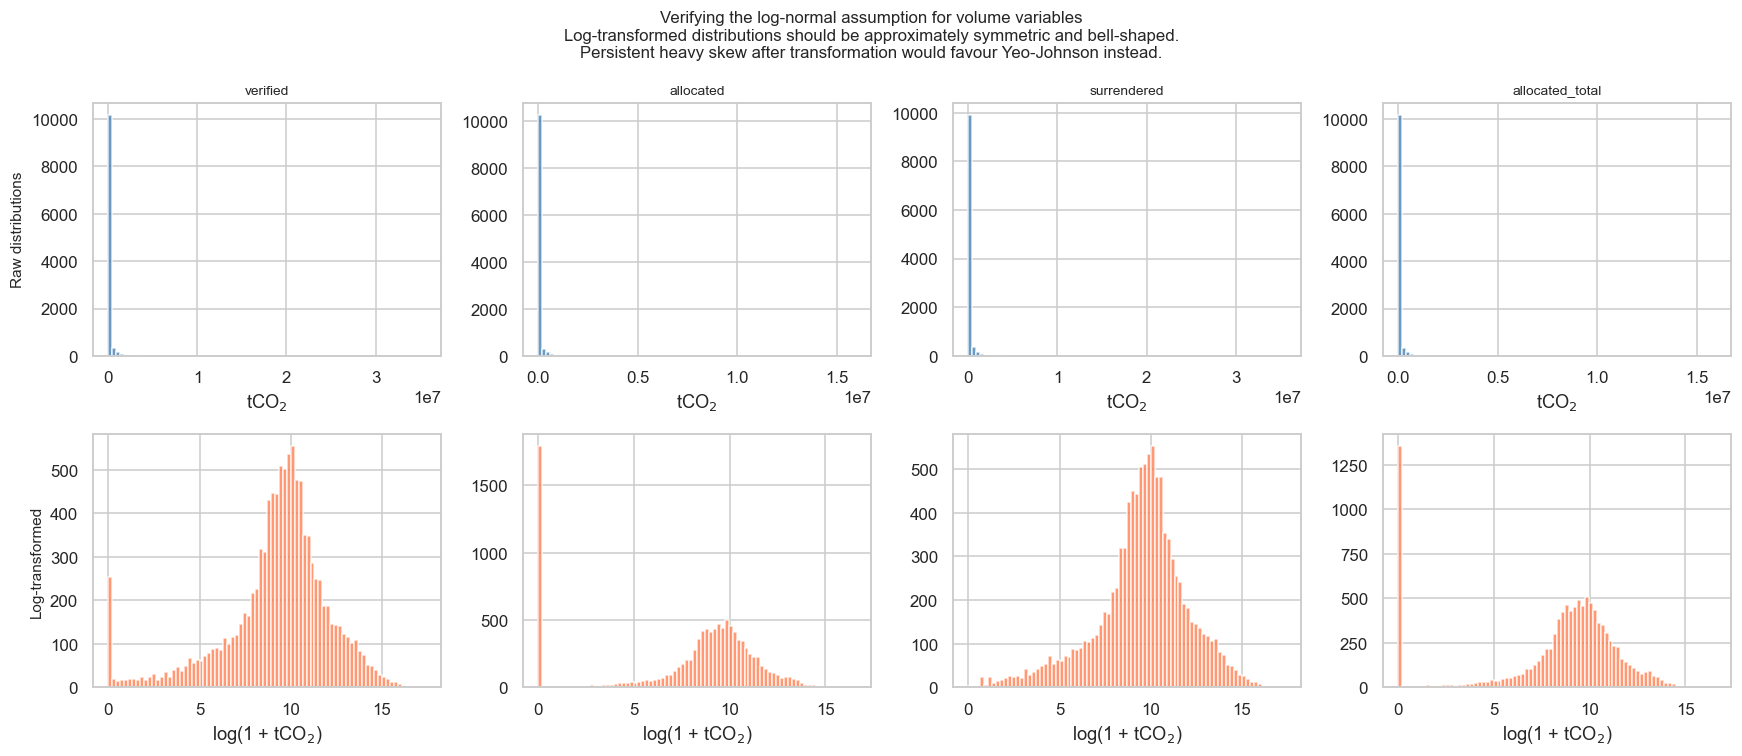

In [15]:
# ── Verify the log-normal assumption visually ─────────────────────────────────
# The write-up justifies log-transformation on the grounds that emissions volumes
# are expected to be log-normally distributed (multiplicative scaling processes).
# We verify this here: the log-transformed distributions should look approximately
# symmetric and bell-shaped. Persistent heavy skew after transformation would
# be evidence that Yeo-Johnson is warranted instead.
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

axes[0, 0].set_ylabel('Raw distributions', fontsize=10)
axes[1, 0].set_ylabel('Log-transformed', fontsize=10)

for ax, col in zip(axes[0], vol_cols):
    ax.hist(df[col].dropna(), bins=80,
            color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col.replace('mean_', ''), fontsize=9)
    ax.set_xlabel('tCO$_2$')

for ax, col in zip(axes[1], log_cols):
    ax.hist(df[col].dropna(), bins=80,
            color='coral', edgecolor='white', alpha=0.8)
    ax.set_xlabel('log(1 + tCO$_2$)')

plt.suptitle(
    'Verifying the log-normal assumption for volume variables\n'
    'Log-transformed distributions should be approximately symmetric and bell-shaped.\n'
    'Persistent heavy skew after transformation would favour Yeo-Johnson instead.',
    fontsize=11
)
plt.tight_layout()
plt.show()

In [16]:
# ── Empirically verify log vs Yeo-Johnson ────────────────────────────────────
# The Yeo-Johnson transformation is a family of power transformations indexed
# by a parameter λ, estimated from the data by maximum likelihood:
#
#   λ = 0   →  log(x + 1)          (the log-transform we are using)
#   λ = 0.5 →  square root
#   λ = 1   →  no transformation
#   λ = 2   →  square
#   λ < 0   →  reciprocal-type transformations
#
# When we fit Yeo-Johnson to a variable, sklearn searches for the value of λ
# that makes the transformed distribution as close to normal as possible
# (via maximum likelihood under a normality assumption). The estimated λ
# therefore tells us what the data itself suggests is the optimal transformation.
#
# If the estimated λ is close to 0, the data is telling us that the log-transform
# is approximately optimal — our choice is empirically justified.
#
# If the estimated λ is far from 0 for a given variable, that is a signal that
# the log is not the right transformation for that variable: the distribution
# may need a stronger compression (λ < 0) or a milder one (λ closer to 1),
# and we should consider using Yeo-Johnson directly in the preprocessing
# pipeline rather than the manual log-transform.
#
# We use a threshold of |λ| < 0.3 as a rule of thumb for "close enough to zero".
# This is a judgment call, not a formal test — but it is conservative enough
# to flag any variable where the log-transform is a meaningful misspecification.

pt = PowerTransformer(method='yeo-johnson')
pt.fit(df[vol_cols].fillna(df[vol_cols].median()))

results = pd.DataFrame({
    'variable': vol_cols,
    'lambda':   pt.lambdas_,
    'verdict':  ['✔ log appropriate' if abs(l) < 0.3 else '⚠ consider Yeo-Johnson'
                 for l in pt.lambdas_]
})
print("Yeo-Johnson estimated λ per variable:")
print("(λ ≈ 0 → log is appropriate; λ far from 0 → log is suboptimal)\n")
print(results.to_string(index=False))

Yeo-Johnson estimated λ per variable:
(λ ≈ 0 → log is appropriate; λ far from 0 → log is suboptimal)

            variable   lambda           verdict
       mean_verified 0.095824 ✔ log appropriate
      mean_allocated 0.132538 ✔ log appropriate
    mean_surrendered 0.066647 ✔ log appropriate
mean_allocated_total 0.136802 ✔ log appropriate


### 2.4 Understanding the Missingness

Before any analysis, we need to understand whether and why values are missing. This matters because the right imputation strategy depends on the **mechanism** behind the missing data.

There are three canonical mechanisms:

- **MCAR (Missing Completely At Random)**: missingness is unrelated to any variable, like a sensor failing randomly. Dropping missing rows would be valid, though wasteful.
- **MAR (Missing At Random)**: missingness depends on *observed* variables, but not on the missing value itself. For example, free allocation data may be missing specifically for power sector installations that received zero free allocation under Phase 3 rules — a rule determined by their sector, which we observe. Under MAR, predictive imputation using other variables is the appropriate response.
- **MNAR (Missing Not At Random)**: missingness depends on the unobserved value itself — the hardest case. If very large emitters systematically failed to report, the missing values would be systematically larger than the observed ones, and no standard imputation method can fully correct for this.

In the EUTL data, the dominant mechanism is **MAR**: `allocatedFree` is missing for installations that received no free allocation, and eligibility is determined by activity category (an observed variable). The slope and CV trajectory features are missing only for short-lived installations, whose lifespan is also partly observable. We use predictive imputation accordingly.

In [17]:
miss_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
print("Missingness (%) by feature:")
print(miss_pct[miss_pct > 0].round(1).to_string())

Missingness (%) by feature:
region                  100.0
naceCategory              2.4
mean_surrendered          2.3
log_mean_surrendered      2.3
emissions_cv              2.2


In [18]:
# ── Missingness summary ───────────────────────────────────────────────────────
# Before visualising, we separate the features we will actually use in the
# analysis from their intermediate transformations. The log_ columns are
# derived from the raw volume columns — showing both in the heatmap would
# be redundant and misleading (they are missing for exactly the same
# installations by construction).
#
# region is 100% missing in this dataset and is dropped from the analysis.
# We remove it here rather than carrying it forward as an unusable feature.
if 'region' in df.columns:
    df = df.drop(columns='region')
    print("'region' dropped — 100% missing, not usable as a feature.")

'region' dropped — 100% missing, not usable as a feature.


In [19]:
# Features we will use: the log-transformed volume variables (not the raw ones),
# the compliance and trajectory features, and the categorical features.
# We exclude raw vol_cols from the missingness display since they are superseded
# by their log-transformed versions.
analysis_cols = log_cols + [
    'mean_surplus', 'compliance_rate', 'n_years_deficit',
    'emissions_slope', 'emissions_cv',
    'country', 'activityCategory', 'naceCategory'
]

miss_pct = (df[analysis_cols].isnull().mean() * 100).sort_values(ascending=False)
print("\nMissingness (%) by feature (analysis features only):")
print(miss_pct.round(1).to_string())


Missingness (%) by feature (analysis features only):
naceCategory                2.4
log_mean_surrendered        2.3
emissions_cv                2.2
log_mean_verified           0.0
log_mean_allocated          0.0
log_mean_allocated_total    0.0
mean_surplus                0.0
compliance_rate             0.0
n_years_deficit             0.0
emissions_slope             0.0
country                     0.0
activityCategory            0.0


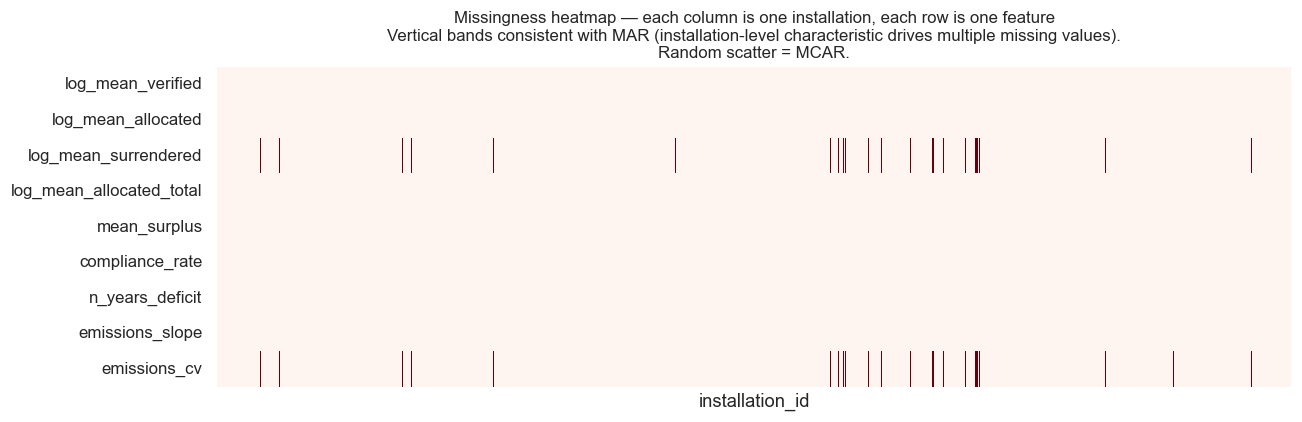

In [20]:
# ── Missingness heatmap ───────────────────────────────────────────────────────
# We visualise missingness across numeric analysis features only.
# What to look for:
#   - Vertical bands (whole columns red across all rows): missingness is
#     consistent within an installation across multiple features — the classic
#     MAR signature where an observable characteristic of the installation
#     (e.g. short Phase 3 participation) drives missingness in several
#     derived features simultaneously.
#   - Horizontal bands (whole rows red across all columns): a single feature
#     is missing for many installations — could be MAR or a data quality issue.
#   - Random scatter: consistent with MCAR.
#
# Note: naceCategory missingness (2.4%) is genuine — some installations were
# not assigned a NACE code in the EUTL. This is addressed in Section 3.1
# via mode imputation within activity category, which is defensible under MAR
# (the probability of a missing NACE code is plausibly related to installation
# type, which we observe through activityCategory).
numeric_analysis = [c for c in analysis_cols
                    if df[c].dtype != 'object']

if numeric_analysis:
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(
        df[numeric_analysis].isnull().T.astype(int).iloc[:, :3000],
        cmap='Reds', cbar=False, ax=ax, xticklabels=False
    )
    ax.set_title(
        'Missingness heatmap — each column is one installation, each row is one feature\n'
        'Vertical bands consistent with MAR (installation-level characteristic drives multiple missing values).\n'
        'Random scatter = MCAR.',
        fontsize=11
    )
    plt.tight_layout()
    plt.show()
else:
    print("No missing values in numeric analysis features.")

### 2.5 Exploring the Dataset

Before any modelling, we should build intuition about the data. What sectors dominate? How large are the emitters? Is there an aggregate trend in emissions through Phase 3?

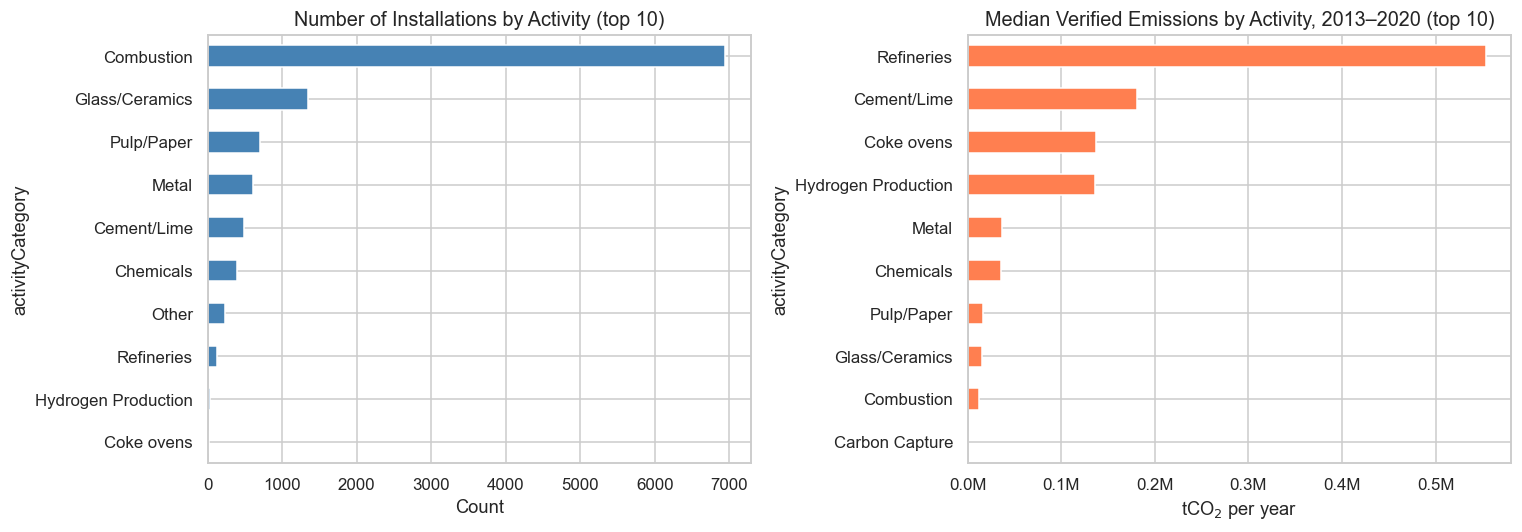

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['activityCategory'].value_counts().head(10).sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('Number of Installations by Activity (top 10)')
axes[0].set_xlabel('Count')

(
    df.groupby('activityCategory')['mean_verified']
    .median().sort_values().tail(10)
    .plot(kind='barh', ax=axes[1], color='coral')
)
axes[1].set_title('Median Verified Emissions by Activity, 2013–2020 (top 10)')
axes[1].set_xlabel('tCO$_2$ per year')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

The first two bar charts show two very different ways of defining “importance”.

#### Number of installations (extensive margin)

* **Combustion** dominates numerically by a large margin.
* Glass/Ceramics, Pulp/Paper and Metal follow.
* Refineries and Hydrogen Production are rare.

This tells us the EU ETS contains a *broad base* of medium-sized combustion installations.

#### Median emissions per installation (intensive margin)

When we look at median emissions instead of counts, the ranking changes completely:

* **Refineries** dominate.
* Cement/Lime and Coke ovens are very large.
* Combustion installations are numerous but individually much smaller.

This reveals a fundamental structural asymmetry:

> The EU ETS is numerically dominated by combustion plants, but emissions intensity is dominated by heavy industry.

In other words:

* Many small-to-medium emitters.
* A small number of extremely carbon-intensive installations.

This asymmetry will show up clearly in dimensionality reduction as a dominant “scale” dimension.

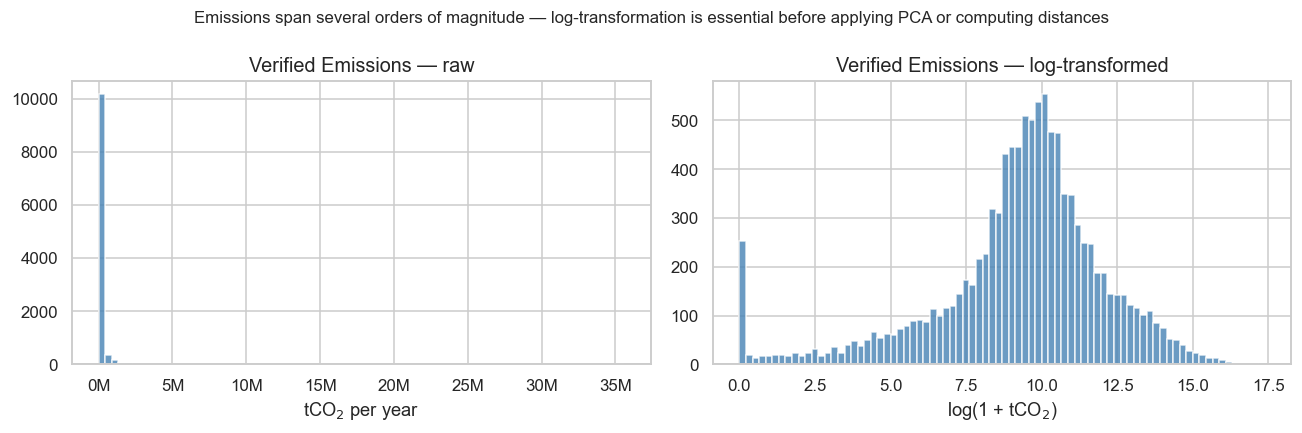

In [22]:
# The raw emissions distribution is so right-skewed that a histogram is nearly unreadable.
# The log-transform gives a much more interpretable distribution and is essential
# before applying PCA or computing distances.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['mean_verified'].dropna(), bins=80,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Verified Emissions — raw')
axes[0].set_xlabel('tCO$_2$ per year')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

axes[1].hist(df['log_mean_verified'].dropna(), bins=80,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Verified Emissions — log-transformed')
axes[1].set_xlabel('log(1 + tCO$_2$)')

plt.suptitle(
    'Emissions span several orders of magnitude — log-transformation is essential '
    'before applying PCA or computing distances',
    fontsize=11
)
plt.tight_layout()
plt.show()

The raw histogram shows an extremely right-skewed distribution.

A handful of installations emit orders of magnitude more CO₂ than the majority.
Most of the mass of the distribution is compressed near zero.

This creates two problems:

* Visualisation becomes misleading.
* Distance and variance-based methods become dominated by extreme emitters.

After applying:

$$
\log(1 + \text{tCO}_2)
$$

the distribution becomes much more interpretable:

* The extreme right tail is compressed.
* The middle of the distribution becomes visible.
* Differences become multiplicative rather than additive.

This transformation is essential before applying:

* PCA
* FAMD / MCA
* UMAP
* Autoencoders
* Any distance-based clustering method

Without it, geometric relationships reflect scale alone rather than structure.

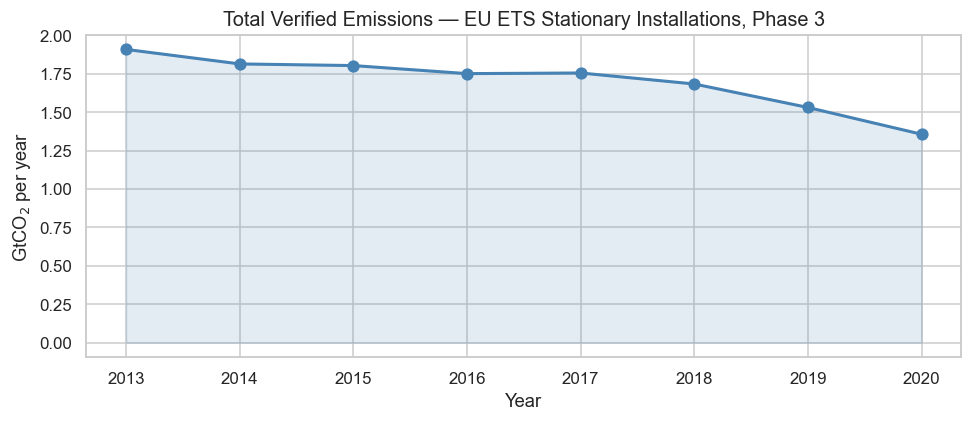

In [23]:
annual = phase3.groupby('year')['verified'].sum().reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(annual['year'], annual['verified'] / 1e9, 'o-',
        color='steelblue', linewidth=2, markersize=7)
ax.fill_between(annual['year'], annual['verified'] / 1e9, alpha=0.15, color='steelblue')
ax.set_title('Total Verified Emissions — EU ETS Stationary Installations, Phase 3')
ax.set_ylabel('GtCO$_2$ per year')
ax.set_xlabel('Year')
ax.set_xticks(range(2013, 2021))
plt.tight_layout()
plt.show()

The aggregate time series shows a gradual decline over Phase 3, with a sharper drop from 2018 onward and a pronounced reduction in 2020.

This pattern likely reflects:

* Tightening of the ETS cap,
* Rising carbon prices post-2018,
* Structural decarbonisation,
* The COVID-19 shock in 2020.

This is important for our feature construction:

When we summarise installations using:

* mean emissions,
* emissions slope,
* volatility,

we are compressing a **dynamic policy environment** into cross-sectional features.

Dimensionality reduction will therefore capture not just scale differences, but also differences in trajectory.

### 2.6 Multicollinearity: The Motivation for Dimensionality Reduction

The core motivation for dimensionality reduction is not just that we have many features: it is that many of them carry nearly the same information. Let us verify this by inspecting the correlation matrix.

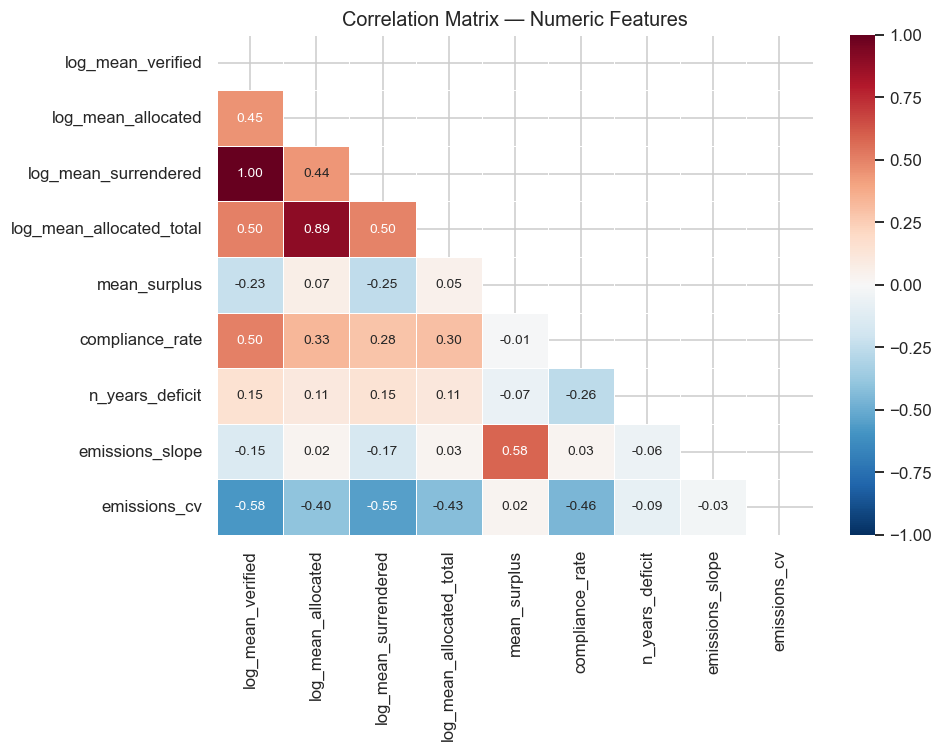

In [24]:
num_cols = [
    'log_mean_verified', 'log_mean_allocated', 'log_mean_surrendered',
    'log_mean_allocated_total', 'mean_surplus', 'compliance_rate',
    'n_years_deficit', 'emissions_slope', 'emissions_cv'
]
cat_cols = ['country', 'activityCategory', 'naceCategory']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5, annot_kws={'size': 9}
)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()

Looking at the correlation matrix:

#### Volume variables (scale)

The four log-volume variables:

* `log_mean_verified`
* `log_mean_allocated`
* `log_mean_surrendered`
* `log_mean_allocated_total`

are strongly positively correlated.

This is exactly what we would expect: all of them scale with installation size.

Treating them as independent sources of information would:

* Overweight facility size in distance-based methods,
* Inflate variance in linear decompositions,
* Introduce instability similar to the multicollinearity we saw in Week 3.

They represent a single latent construct:

> **Facility scale**


#### Compliance structure

`compliance_rate` and `n_years_deficit` are negatively correlated by construction.

They measure related aspects of regulatory performance.

This suggests a second latent construct:

> **Compliance behaviour**


#### Trajectory and volatility

`emissions_slope` and `emissions_cv` are only weakly correlated with the scale variables.

This is important.

It tells us that:

* Volatility and decarbonisation trends are not simply functions of size.
* They represent an additional structural dimension of the data.


#### What the correlation matrix tells us

Although we have nine numeric features, the structure suggests far fewer underlying dimensions.

At a minimum, we can identify:

1. Facility scale
2. Compliance behaviour
3. Emissions trajectory / volatility

Dimensionality reduction methods — whether PCA, FAMD, UMAP, or autoencoders — attempt to uncover these latent dimensions automatically.

PCA will do this linearly.
UMAP will do it geometrically.
Autoencoders will do it through learned nonlinear compression.

The purpose is the same:

> Replace a set of correlated observed variables with a smaller number of interpretable latent dimensions.


> The correlation matrix suggests that our nine observed features do not represent nine independent dimensions. Instead, they cluster around a smaller number of latent constructs. Dimensionality reduction methods attempt to uncover these constructs automatically.


## PART 3 — Dimensionality Reduction Methods

We cover four methods suited to different data types and objectives:

| Method | Works on | Key assumption | Primary strength |
|--------|----------|----------------|-----------------|
| **PCA** | Numeric | Linear combinations capture dominant variance | Interpretable loadings, fast, deterministic |
| **MCA** | Categorical | Association structure in indicator space | Correct geometry for purely categorical data |
| **FAMD** | Mixed | Linear structure with balanced numeric/categorical contributions | Handles mixed data without dummy inflation |
| **UMAP** | Numeric | Data lie on a low-dimensional manifold | Reveals clusters and non-linear geometry |
| **Autoencoders** | Numeric | Latent representation can reconstruct inputs | Flexible non-linear compression; anomaly detection |

All methods require complete data. PCA, UMAP, and autoencoders operate on numeric inputs; MCA operates on categorical inputs; FAMD handles mixed data. Our first task is therefore **preprocessing**.

### 3.1 Preprocessing

#### Why impute rather than drop?

The power sector installations that are missing `log_mean_allocated` are among the *largest* emitters in the EU ETS. Dropping them would not merely reduce the sample — it would remove the most important observations for understanding the system.

Under the MAR assumption, missingness depends on observed characteristics (such as activity type or years of operation) rather than on the unobserved value itself. This means we can use other observed features to estimate plausible values for the missing entries.

#### Categorical imputation: respecting institutional structure

Missing categorical values are not random.

For example, missing `naceCategory` values are strongly related to `activityCategory`. Instead of replacing missing values with the global mode — which would ignore this structure — we impute within activity groups. That is, a missing NACE code for a cement installation is replaced by the most common NACE code among cement installations.

This preserves the economic structure of the dataset and avoids introducing implausible category assignments.

#### Numeric imputation: tree-based MICE

For numeric variables, we use `IterativeImputer`, which implements a MICE-style (Multiple Imputation by Chained Equations) procedure.

Each numeric feature with missing values is modeled as a function of all other features. We use a tree-based estimator inside this procedure, allowing flexible nonlinear relationships between emissions, allocations, and compliance features to inform the imputation.

This avoids imposing strong linear assumptions on the data-generating process.


#### Why standardise after imputing?

Standardisation transforms each feature to mean zero and standard deviation one:

$$
z = \frac{x - \bar{x}}{\sigma}
$$

PCA, UMAP, and autoencoders are sensitive to the scale of their inputs. However, scaling requires complete data — we cannot compute means or standard deviations in the presence of missing values.

The correct order is therefore:

> **Impute first → then standardise**

In [25]:
df_work = df[num_cols + cat_cols].copy()

# ── Categorical imputation ────────────────────────────────────────────────
# Structure-aware imputation: NACE missingness depends on activity category.
# We impute within activity groups to respect MAR structure.

if 'naceCategory' in df_work.columns and 'activityCategory' in df_work.columns:
    df_work['naceCategory'] = (
        df_work
        .groupby('activityCategory')['naceCategory']
        .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))
    )

# For any remaining categorical missing values, use global mode
for col in cat_cols:
    if df_work[col].isnull().any():
        df_work[col] = df_work[col].fillna(df_work[col].mode()[0])

# ── Numeric imputation (tree-based MICE) ──────────────────────────────────
iter_imp = IterativeImputer(
    estimator=ExtraTreesRegressor(
        n_estimators=300,
        random_state=SEED,
        n_jobs=-1
    ),
    max_iter=10,
    random_state=SEED
)

df_work[num_cols] = iter_imp.fit_transform(df_work[num_cols])

# ── Standardisation ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_work[num_cols])

df_num_scaled = pd.DataFrame(
    X_scaled,
    columns=num_cols,
    index=df_work.index
)

# ── Final DR dataset ──────────────────────────────────────────────────────
df_dr = pd.concat([df_num_scaled, df_work[cat_cols]], axis=1)

print(f"Preprocessed dataset:  {df_dr.shape[0]:,} installations × {df_dr.shape[1]} features")
print(f"Any remaining missing values: {df_dr.isnull().any().any()}")

Preprocessed dataset:  10,928 installations × 12 features
Any remaining missing values: False


### 3.2 Principal Component Analysis (PCA)

#### What PCA does

PCA finds a new coordinate system for the data. Instead of axes aligned with the original variables, PCA finds axes aligned with the **directions of maximum variance**.

The intuition is easiest to see in two dimensions. When two variables are highly correlated — as `log_mean_verified` and `log_mean_allocated` are in this dataset — their scatter forms an elongated ellipse tilted diagonally. Most of the variation lies along the long axis of that ellipse; very little lies along the short axis. PCA finds those axes and makes them the new coordinate system.




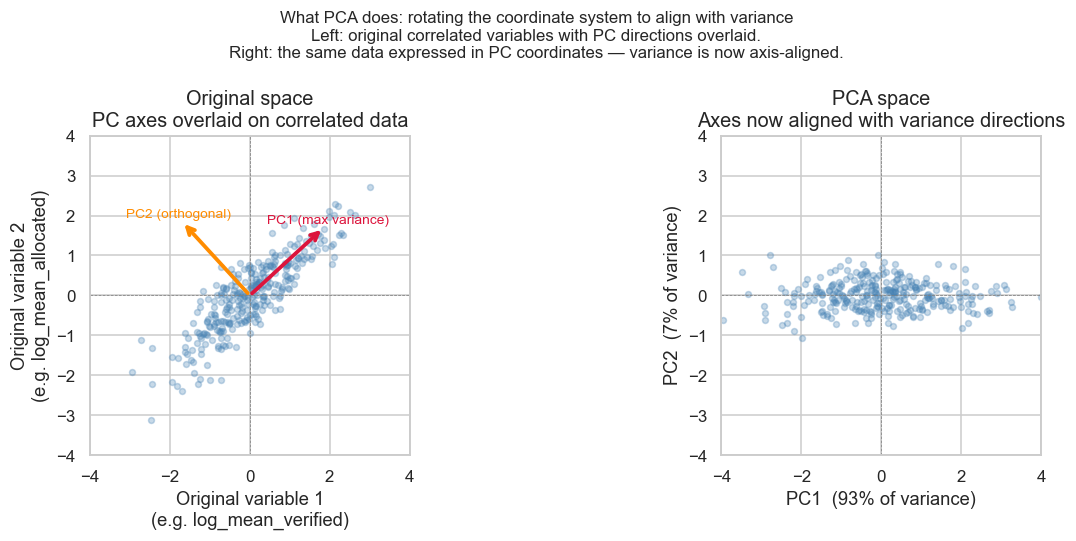

In [26]:
# ── Conceptual diagram: PCA rotation ─────────────────────────────────────────
# We generate a synthetic correlated two-variable dataset to illustrate
# what PCA does geometrically, before applying it to the real data.
# This is a pedagogical cell — no EU ETS data is used here.

rng = np.random.default_rng(42)
cov = [[1.0, 0.85], [0.85, 1.0]]
xy = rng.multivariate_normal([0, 0], cov, size=300)

pca_demo = PCA(n_components=2)
pca_demo.fit(xy)
components = pca_demo.components_   # PC directions in original space
scale = 2.5                          # arrow length for display

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left panel: original space with PC axes overlaid ──────────────────────────
axes[0].scatter(xy[:, 0], xy[:, 1], alpha=0.3, s=15, color='steelblue')
origin = np.array([0, 0])
for i, (comp, colour, label) in enumerate(zip(
    components,
    ['crimson', 'darkorange'],
    ['PC1 (max variance)', 'PC2 (orthogonal)']
)):
    axes[0].annotate(
        '', xy=origin + scale * comp, xytext=origin,
        arrowprops=dict(arrowstyle='->', color=colour, lw=2.5)
    )
    axes[0].text(
        *(origin + (scale + 0.15) * comp), label,
        color=colour, fontsize=9, ha='center'
    )

axes[0].axhline(0, color='grey', lw=0.5, ls='--')
axes[0].axvline(0, color='grey', lw=0.5, ls='--')
axes[0].set_xlim(-4, 4); axes[0].set_ylim(-4, 4)
axes[0].set_xlabel('Original variable 1\n(e.g. log_mean_verified)')
axes[0].set_ylabel('Original variable 2\n(e.g. log_mean_allocated)')
axes[0].set_title('Original space\nPC axes overlaid on correlated data')
axes[0].set_aspect('equal')

# ── Right panel: PCA-transformed space ────────────────────────────────────────
xy_transformed = pca_demo.transform(xy)
axes[1].scatter(xy_transformed[:, 0], xy_transformed[:, 1],
                alpha=0.3, s=15, color='steelblue')
axes[1].axhline(0, color='grey', lw=0.5, ls='--')
axes[1].axvline(0, color='grey', lw=0.5, ls='--')
axes[1].set_xlim(-4, 4); axes[1].set_ylim(-4, 4)
axes[1].set_xlabel(f'PC1  ({pca_demo.explained_variance_ratio_[0]*100:.0f}% of variance)')
axes[1].set_ylabel(f'PC2  ({pca_demo.explained_variance_ratio_[1]*100:.0f}% of variance)')
axes[1].set_title('PCA space\nAxes now aligned with variance directions')
axes[1].set_aspect('equal')

plt.suptitle(
    'What PCA does: rotating the coordinate system to align with variance\n'
    'Left: original correlated variables with PC directions overlaid.\n'
    'Right: the same data expressed in PC coordinates — variance is now axis-aligned.',
    fontsize=11
)
plt.tight_layout()
plt.show()

In the right panel, the cloud has been rotated so that its longest axis now lies along the horizontal. PC1 captures the most spread; PC2, orthogonal to it,captures the remainder. The shape of the cloud has not changed — only the coordinate system has.

Formally, each principal component (PC) is a linear combination of the original
standardised variables:

$$\text{PC}_k = w_{k1} z_1 + w_{k2} z_2 + \cdots + w_{kp} z_p$$

The weights $w_{ki}$ are the **loadings**. They tell us how strongly each original variable contributes to each component. Two key properties follow from the construction:

- Components are **uncorrelated** (orthogonal) with each other.
- They are **ordered by variance explained**: PC1 always explains more than PC2,
  which explains more than PC3, and so on.

<div style="border-left:4px solid #0969da;padding:0.65em 1em;border-radius:4px;margin:6px 0;">
<strong style="color:#0969da;">📝 Note</strong>
    
There are as many principal components as there are numeric dimensions in the data. If you start with 9 standardised variables, PCA will produce 9 principal components. In that sense, PCA by itself does not reduce dimensionality — it simply rotates the coordinate system.

**Dimensionality reduction occurs only when we choose to retain fewer components than originally produced**. By selecting, for example, the first 3 or 4 components, we deliberately discard the lower-variance directions in order to obtain a more compact representation of the data.

Importantly, there is **no universally correct rule for how much variance should be preserved**. The appropriate threshold depends on the objective of the analysis:

- If the goal is **visualisation**, retaining 2–3 components may be sufficient, even if they explain only 60–75% of the variance.
- If the goal is **preprocessing for modelling**, analysts often retain enough components to explain 80–90% of total variance.
- If the goal is **data compression or storage**, one might tolerate more information loss.
- If the goal is **scientific interpretation**, retaining additional components may be necessary to preserve substantively meaningful structure.

It is also important to recognise that variance explained is not the same as importance. A component that explains a relatively small share of total variance may still capture a policy-relevant or behaviourally meaningful dimension of the data.

Dimensionality reduction therefore involves a trade-off:

- Retaining more components preserves more information but reduces simplicity.
- Retaining fewer components increases interpretability and computational efficiency but discards some structure.

There is no mechanical cutoff. The decision should be guided by the scree plot, cumulative variance, domain knowledge, and the purpose of the analysis.

PCA gives us the full rotated basis; we decide how much of it to keep.
</div>

#### Why standardisation is essential

PCA is based on variance. If variables are not standardised, those with larger
numerical ranges dominate the solution purely because they vary more in absolute
terms — not because they are more informative. In our dataset, `log_mean_verified`
and `compliance_rate` are on entirely different scales: standardising ensures
PCA reflects the correlation structure of the data, not arbitrary unit choices.
The correct order is therefore: **impute → standardise → fit PCA**. All three
steps are enforced by the Pipeline in Section 4.

In [27]:
pca = PCA(n_components=len(num_cols), random_state=SEED)
pca.fit(X_scaled)

pca_scores = pca.transform(X_scaled)
pca_df = pd.DataFrame(
    pca_scores,
    columns=[f'PC{i+1}' for i in range(pca_scores.shape[1])],
    index=df_dr.index
)

exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

print("Variance explained per principal component:")
for i, (v, c) in enumerate(zip(exp_var, cum_var)):
    bar = '█' * int(v * 50)
    print(f"  PC{i+1}: {v*100:5.1f}%   cumulative: {c*100:5.1f}%   {bar}")

Variance explained per principal component:
  PC1:  41.5%   cumulative:  41.5%   ████████████████████
  PC2:  19.2%   cumulative:  60.6%   █████████
  PC3:  13.9%   cumulative:  74.5%   ██████
  PC4:  10.2%   cumulative:  84.7%   █████
  PC5:   6.3%   cumulative:  91.0%   ███
  PC6:   4.5%   cumulative:  95.5%   ██
  PC7:   3.2%   cumulative:  98.7%   █
  PC8:   1.1%   cumulative:  99.8%   
  PC9:   0.2%   cumulative: 100.0%   


From the results:

* **PC1 explains 41.5%** of total variance.
* **PC2 explains 19.2%**.
* **PC3 explains 13.9%**.
* The first **three components explain 74.5%**.
* The first **four components explain 84.7%**.

#### How many components should we keep?

There are two common rules of thumb:
- **The elbow rule**: plot the variance explained by each component and look for the point where adding another component gives diminishing returns.
- **The cumulative variance threshold**: keep enough components to explain 80–90% of the total variance.

The scree plot is the standard diagnostic tool.

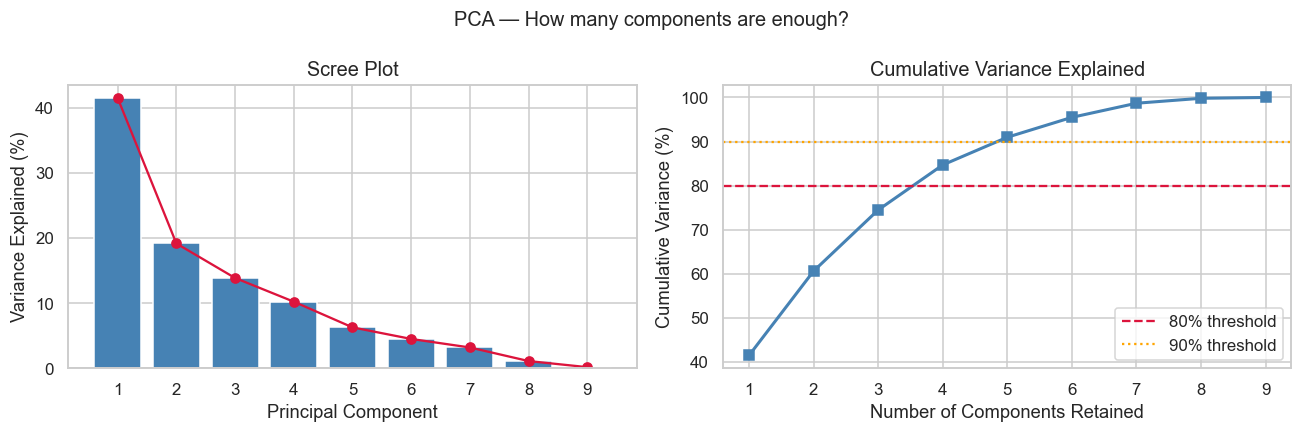

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(exp_var)+1), exp_var * 100,
            color='steelblue', edgecolor='white')
axes[0].plot(range(1, len(exp_var)+1), exp_var * 100,
             'o-', color='crimson', markersize=6)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, len(exp_var)+1))

axes[1].plot(range(1, len(cum_var)+1), cum_var * 100,
             's-', color='steelblue', linewidth=2, markersize=6)
axes[1].axhline(80, linestyle='--', color='crimson', label='80% threshold')
axes[1].axhline(90, linestyle=':', color='orange',  label='90% threshold')
axes[1].set_xlabel('Number of Components Retained')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xticks(range(1, len(cum_var)+1))
axes[1].legend()

plt.suptitle('PCA — How many components are enough?', fontsize=13)
plt.tight_layout()
plt.show()

In this dataset:

* PC1 is clearly dominant.
* PC2 and PC3 still explain meaningful structure.
* After PC4, additional components contribute relatively little.

We observe:

> One dominant dimension plus several smaller but meaningful ones.

#### Interpreting the loadings

Variance explained tells us *how much* structure each component captures. Loadings tell us *what that structure represents*.
Knowing how much variance each component explains tells us about *quantity*. The loadings tell us about *meaning* — which original variables drive each component.

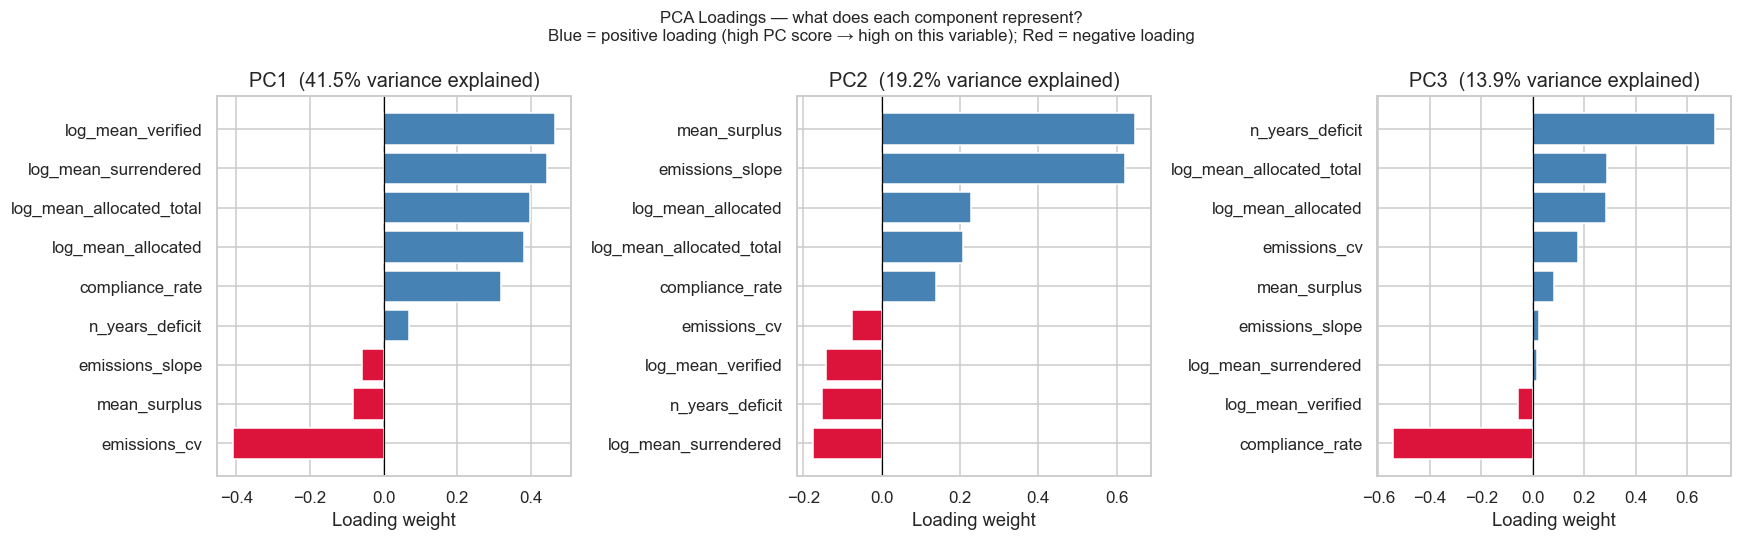

In [29]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=num_cols,
    columns=[f'PC{i+1}' for i in range(len(num_cols))]
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, ax in enumerate(axes):
    pc = f'PC{i+1}'
    vals = loadings[pc].sort_values()
    ax.barh(vals.index, vals.values,
            color=['crimson' if v < 0 else 'steelblue' for v in vals])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{pc}  ({exp_var[i]*100:.1f}% variance explained)')
    ax.set_xlabel('Loading weight')

plt.suptitle(
    'PCA Loadings — what does each component represent?\n'
    'Blue = positive loading (high PC score → high on this variable); '
    'Red = negative loading',
    fontsize=11
)
plt.tight_layout()
plt.show()

**Reading the loadings — what the actual output tells us:**

**PC1 — Facility Scale (41.5%).** The four log-volume variables (`log_mean_verified`, `log_mean_surrendered`, `log_mean_allocated_total`, `log_mean_allocated`) all load
strongly and positively. `compliance_rate` also loads positively, which makes sense: larger installations tend to be more carefully managed and more reliably compliant.
`emissions_cv` loads strongly *negatively* — large installations tend to have stable, predictable emissions, whereas small ones are more volatile. PC1 is essentially a
size axis: high scores mean large, stable, well-allocated facilities.

**PC2 — Allocation Surplus and Trajectory (19.2%).** PC2 is driven by `mean_surplus`and `emissions_slope`, both loading positively, and `log_mean_surrendered` loading
negatively. This is a more nuanced dimension than a simple compliance axis. High PC2 scores characterise installations that hold large surplus allowances *and* have
rising emissions — they are generously allocated relative to actual emissions, possibly because their benchmark was set before a production expansion. Low PC2
scores (negative) are installations that surrender a lot relative to their allocation and whose emissions are flat or declining — structural buyers running
tight compliance positions.

**PC3 — Chronic Deficit vs. Over-allocation (13.9%).** PC3 contrasts `n_years_deficit`(strongly positive) and `log_mean_allocated_total`, `log_mean_allocated` (moderately
positive) against `compliance_rate` (strongly negative). This separates installations that repeatedly fail to cover their emissions — despite receiving significant
allocation — from those that consistently run a comfortable surplus. This is the compliance *reliability* axis: it identifies chronic underperformers regardless
of their absolute size.

These three axes were not pre-specified — PCA recovered them automatically from the correlation structure of the data. Together they account for 74.5% of total
variance: most of what is meaningful in this dataset can be expressed in three numbers per installation.

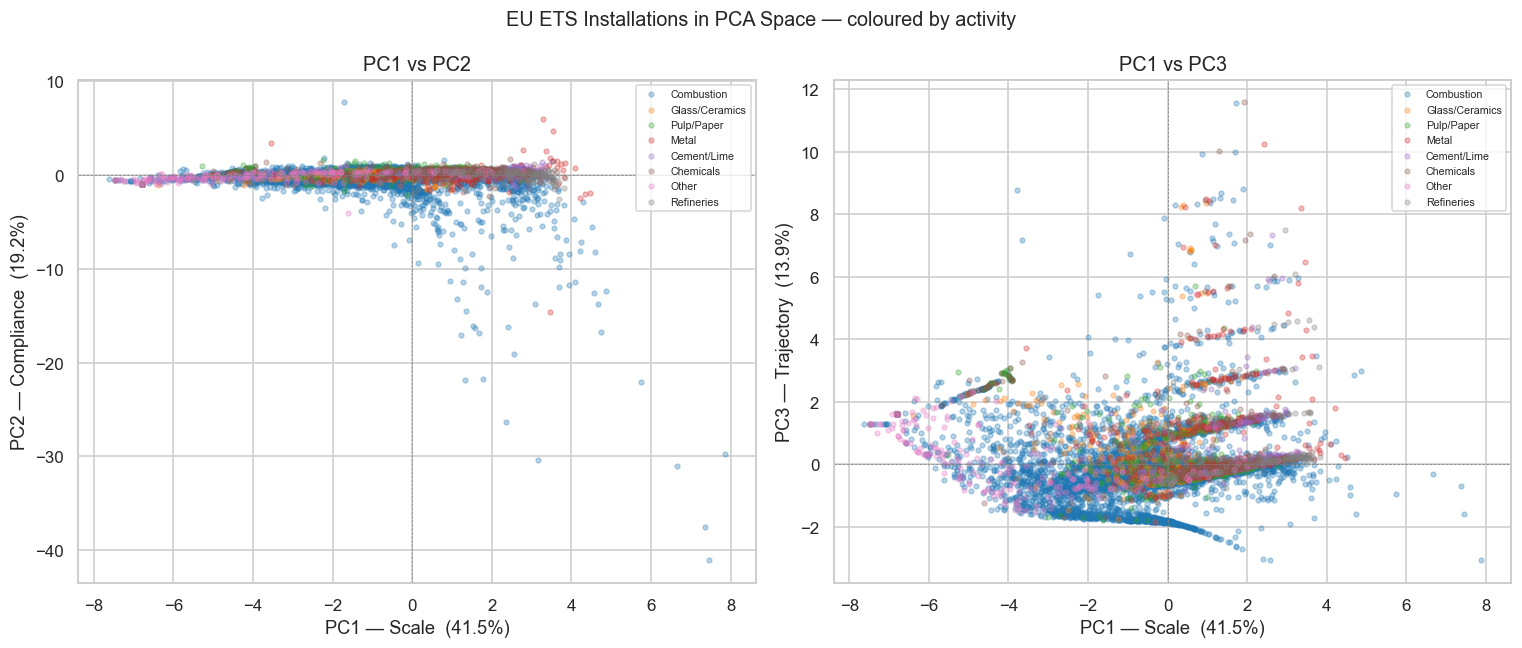

In [30]:
# Score plot: where do installations sit in PC space?
# Colouring by activity shows whether the components separate sectors.
pca_plot = pca_df.copy()
pca_plot['activityCategory'] = df_work['activityCategory'].values
top_acts = df_work['activityCategory'].value_counts().head(8).index
pp = pca_plot[pca_plot['activityCategory'].isin(top_acts)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for act in top_acts:
    m = pp['activityCategory'] == act
    axes[0].scatter(pp.loc[m, 'PC1'], pp.loc[m, 'PC2'],
                    alpha=0.3, s=10, label=act)
axes[0].axhline(0, color='grey', lw=0.5, ls='--')
axes[0].axvline(0, color='grey', lw=0.5, ls='--')
axes[0].set_xlabel(f'PC1 — Scale  ({exp_var[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 — Compliance  ({exp_var[1]*100:.1f}%)')
axes[0].set_title('PC1 vs PC2')
axes[0].legend(fontsize=7, loc='upper right')

for act in top_acts:
    m = pp['activityCategory'] == act
    axes[1].scatter(pp.loc[m, 'PC1'], pp.loc[m, 'PC3'],
                    alpha=0.3, s=10, label=act)
axes[1].axhline(0, color='grey', lw=0.5, ls='--')
axes[1].axvline(0, color='grey', lw=0.5, ls='--')
axes[1].set_xlabel(f'PC1 — Scale  ({exp_var[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC3 — Trajectory  ({exp_var[2]*100:.1f}%)')
axes[1].set_title('PC1 vs PC3')
axes[1].legend(fontsize=7, loc='upper right')

plt.suptitle('EU ETS Installations in PCA Space — coloured by activity', fontsize=13)
plt.tight_layout()
plt.show()

#### Why PCA cannot handle categorical variables

PCA operates on Euclidean distances between numbers. One-hot encoding `activityCategory` (with 30+ levels) before applying PCA causes a specific problem: in Euclidean geometry, all categories are equidistant from each other (the distance between any two one-hot vectors is $\sqrt{2}$). This means "Power" and "Steel" appear exactly as dissimilar as "Power" and "Cement" — which is arbitrary. The loadings on dummy variables have no meaningful interpretation.

The correct tools are **MCA** for purely categorical data and **FAMD** for mixed data, which we cover next.

### 3.3 MCA and FAMD — Handling Categorical and Mixed Data

#### Why PCA is not appropriate for categorical variables

Before introducing MCA, it is worth being precise about why PCA fails on categorical data — because the temptation to simply one-hot encode and proceed is common, and the results look plausible even when they are wrong.

When we one-hot encode a categorical variable with $k$ levels, we create $k$ binary columns. PCA then treats these columns as if they were continuous and computes Euclidean distances between rows. The problem is that Euclidean distance is the wrong geometry for binary indicator variables, for three distinct reasons:

**Wrong distances.** The Euclidean distance between any two one-hot vectors from the same variable is always $\sqrt{2}$, regardless of whether the categories are substantively similar or dissimilar. "Germany" and "Poland" are exactly as far from "France" as "Germany" is from "Cement" — which is meaningless. Categories that are institutionally related (two neighbouring countries, two similar industrial sectors) appear no closer than categories that have nothing in common.

**Cardinality bias.** A variable with 30 levels contributes 30 columns and therefore 30 times the weight of a single numeric variable, purely by virtue of having more categories. PCA components will be dominated by the highest-cardinality categorical variables regardless of their actual importance. In our dataset, `naceCategory` has many more levels than `activityCategory` — PCA on dummies would weight it correspondingly more heavily, which is not analytically justified.

**Uninterpretable loadings.** A loading of 0.3 on `activityCategory_Cement` cannot be compared to a loading of 0.3 on `log_mean_verified` — they are in incompatible spaces. The loadings on dummy variables tell us nothing meaningful about the relative importance of categories.

MCA solves all three problems by using a distance metric designed specifically for categorical co-occurrence structure.

#### Multiple Correspondence Analysis (MCA)

MCA is the categorical analogue of PCA. Rather than Euclidean distance, it uses **chi-square distance** — a metric that measures how unusually two observations co-occur across category levels, relative to what statistical independence would predict.

The chi-square distance between two installations $i$ and $i'$ across a set of categorical variables is:

$$d_{\chi^2}(i, i') = \sum_j \frac{1}{p_j} \left( \frac{x_{ij}}{x_{i\cdot}} - \frac{x_{i'j}}{x_{i'\cdot}} \right)^2$$

where $p_j$ is the marginal frequency of category $j$ across all installations. The key feature of this formula is the $1/p_j$ weighting: **rare categories contribute more to distance than common ones**. An unusual country-sector combination — say, a cement plant in Luxembourg — contributes more to the distance between two installations than a common one like a combustion installation in Germany. This is exactly the right behaviour for identifying structural outliers: the method is naturally sensitive to the unusual rather than the typical.

**The co-occurrence intuition.** Two category levels are "close" in MCA space if they tend to appear on the same installations more often than chance would predict. If power sector installations are disproportionately located in Poland, Germany, and the UK — because those countries had large coal fleets in Phase 3 — then the categories "Power", "Poland", "Germany", and "UK" will cluster together in the MCA map. Conversely, a country-sector combination that almost never co-occurs will be placed far apart, even if both the country and the sector are common individually.

**What MCA reveals in the EU ETS context.** By applying MCA to `country`, `activityCategory`, and `naceCategory`, we can uncover the **categorical geography** of the EU ETS: which sectors concentrate in which countries, whether any country-sector combinations are structural outliers, and whether the NACE classification adds meaningful information beyond the broader activity category. These are questions that no amount of examining numeric features can answer — they require a method that respects the structure of categorical co-occurrence.

**What MCA cannot do.** MCA operates only on categorical variables. It cannot incorporate the numeric features — emissions volumes, compliance rates, trajectory slopes — that carry most of the quantitative information about each installation. A separate PCA on the numeric features and a separate MCA on the categorical features would each reveal part of the picture, but they cannot be combined without losing the relationships *between* the two types. That is the problem FAMD solves.

In [31]:
if PRINCE_AVAILABLE:
    # ── MCA on categorical features only ──────────────────────────────────
    mca_input = df_work[cat_cols].copy()

    mca = prince.MCA(n_components=5, random_state=SEED)
    mca.fit(mca_input)
    mca_scores = mca.transform(mca_input)
    mca_scores.columns = [f'MCA{i+1}' for i in range(mca_scores.shape[1])]
    mca_scores.index = df_work.index

    print("MCA complete.")
    print("\nEigenvalue summary (proportion of inertia per dimension):")
    print(mca.eigenvalues_summary)
else:
    print("prince not available — using PCA on one-hot dummies as an approximation.")
    print("Note: this uses Euclidean rather than chi-square distance.")
    print("Install with: conda install -c conda-forge prince")
    dummies = pd.get_dummies(df_work[cat_cols])
    mca_scores = pd.DataFrame(
        PCA(n_components=5, random_state=SEED).fit_transform(dummies),
        columns=[f'MCA{i+1}' for i in range(5)],
        index=df_work.index
    )

MCA complete.

Eigenvalue summary (proportion of inertia per dimension):
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.696         3.94%                      3.94%
1              0.664         3.76%                      7.70%
2              0.645         3.65%                     11.35%
3              0.589         3.33%                     14.68%
4              0.521         2.95%                     17.63%


**Eigenvalue summary.** The first five MCA dimensions explain 3.9%, 3.8%, 3.7%, 3.3%, and 3.0% of total inertia — around 18% cumulatively. These numbers are low by design and should not be compared to PCA's variance explained figures. What matters is that the dimensions are interpretable, which the column coordinates plot confirms they are (see below).

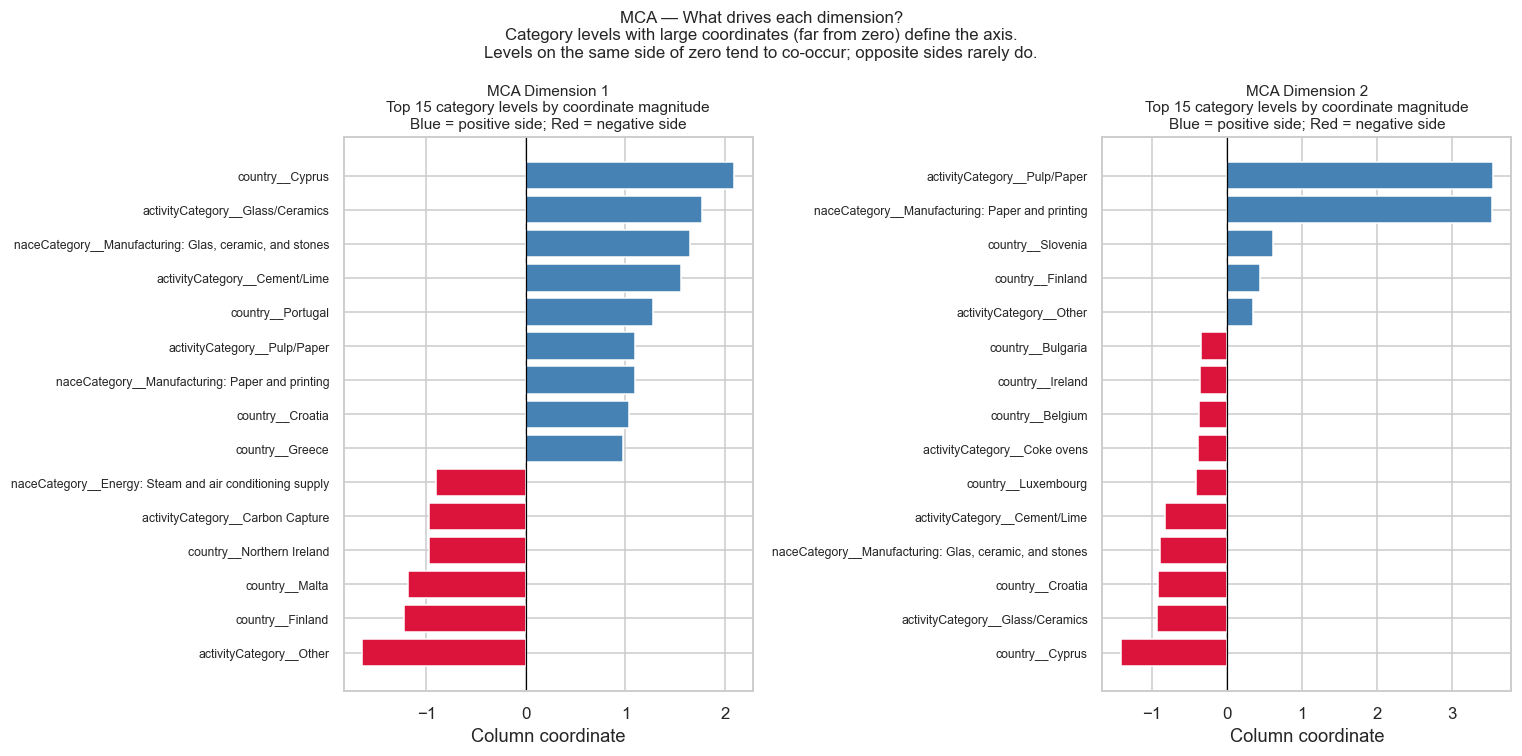

In [32]:
# ── MCA: variable contributions ───────────────────────────────────────────────
# To understand what each MCA dimension represents, we examine the contribution
# of each category level to each dimension. A category level with a high
# contribution is pulling that dimension — it is the defining characteristic
# of that axis.
#
# prince stores column coordinates (the position of each category level in
# MCA space) in mca.column_coordinates_. The contribution of each level to
# each dimension is proportional to the square of its coordinate, weighted
# by its frequency.

if PRINCE_AVAILABLE:
    col_coords = mca.column_coordinates(mca_input)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    for dim_idx, ax in enumerate(axes):
        dim = col_coords.iloc[:, dim_idx]
        # Show the 15 category levels with the largest absolute coordinate
        # on this dimension — these are the levels driving its meaning.
        top = dim.abs().nlargest(15).index
        vals = dim[top].sort_values()
        colours = ['crimson' if v < 0 else 'steelblue' for v in vals]
        ax.barh(range(len(vals)), vals.values, color=colours)
        ax.set_yticks(range(len(vals)))
        ax.set_yticklabels(
            [f"{idx[0]}: {idx[1]}" if isinstance(idx, tuple) else str(idx)
             for idx in vals.index],
            fontsize=8
        )
        ax.axvline(0, color='black', lw=0.8)
        ax.set_title(
            f'MCA Dimension {dim_idx + 1}\n'
            f'Top 15 category levels by coordinate magnitude\n'
            f'Blue = positive side; Red = negative side',
            fontsize=10
        )
        ax.set_xlabel('Column coordinate')

    plt.suptitle(
        'MCA — What drives each dimension?\n'
        'Category levels with large coordinates (far from zero) define the axis.\n'
        'Levels on the same side of zero tend to co-occur; opposite sides rarely do.',
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

**MCA Dimension 1 — Mediterranean industry vs. Nordic/peripheral specialisation.**

Reading the column coordinates plot for Dimension 1 (left panel of Image 1):

The *positive* side is defined by Cyprus, Glass/Ceramics, Manufacturing of glass
and stone products (NACE), Cement/Lime, Portugal, Pulp/Paper, Paper and printing
(NACE), Croatia, and Greece. These are small-to-medium southern and southeastern
European countries with industrial bases concentrated in building materials and
process industries. Cyprus and Malta in particular are very small ETS participants
with a narrow sectoral mix — almost entirely glass, cement, and small combustion
installations. Their high coordinate values reflect that they are rare and
distinctive categorical combinations: Cypriot cement plants and Greek glass
furnaces are unusual enough in the full EU ETS population that MCA places them
far from the centre.

The *negative* side is defined by Finland, Malta, Northern Ireland, Carbon
Capture installations, Energy/Steam supply (NACE), and `activityCategory__Other`.
Finland's negative position is interesting — despite being on the opposite side
from the Mediterranean countries, it reflects a different kind of distinctiveness:
Finland has a large Pulp/Paper sector (which loads positively on Dimension 2, as
we will see) and relatively few building materials installations. `activityCategory__Other`
and Carbon Capture are rare, specialised categories that cluster together on the
negative side simply because they are unusual and tend to appear in specific
northern European countries.

**MCA Dimension 2 — Pulp/Paper and Nordic manufacturing vs. Mediterranean
building materials.**

The *positive* side of Dimension 2 is dominated entirely by Pulp/Paper,
Paper and printing (NACE), Slovenia, Finland, and `activityCategory__Other`.
This is a coherent cluster: Scandinavia and Finland have large forest industries,
and Pulp/Paper installations in the EU ETS are heavily concentrated in those
countries. Slovenia's positive loading is smaller but reflects its relatively
high share of paper manufacturing relative to its ETS participation overall.

The *negative* side is Cyprus, Glass/Ceramics, Cement/Lime, Croatia, and the
glass/stone NACE category — the same Mediterranean building materials cluster
that defined the positive side of Dimension 1. The appearance of the same cluster
on the negative side of Dimension 2 and the positive side of Dimension 1 is
telling us something important: **MCA Dimensions 1 and 2 together are organising
the data around two orthogonal contrasts** — (1) Mediterranean building materials
versus northern peripheral countries, and (2) Nordic forest industries versus
Mediterranean building materials. These dimensions are uncorrelated by construction,
but the same countries and sectors appear in both because the categorical structure
of the EU ETS genuinely reflects this geographic-industrial geography.

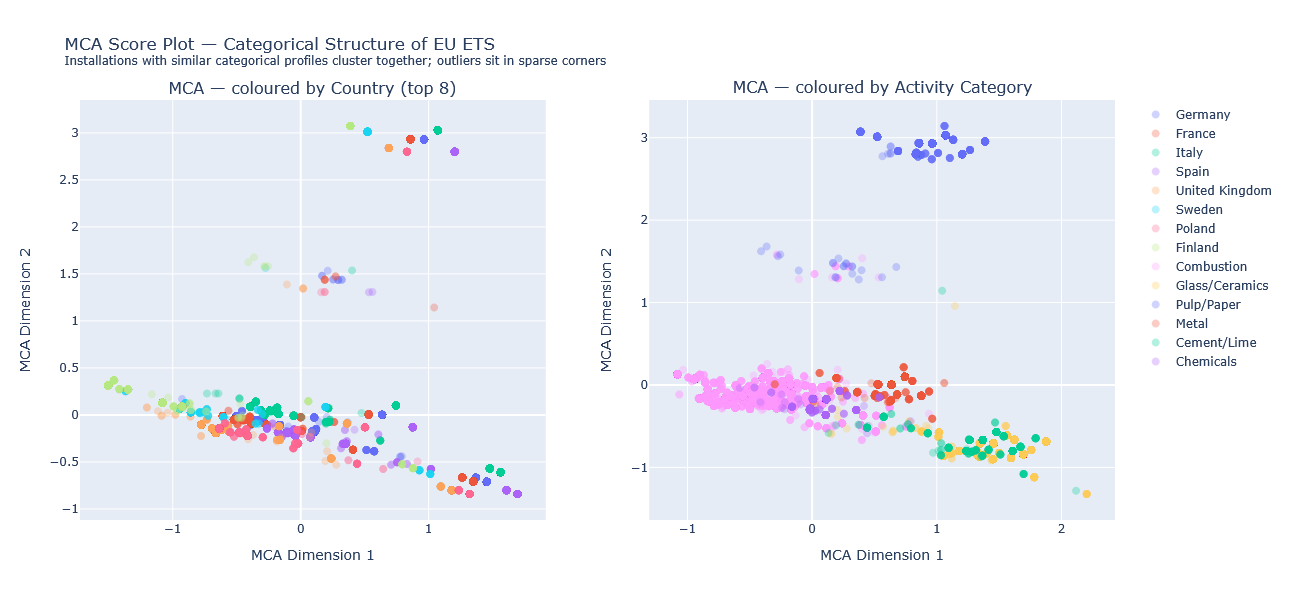

In [33]:

# Create a DataFrame for MCA scores with country and activityCategory
mca_plot = mca_scores.copy()
mca_plot['country'] = df_work['country'].values
mca_plot['activityCategory'] = df_work['activityCategory'].values

# Get top countries and activity categories
top_countries = df_work['country'].value_counts().head(8).index
top_activities = df_work['activityCategory'].value_counts().head(6).index

# Create subplots
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('MCA — coloured by Country (top 8)',
                                    'MCA — coloured by Activity Category'))

# Add scatter plot for countries
for c in top_countries:
    m = mca_plot['country'] == c
    fig.add_trace(
        go.Scatter(
            x=mca_plot.loc[m, 'MCA1'],
            y=mca_plot.loc[m, 'MCA2'],
            mode='markers',
            marker=dict(size=8, opacity=0.3),
            name=c,
            showlegend=True
        ),
        row=1, col=1
    )

# Add scatter plot for activity categories
for act in top_activities:
    m = mca_plot['activityCategory'] == act
    fig.add_trace(
        go.Scatter(
            x=mca_plot.loc[m, 'MCA1'],
            y=mca_plot.loc[m, 'MCA2'],
            mode='markers',
            marker=dict(size=8, opacity=0.3),
            name=act,
            showlegend=True
        ),
        row=1, col=2
    )

# Update layout
fig.update_layout(
    title_text='MCA Score Plot — Categorical Structure of EU ETS<br><sup>Installations with similar categorical profiles cluster together; outliers sit in sparse corners</sup>',
    height=600,
    width=1000,
    hovermode='closest'
)

# Update axes labels
fig.update_xaxes(title_text='MCA Dimension 1', row=1, col=1)
fig.update_yaxes(title_text='MCA Dimension 2', row=1, col=1)
fig.update_xaxes(title_text='MCA Dimension 1', row=1, col=2)
fig.update_yaxes(title_text='MCA Dimension 2', row=1, col=2)

# Show the plot
fig.show()


**MCA score plots (Image 2).**

The score plots confirm and extend this reading.

*Left panel (coloured by country):* The plot shows a clear diagonal structure
rather than compact country clusters. This is characteristic of MCA score plots
when the categorical variables are not perfectly confounded — installations spread
along a gradient rather than collapsing into tight national blobs. Germany, France,
Italy, Spain, and the UK (the five largest ETS participants) overlap heavily near
the centre: these large, diverse countries have installations across many sectors
and their categorical profiles are therefore close to the EU ETS average. The
more distinctive positions belong to smaller countries with narrower industrial
mixes. Finland appears at negative MCA1/positive MCA2, consistent with its Pulp/Paper
concentration. The cluster of points at high MCA2 (around 3.0) visible in the
right panel are the Pulp/Paper installations — a tight, distinctive group
regardless of which country they are in.

*Right panel (coloured by activity):* The activity colouring makes the structure
much clearer. Combustion installations (pink) dominate the central mass and spread
broadly — combustion is the most common activity and spans all countries and scales,
so its categorical profile is close to average. Pulp/Paper (blue-purple) forms a
tight, well-separated cluster at high MCA2, confirming that Dimension 2 is
essentially the Pulp/Paper axis. Glass/Ceramics (yellow) and Cement/Lime (teal)
sit at positive MCA1/negative MCA2 — the Mediterranean building materials quadrant.
Metal installations (red-orange) are scattered with moderate MCA1 values,
reflecting that metal production spans many European countries without strong
geographic concentration. Chemicals (light purple) sit close to the centre,
suggesting their categorical profile is not particularly unusual relative to
the average EU ETS installation.

**Key takeaway from MCA.** The categorical structure of the EU ETS is organised
primarily by sector identity rather than national identity — the Pulp/Paper cluster,
the building materials cluster, and the central combustion mass are defined by
what installations do, not where they are. Country plays a secondary role,
modulating position within sector clusters (Finnish Pulp/Paper versus Swedish
Pulp/Paper) rather than defining the primary axes of variation. This is substantively
informative: it suggests that sectoral regulation (sector-specific benchmarks,
allocation rules) is the dominant source of categorical heterogeneity in the
dataset, with national energy policy playing a secondary role.

#### Factor Analysis of Mixed Data (FAMD)

Most real-world datasets — and certainly this one — contain both numeric and categorical variables. The naive approaches to handling this are both wrong in different ways.

**PCA on everything** (after one-hot encoding) uses the wrong distance metric for categoricals, for all three reasons described above.

**PCA on numerics combined post-hoc with MCA on categoricals** loses the cross-type relationships — which are often the most interesting ones. Consider: power sector installations in Phase 3 received no free allocation, so their `log_mean_allocated` and `mean_surplus` values are structurally lower than industrial installations at similar emissions volumes. This is a joint pattern involving both a categorical variable (activityCategory = Combustion) and several numeric variables. PCA on the numerics sees unusual allocation values but does not know why; MCA on the categoricals sees that Power is distinct but cannot connect this to scale and compliance behaviour. The relationship between categorical identity and numeric profile disappears entirely if we analyse the two types separately.

There is also a geometric incompatibility: PCA uses Euclidean distance on a standardised scale, while MCA uses chi-square distance on a frequency-normalised scale. These are incommensurable and cannot simply be concatenated into a common coordinate system without destroying the meaning of both.

**FAMD** resolves both issues simultaneously. It finds a single set of axes that maximises explained variance across both numeric and categorical features, using a unified distance metric that treats each original variable comparably regardless of type. Internally it applies three steps:

1. **Standardises numeric variables** to mean zero, unit variance — exactly as PCA does.
2. **Normalises each category indicator** by the square root of its marginal frequency — exactly as MCA does — giving rare categories appropriate weight without letting high-cardinality variables dominate.
3. **Applies a single SVD** to the combined, normalised matrix, producing one coherent low-dimensional space in which numeric and categorical information are jointly represented.

The result is a set of dimensions that can be interpreted across both variable types simultaneously. A dimension might contrast large-scale combustion installations (numeric: high `log_mean_verified`) in Eastern European countries (categorical: Poland, Czech Republic, Romania) against small-scale industrial installations in Western Europe — a pattern in which the numeric and categorical signals are inseparable, and which neither PCA nor MCA could surface alone.

**Choosing between PCA, MCA, and FAMD:**

| Data type | Correct method |
|:---|:---|
| All numeric | PCA |
| All categorical | MCA |
| Mixed — the realistic default for social science data | FAMD |

In practice, most social science and policy datasets are mixed. FAMD should be the default starting point, with PCA reserved for cases where the analyst deliberately wants to examine numeric structure in isolation.

In [34]:
if PRINCE_AVAILABLE:
    # ── FAMD on numeric + categorical features together ────────────────────
    # FAMD standardises numerics internally as part of its algorithm, so we
    # pass the imputed but NOT yet standardised numeric values from df_work.
    # Passing X_scaled (already standardised) would double-standardise them.
    # Categorical columns come from df_work[cat_cols] which are already
    # mode-imputed above — no further imputation needed.
    #
    # We verify no NaN remains as a safeguard before handing off to prince,
    # whose SVD backend will raise an uninformative error if any slips through.
    famd_input = pd.concat([
        df_work[num_cols].reset_index(drop=True),
        df_work[cat_cols].reset_index(drop=True)
    ], axis=1)

    assert famd_input.isnull().sum().sum() == 0, \
        "NaN values remain in famd_input — check imputation in Section 3.1"

    famd = prince.FAMD(n_components=5, random_state=SEED)
    famd.fit(famd_input)
    famd_scores = famd.transform(famd_input)
    famd_scores.columns = [f'FAMD{i+1}' for i in range(famd_scores.shape[1])]
    famd_scores.index = df_work.index

    print("FAMD complete.")
    print("\nVariance explained (proportion of total inertia per dimension):")
    print(famd.eigenvalues_summary)
else:
    print("prince not available — using PCA on scaled numerics + one-hot dummies as an approximation.")
    print("Install with: conda install -c conda-forge prince")
    dummies = pd.get_dummies(df_work[cat_cols])
    X_fb = np.hstack([X_scaled, dummies.values])
    famd_scores = pd.DataFrame(
        PCA(n_components=5, random_state=SEED).fit_transform(X_fb),
        columns=[f'FAMD{i+1}' for i in range(5)],
        index=df_work.index
    )

FAMD complete.

Variance explained (proportion of total inertia per dimension):
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              5.119         5.78%                      5.78%
1              2.992         3.38%                      9.17%
2              2.911         3.29%                     12.46%
3              2.777         3.14%                     15.59%
4              2.573         2.91%                     18.50%


**Eigenvalue summary.** FAMD Dimension 1 explains 5.78% of total inertia, with
subsequent dimensions explaining 3.38%, 3.29%, 3.14%, and 2.91%. The first
dimension is notably more important than the rest — the gap between Dimension 1
(eigenvalue 5.12) and Dimension 2 (eigenvalue 2.99) is larger than any
subsequent gap. This echoes the PCA result, where PC1 was also dominant. It
suggests that one axis — facility scale — organises the data so strongly that
it persists even when categorical information is incorporated. The lower
subsequent dimensions reflect the more evenly distributed structure of categorical
variation, exactly as we saw in MCA.

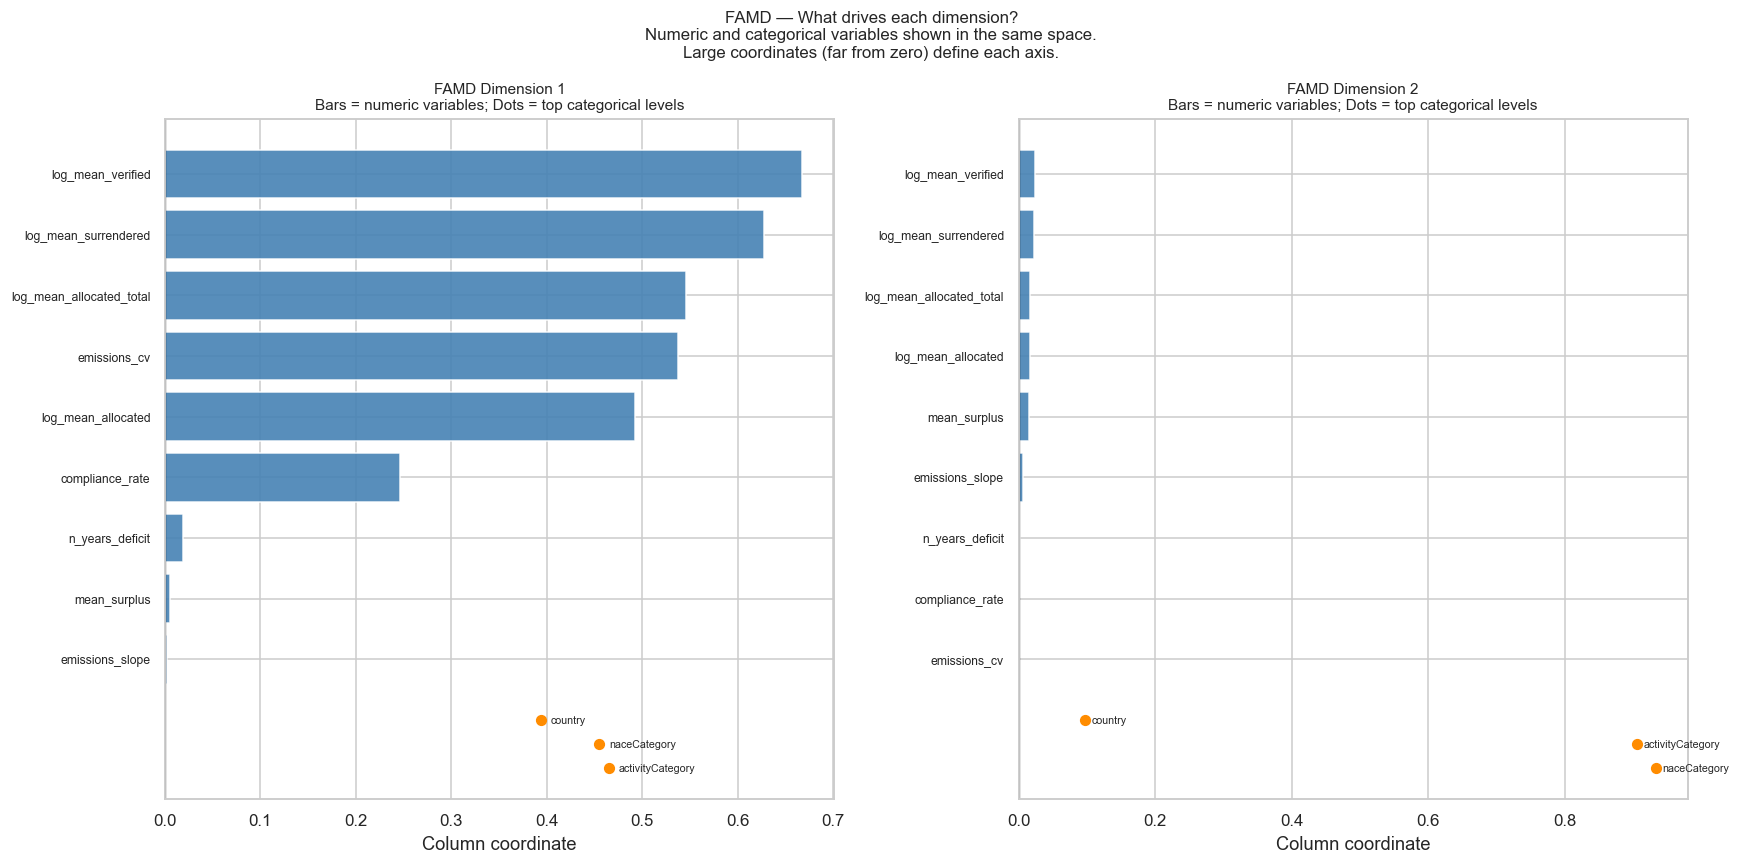

In [35]:
if PRINCE_AVAILABLE:

    # Make sure the model is fitted
    # famd = famd.fit(famd_input)   # if not already fitted

    # Column coordinates (numeric vars + categorical levels)
    num_coords = famd.column_coordinates_

    numeric_rows = [idx for idx in num_coords.index if idx in num_cols]
    cat_rows = [idx for idx in num_coords.index if idx not in num_cols]

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    for dim_idx, ax in enumerate(axes):
        dim_vals = num_coords.iloc[:, dim_idx]

        # Numeric variables (bars)
        num_vals = dim_vals.loc[numeric_rows].sort_values()
        n = len(num_vals)

        ax.barh(
            range(n),
            num_vals.values,
            color=['crimson' if v < 0 else 'steelblue' for v in num_vals],
            alpha=0.9
        )

        ax.set_yticks(range(n))
        ax.set_yticklabels(num_vals.index, fontsize=8)

        # Top categorical levels (points)
        cat_vals = dim_vals.loc[cat_rows]
        top_cat = cat_vals.abs().nlargest(10)

        for i, (label, val) in enumerate(
            cat_vals.loc[top_cat.index].sort_values().items()
        ):
            ax.scatter(
                val,
                -1 - i * 0.4,
                color='darkorange' if val > 0 else 'purple',
                s=40,
                zorder=5
            )
            ax.text(
                val + 0.01,
                -1 - i * 0.4,
                str(label),
                fontsize=7,
                va='center'
            )

        ax.axvline(0, color='black', lw=0.8)
        ax.set_title(
            f'FAMD Dimension {dim_idx + 1}\n'
            f'Bars = numeric variables; Dots = top categorical levels',
            fontsize=10
        )
        ax.set_xlabel('Column coordinate')

    plt.suptitle(
        'FAMD — What drives each dimension?\n'
        'Numeric and categorical variables shown in the same space.\n'
        'Large coordinates (far from zero) define each axis.',
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

**FAMD Dimension 1 — Facility scale (numeric dominant, categorical subordinate).**

The column coordinates plot (Image 3, left panel) tells a clear story.
All four log-volume numeric variables load strongly and positively on Dimension 1:
`log_mean_verified` (≈0.67), `log_mean_surrendered` (≈0.64), `log_mean_allocated_total`
(≈0.54), `log_mean_allocated` (≈0.50). `emissions_cv` also loads positively (≈0.53),
which is the one surprising result — recall from PCA that `emissions_cv` loaded
*negatively* on PC1, reflecting that large installations tend to have stable
emissions. In FAMD, the balancing mechanism that normalises categorical variables
changes the relative contributions, and `emissions_cv` shifts to the positive side.
`compliance_rate` loads moderately positively (≈0.25), while `mean_surplus`,
`emissions_slope`, and `n_years_deficit` are essentially zero on this dimension.

The three categorical variables (shown as orange dots) all sit at moderate positive
coordinates — around 0.4–0.5 for `activityCategory` and `naceCategory`, and
slightly lower for `country`. This is a crucial observation: **in FAMD, the
categorical variables are contributing positively to Dimension 1 alongside the
numeric scale variables.** This means that sector identity and country are
partially correlated with facility scale — large installations are not randomly
distributed across sectors and countries. Combustion and refinery installations
tend to be large; glass and ceramics installations tend to be small. FAMD is
capturing this joint numeric-categorical signal in a single dimension that PCA
could not represent.

**FAMD Dimension 2 — Categorical structure, numerics near zero.**

The right panel of Image 3 shows a striking contrast with Dimension 1. All
numeric variables have near-zero coordinates on Dimension 2 — the bars are barely
visible. `log_mean_verified`, `log_mean_surrendered`, `log_mean_allocated_total`,
`log_mean_allocated`, `mean_surplus`, `emissions_slope`, `n_years_deficit`,
`compliance_rate`, and `emissions_cv` all contribute essentially nothing.

Instead, the categorical variables drive Dimension 2 entirely: `activityCategory`
and `naceCategory` sit at large positive coordinates (≈0.85–0.90), while `country`
sits at a moderate positive coordinate (≈0.45). This dimension is purely
categorical — it separates installations by what they do and where they are,
independently of how large they are or how they behave numerically. This is
precisely the cross-type insight FAMD provides: there is a dimension of variation
in the EU ETS that is entirely about sector and country identity, orthogonal to
and independent of the numeric compliance and scale dimensions. PCA was completely
blind to this dimension because it contained no numeric signal.

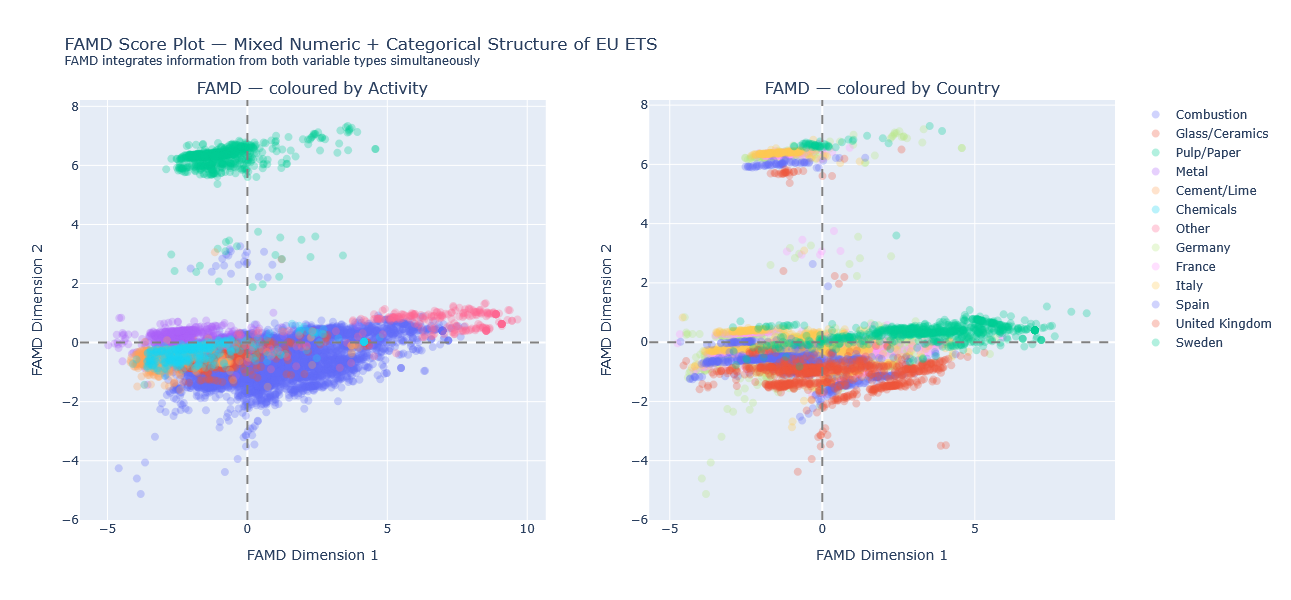

In [36]:
# Create a DataFrame for FAMD scores with country and activityCategory
famd_plot = famd_scores.copy()
famd_plot['activityCategory'] = df_work['activityCategory'].values
famd_plot['country'] = df_work['country'].values

# Get top countries and activity categories
top_countries = df_work['country'].value_counts().head(6).index
top_activities = df_work['activityCategory'].value_counts().head(7).index

# Create subplots
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('FAMD — coloured by Activity',
                                    'FAMD — coloured by Country'))

# Add scatter plot for activity categories
for act in top_activities:
    m = famd_plot['activityCategory'] == act
    fig.add_trace(
        go.Scatter(
            x=famd_plot.loc[m, 'FAMD1'],
            y=famd_plot.loc[m, 'FAMD2'],
            mode='markers',
            marker=dict(size=8, opacity=0.3),
            name=act,
            showlegend=True
        ),
        row=1, col=1
    )

# Add scatter plot for countries
for c in top_countries:
    m = famd_plot['country'] == c
    fig.add_trace(
        go.Scatter(
            x=famd_plot.loc[m, 'FAMD1'],
            y=famd_plot.loc[m, 'FAMD2'],
            mode='markers',
            marker=dict(size=8, opacity=0.3),
            name=c,
            showlegend=True
        ),
        row=1, col=2
    )

# Add horizontal and vertical lines at zero
fig.add_hline(y=0, line_dash='dash', line_color='grey', row=1, col=1)
fig.add_vline(x=0, line_dash='dash', line_color='grey', row=1, col=1)
fig.add_hline(y=0, line_dash='dash', line_color='grey', row=1, col=2)
fig.add_vline(x=0, line_dash='dash', line_color='grey', row=1, col=2)

# Update layout
fig.update_layout(
    title_text='FAMD Score Plot — Mixed Numeric + Categorical Structure of EU ETS<br><sup>FAMD integrates information from both variable types simultaneously</sup>',
    height=600,
    width=1000,
    hovermode='closest'
)

# Update axes labels
fig.update_xaxes(title_text='FAMD Dimension 1', row=1, col=1)
fig.update_yaxes(title_text='FAMD Dimension 2', row=1, col=1)
fig.update_xaxes(title_text='FAMD Dimension 1', row=1, col=2)
fig.update_yaxes(title_text='FAMD Dimension 2', row=1, col=2)

# Show the plot
fig.show()


**FAMD score plots (Image 4).**

*Left panel (coloured by activity):* The score plot reveals a structure that is
dramatically different from the PCA score plot. The most striking feature is the
**Pulp/Paper cluster** (green) sitting far above the main mass at FAMD Dimension
2 values of approximately 6–7. This cluster was not visible in PCA at all — Pulp/Paper
installations have unremarkable numeric profiles (medium-sized, broadly compliant)
but a very distinctive categorical signature. FAMD surfaces this because Dimension 2
is categorical-dominant, as we saw in the column coordinates plot. The Pulp/Paper
cluster is tight and well-separated, confirming that these installations form a
genuinely distinct categorical group.

The horizontal spread along Dimension 1 corresponds to facility scale, exactly
as in PCA. Combustion installations (blue-purple) spread widely along the positive
Dimension 1 axis — they include everything from small district heating systems to
large coal power stations. Cement/Lime (teal) and Glass/Ceramics (yellow) sit at
moderate positive Dimension 1, slightly below zero on Dimension 2 — medium-sized
building materials installations in the southern European categorical cluster
identified by MCA. Chemicals (light blue) are scattered across both axes, reflecting
their heterogeneous size distribution and geographic spread.

*Right panel (coloured by country):* The country colouring reveals that the
Pulp/Paper cluster at high Dimension 2 is predominantly Swedish (teal) and Finnish,
with some German representation. This confirms the MCA finding that the Pulp/Paper
sector is geographically concentrated in Nordic countries — FAMD integrates both
signals (sector = Pulp/Paper, country = Sweden/Finland) into a single high-Dimension-2
position. The horizontal scale gradient (Dimension 1) shows relatively little
country structure — large and small installations are distributed across all
major ETS countries, so nationality does not predict scale as strongly as sector does.

The installations with very negative Dimension 2 values (around -4 to -6) are
worth examining individually — they are categorically unusual enough that their
Dimension 2 coordinate is an outlier even within the already-dispersed main mass.
These likely correspond to the rare or unusual sector-country combinations
identified at the extremes of the MCA column coordinates.

**Comparing FAMD to PCA: what FAMD adds.**

The most important observation from comparing the two sets of score plots is that
**FAMD separates the Pulp/Paper sector completely, while PCA merged it into the
main mass.** In the PCA score plots, Pulp/Paper installations were indistinguishable
from other medium-sized industrial installations — their numeric profiles did not
set them apart. In FAMD, they form the most visually distinct cluster in the entire
plot. This is the clearest possible demonstration of what FAMD provides over PCA:
a dimension that carries no numeric signal at all, but captures a real and important
structural distinction in the data.

The second observation is that the Combustion installations, which formed the
majority of the PCA mass, are now spread more broadly in FAMD space — their
internal categorical heterogeneity (different countries, different NACE codes
within combustion) is now expressed in Dimension 2, creating a more dispersed
cloud rather than a compressed mass. This additional spread is not noise; it is
genuine categorical structure that PCA discarded.

#### Choosing between PCA, MCA, and FAMD

The choice is entirely determined by what types of variables you have:

- All numeric → **PCA**
- All categorical → **MCA**
- Mixed (the realistic default for social science data) → **FAMD**

### 3.4 UMAP — Uniform Manifold Approximation and Projection

#### When linear methods are not enough

PCA and FAMD find the best *linear* summary of the data. But some real-world structures cannot be captured by straight lines. In the EU ETS:

- **The Phase 3 power sector exclusion is a hard discontinuity.** Power generators received zero free allocation — a complete structural break from industrial installations. A linear axis cannot represent a discontinuity cleanly; it can only average across it.
- **The relationship between allocation and compliance is non-linear across sectors.** For industrial installations, more allocation means more surplus. For power generators who received nothing, compliance cost depends entirely on the carbon price. No straight line captures both regimes simultaneously.
- **Installations may form genuinely non-convex clusters.** A cement kiln, a glass furnace, and a lime production facility might all look similar on a linear axis — mid-sized, partially allocated, relatively compliant — but form a tight sub-cluster in the true feature space that PCA projects onto a broad, undifferentiated blob.

UMAP is designed to handle these cases. Rather than finding linear axes, it finds a 2D layout that preserves **local neighbourhood structure** — which installations are most similar to which others — while also capturing broader topology.

#### How UMAP works

UMAP operates in two stages:

**Stage 1 — Build a neighbourhood graph.** For each installation, find its $k$ nearest neighbours in the standardised feature space. Connect each installation to its neighbours with edges weighted by distance: closer neighbours get stronger connections. The parameter `n_neighbors` controls the size of the neighbourhood — small values produce many tight micro-clusters; large values produce a smoother map that better captures global relationships.

**Stage 2 — Project to 2D while preserving the graph.** Find a 2D layout that, as closely as possible, respects the neighbourhood structure from Stage 1: installations that were close in high-dimensional space should remain close; those that were far apart should remain far apart.

Because UMAP's output depends on `n_neighbors`, we always check stability across a range of parameter values. Clusters that appear consistently across settings are reliable; those that only appear for one specific value are not.

In [37]:
# A quick linear diagnosis: how much variance do 3 PCs capture?
# If this is low, linear methods are missing meaningful structure.
cum_3 = cum_var[2]
print(f"Variance explained by first 3 PCs: {cum_3*100:.1f}%")
if cum_3 < 0.60:
    print("→ Below 60% — linear methods are likely missing substantial structure.")
    print("  UMAP is strongly motivated.")
elif cum_3 < 0.80:
    print("→ Between 60–80% — PCA captures main trends,")
    print("  but UMAP may reveal finer cluster structure within those trends.")
else:
    print("→ Above 80% — linear methods capture most structure.")
    print("  UMAP can still reveal within-cluster detail not visible linearly.")

Variance explained by first 3 PCs: 74.5%
→ Between 60–80% — PCA captures main trends,
  but UMAP may reveal finer cluster structure within those trends.


In [38]:
reducer = umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.1,
        metric='euclidean',
        random_state=SEED
    )
umap_embedding = reducer.fit_transform(X_scaled)
umap_df = pd.DataFrame(umap_embedding, columns=['UMAP1', 'UMAP2'],
                            index=df_work.index)
print("UMAP complete.")


UMAP complete.


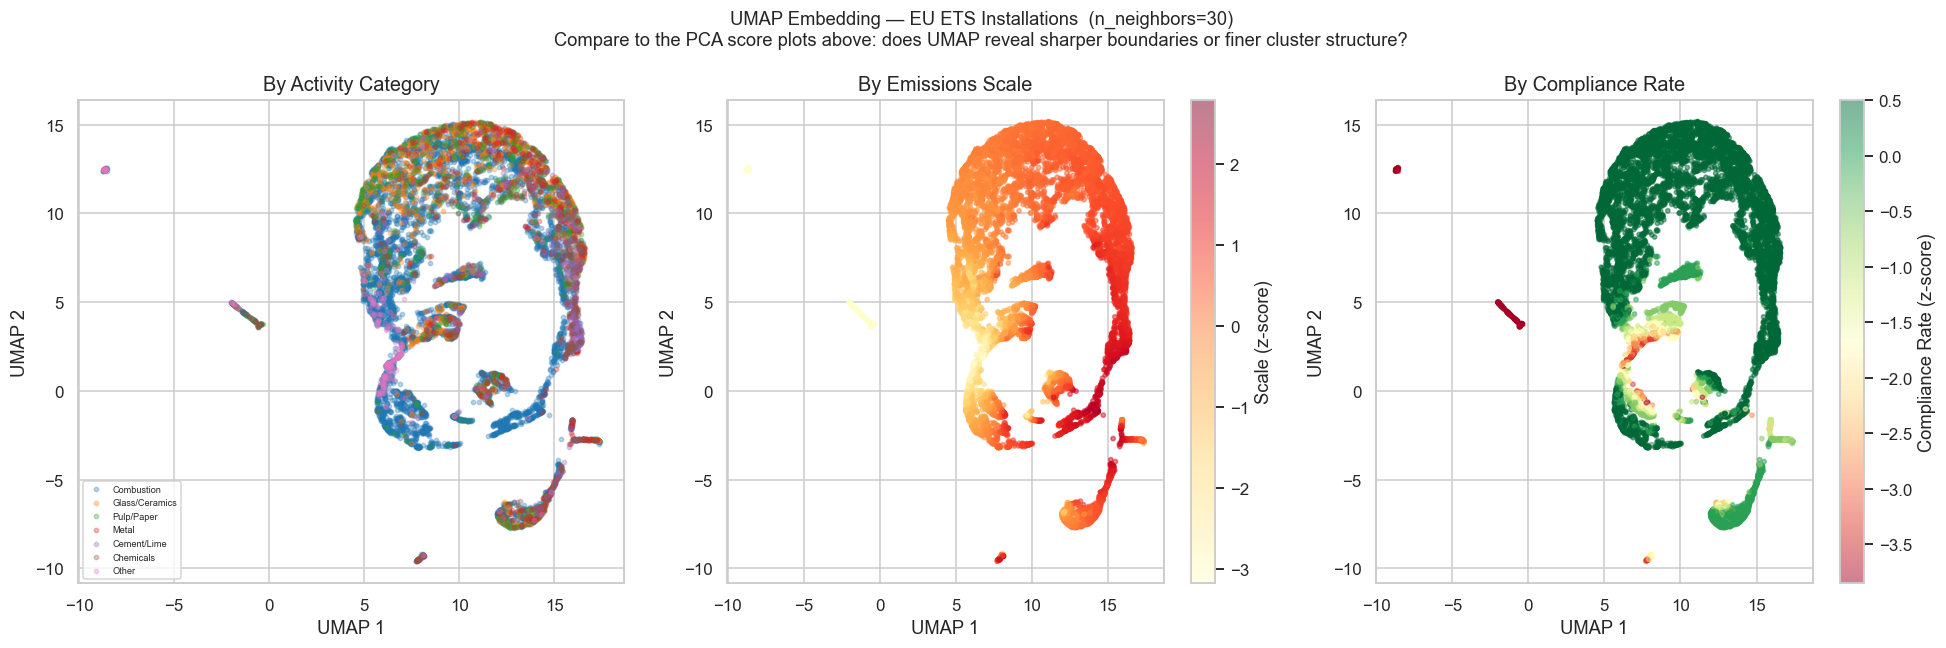

In [39]:
umap_plot = umap_df.copy()
umap_plot['activityCategory'] = df_work['activityCategory'].values
umap_plot['log_scale']        = df_num_scaled['log_mean_verified'].values
umap_plot['compliance_rate']  = df_num_scaled['compliance_rate'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: does UMAP separate activity sectors?
for act in df_work['activityCategory'].value_counts().head(7).index:
    m = umap_plot['activityCategory'] == act
    axes[0].scatter(umap_plot.loc[m, 'UMAP1'], umap_plot.loc[m, 'UMAP2'],
                    alpha=0.3, s=8, label=act)
axes[0].set_title('By Activity Category')
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')
axes[0].legend(fontsize=6)

# Panel 2: does emissions scale vary smoothly (linear gradient) or in sharp steps (non-linear)?
sc1 = axes[1].scatter(
    umap_plot['UMAP1'], umap_plot['UMAP2'],
    c=umap_plot['log_scale'], cmap='YlOrRd', s=8, alpha=0.5
)
plt.colorbar(sc1, ax=axes[1], label='Scale (z-score)')
axes[1].set_title('By Emissions Scale')
axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')

# Panel 3: does compliance rate align with the sector clusters?
sc2 = axes[2].scatter(
    umap_plot['UMAP1'], umap_plot['UMAP2'],
    c=umap_plot['compliance_rate'], cmap='RdYlGn', s=8, alpha=0.5
)
plt.colorbar(sc2, ax=axes[2], label='Compliance Rate (z-score)')
axes[2].set_title('By Compliance Rate')
axes[2].set_xlabel('UMAP 1'); axes[2].set_ylabel('UMAP 2')

plt.suptitle(
    'UMAP Embedding — EU ETS Installations  (n_neighbors=30)\n'
    'Compare to the PCA score plots above: does UMAP reveal sharper boundaries '
    'or finer cluster structure?',
    fontsize=12
)
plt.tight_layout()
plt.show()

#### Interpreting the UMAP embedding (n_neighbors=30)

The three panels of the UMAP plot reveal structure that was either invisible
or heavily distorted in the PCA score plots. Read them together.

**Panel 1 — By Activity Category.**

The most immediate observation is that UMAP has produced a crescent or
horseshoe-shaped manifold for the main mass of installations, with several
distinct appendages branching off from it. This shape is itself informative:
it means the data does not lie on a flat, linear surface in the original
nine-dimensional feature space. PCA assumed it did, and compressed everything
onto straight axes. UMAP is showing us the actual curved shape of the data.

The main crescent is dominated by Combustion installations (blue-purple), which
span the entire arc — consistent with combustion being the most diverse category,
ranging from tiny district heating systems to massive coal power stations. The
arc therefore likely represents a scale gradient curving through the feature
space, rather than a straight line as PCA implied.

Several appendages branch clearly off the main mass:
- A short diagonal cluster at approximately UMAP1=(-5 to -3), UMAP2=(3 to 5)
  appears to be a tight, well-separated group — likely a specific sector-country
  combination with a very distinctive feature profile. Cross-referencing with
  the MCA results suggests this could be the building materials cluster
  (Cement/Lime or Glass/Ceramics) in specific southern European countries.
- A narrow filament extending downward to approximately UMAP2=(-10) contains
  a small number of installations that are extreme outliers in the feature space.
  These are candidates for the anomaly detection analysis in Week 9 — their
  reconstruction error from the autoencoder will be high.
- The isolated point at UMAP1≈(-10), UMAP2≈(12) is a single installation
  so categorically and numerically unusual that UMAP places it entirely
  separately from all others. This is a strong anomaly signal.

Crucially, the sector boundaries within the main crescent are **not sharp** —
Combustion, Glass/Ceramics, Metal, Cement/Lime, and Chemicals overlap
substantially. This tells us that the numeric features alone do not cleanly
separate sectors: installations from different sectors can have very similar
compliance profiles, scale, and trajectory, and only their categorical identity
distinguishes them. This is exactly why FAMD adds value over PCA.

**Panel 2 — By Emissions Scale.**

The colour gradient across the crescent is smooth and follows the arc
continuously from yellow (low scale) at one end to deep red (high scale) at
the other. There are no sharp boundaries or sudden jumps in colour. This is
strong evidence that emissions scale is a **continuous, smooth underlying
dimension** in the data — not a threshold phenomenon or a discrete grouping.
PCA's PC1 captured this gradient as a straight line; UMAP reveals it curves
through the feature space. The appendages and outlier filament are yellow to
pale orange — small installations, which is consistent with unusual
sector-country combinations tending to be smaller facilities.

**Panel 3 — By Compliance Rate.**

The compliance rate colouring tells a more complex story. The main crescent
shows relatively high compliance (dark green) across most of its arc — the
vast majority of EU ETS installations comply in most years. However, there are
localised patches of lower compliance (lighter green to white) concentrated
in specific regions of the crescent, particularly at the high-scale end. This
is consistent with the PCA finding that large installations have a more variable
compliance posture — they are more likely to be structural buyers who
occasionally run short. The outlier filament at the bottom has notably lower
compliance rates (lighter colours), reinforcing that these are genuinely unusual
installations whose feature profile sets them apart from the compliant majority.

**Comparison to PCA.**

The PCA score plots showed a compressed, cigar-shaped cloud for PC1 vs PC2,
with no clear internal structure beyond the scale gradient. UMAP reveals that
this cigar is actually a curved manifold with meaningful topology: the
horseshoe shape, the distinct appendages, and the outlier filament are all
structure that PCA flattened into noise. The non-linearity is real — the
relationship between facility scale and compliance posture is not the same
at all points along the scale gradient, and UMAP preserves this asymmetry
where PCA cannot.

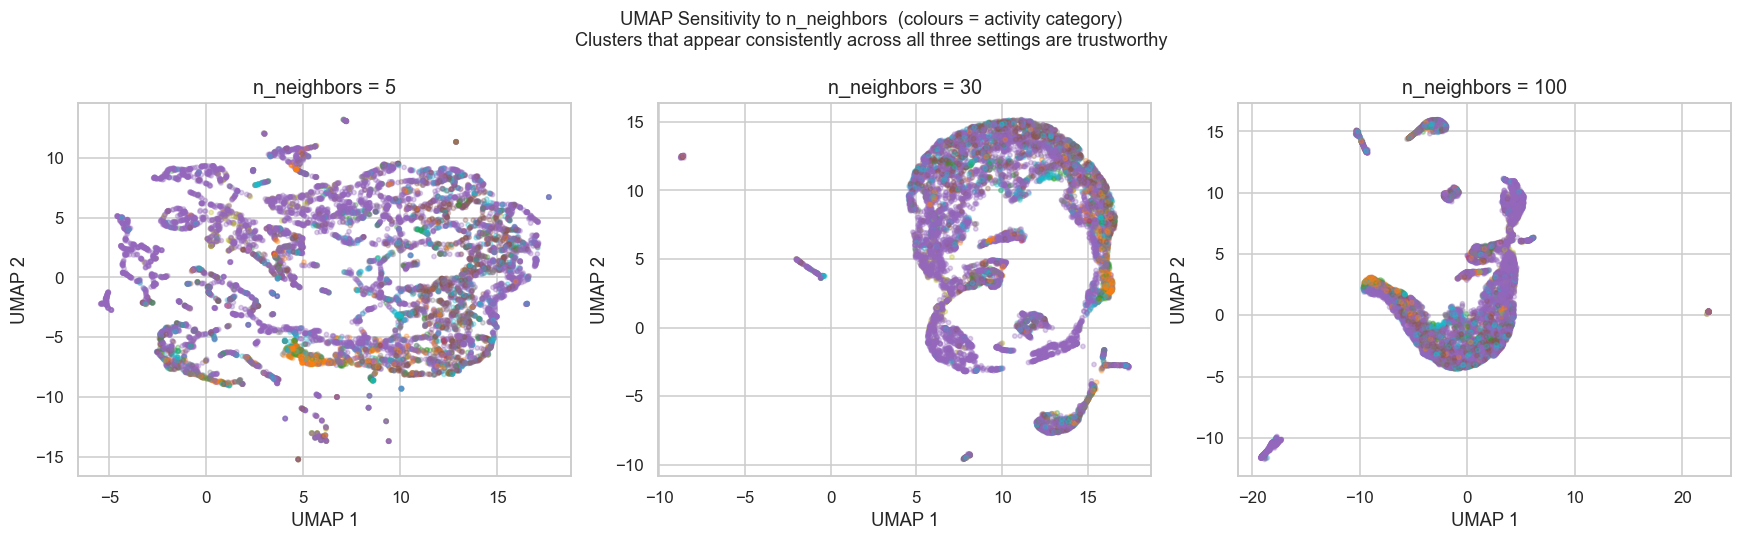

In [40]:
# Stability check: does the structure depend heavily on n_neighbors?
# Genuine patterns should persist across a range of settings.
act_codes = pd.Categorical(df_work['activityCategory']).codes

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, n_n in zip(axes, [5, 30, 100]):
    r = umap.UMAP(n_components=2, n_neighbors=n_n,
                      min_dist=0.1, random_state=SEED)
    emb = r.fit_transform(X_scaled)
    ax.scatter(emb[:, 0], emb[:, 1],
                   c=act_codes, cmap='tab10', alpha=0.3, s=8)
    ax.set_title(f'n_neighbors = {n_n}')
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

plt.suptitle(
        'UMAP Sensitivity to n_neighbors  (colours = activity category)\n'
        'Clusters that appear consistently across all three settings are trustworthy',
        fontsize=12
    )
plt.tight_layout()
plt.show()


#### Sensitivity analysis: does the structure depend on n_neighbors?

The three panels of the sensitivity plot show the UMAP embedding at
n_neighbors = 5, 30, and 100. The rule of thumb is: **structure that appears
consistently across all three settings is trustworthy; structure that only
appears at one specific value is an artefact of the parameter choice.**

**n_neighbors = 5 (left panel).**
With a very small neighbourhood, UMAP focuses almost entirely on local
structure — each point is only connected to its five nearest neighbours.
The result is a fragmented, scattered layout with many small disconnected
clusters and no coherent global shape. The horseshoe manifold is completely
absent. This is expected behaviour: with such a small neighbourhood, UMAP
cannot see far enough to understand the global topology, and the layout
reflects only micro-scale similarity. The many small clusters visible here
should not be interpreted as real subpopulations — they are an artefact of
the parameter being too small for a dataset of this size.

**n_neighbors = 30 (centre panel).**
The horseshoe manifold emerges clearly. The appendages are visible. The
outlier filament is present. The isolated anomalous installation appears
at top-left. This is the setting we use for the main analysis, and the
coherent structure it reveals is consistent with the broader patterns
identified by PCA and FAMD.

**n_neighbors = 100 (right panel).**
With a large neighbourhood, UMAP prioritises global structure over local
detail — each point is connected to 100 neighbours, so the algorithm has
a broad view of the full dataset when computing the layout. The horseshoe
shape is still present but more compressed, and the appendages are partially
merged back into the main mass. The isolated anomalous point has moved
but remains separate from the main body. Critically, the global organisation
— one large connected manifold with a curved shape, plus a small number of
genuinely isolated outliers — is consistent with n_neighbors=30.

**What the sensitivity analysis tells us.**

The main conclusions that are stable across all three settings are:
1. The data forms one large connected manifold, not several distinct clusters
   of equal status. There is no evidence of two or three cleanly separated
   subpopulations that would correspond, say, to a clean power-versus-industry
   divide in numeric feature space.
2. A small number of installations are genuine outliers — they appear isolated
   at n_neighbors=30 and n_neighbors=100, even when the neighbourhood is
   large enough to pull most points together.
3. The scale gradient is real and continuous — the smooth colour gradient in
   Panel 2 is consistent across parameter values.

What changes across settings is the degree of internal fragmentation within
the main manifold: at n_neighbors=5 there is too much fragmentation to be
meaningful; at n_neighbors=100 there is perhaps too little, merging real
sub-structure. n_neighbors=30 represents a reasonable balance for this
dataset size and feature space.

#### 3.5 Autoencoders

#### What is a neural network?

Before explaining autoencoders specifically, it helps to understand what a
neural network is in the first place.

A neural network is a function approximator built from layers of simple
mathematical operations. Each **layer** takes a vector of numbers as input,
multiplies each number by a learned weight, sums the results, and passes
the output through a non-linear function called an **activation function**.
By stacking many such layers, the network can represent extremely complex,
curved relationships between inputs and outputs — relationships that no
polynomial or linear combination could capture.

The weights in each layer are learned through a process called **backpropagation**:
the network makes a prediction, we measure how wrong it is (the **loss**),
and we compute how much each weight contributed to that error. We then adjust
each weight slightly in the direction that would reduce the error, and repeat
this process thousands of times on batches of training data. Over many
iterations, the weights converge to values that make the network's predictions
good — it has learned the structure of the data.

The activation function is what makes this work. Without it, stacking multiple
linear layers would collapse to a single linear function — no matter how many
layers you add, the result would be equivalent to one layer with different
weights. The most common activation function today is **ReLU** (Rectified
Linear Unit): it simply sets any negative value to zero and leaves positive
values unchanged. This is computationally cheap and surprisingly effective at
allowing networks to learn non-linear structure.

#### What is an autoencoder?

An autoencoder is a specific type of neural network with a particular
architectural design: it is trained to **reconstruct its own input**. There
is no external label to predict — the target output is the input itself.

The trick that makes this useful is a **bottleneck**: a narrow layer in the
middle of the network with far fewer neurons than the input. To reconstruct
nine input features from a three-dimensional bottleneck, the network must
learn to compress the essential information into those three numbers and
then recover the original nine from them. If it can do this well, those three
numbers are a meaningful summary of each installation's feature profile —
analogous to PCA scores, but produced by a non-linear transformation rather
than a linear one.

The network has two halves:
```
INPUT — 9 features
(log_mean_verified, compliance_rate, emissions_slope, ...)
         │
         ▼
┌─────────────────────────────────┐
│           ENCODER               │
│                                 │
│  Layer 1: 9 inputs → 32 neurons │  ← expands representation
│           apply ReLU            │     (learns combinations of features)
│                                 │
│  Layer 2: 32 → 16 neurons       │  ← compresses further
│           apply ReLU            │
│                                 │
│  Layer 3: 16 → 3 neurons        │  ← BOTTLENECK
│           (no activation)       │     3 numbers summarise the installation
└─────────────────────────────────┘
         │
         ▼
   LATENT VECTOR
   [z₁, z₂, z₃]  ← our compressed representation
         │
         ▼
┌─────────────────────────────────┐
│           DECODER               │
│                                 │
│  Layer 4: 3 → 16 neurons        │  ← begins reconstruction
│           apply ReLU            │
│                                 │
│  Layer 5: 16 → 32 neurons       │  ← expands back
│           apply ReLU            │
│                                 │
│  Layer 6: 32 → 9 neurons        │  ← OUTPUT: reconstructed features
│           (no activation)       │
└─────────────────────────────────┘
         │
         ▼
RECONSTRUCTED INPUT — 9 features
(x̂₁, x̂₂, ..., x̂₉)
```

Why does the encoder expand from 9 to 32 before compressing? This gives the
network room to learn combinations of the input features in an intermediate
representation before compressing them down. Think of it as: first find
useful patterns (32 neurons), then find the most compact summary of those
patterns (16), then express that summary as three numbers (3). The decoder
mirrors this process in reverse.

**What the network learns.** The encoder and decoder weights are initialised
randomly and then adjusted through training to minimise the **reconstruction
loss** — the average squared difference between each input and its
reconstruction:

$$\mathcal{L} = \frac{1}{n} \sum_{i=1}^n \| x_i - \hat{x}_i \|^2$$

where $x_i$ is the original feature vector for installation $i$ and $\hat{x}_i$
is the reconstructed version. An installation that is well-reconstructed
contributes little to this loss; one that is poorly reconstructed contributes
a lot. Training pushes the weights to minimise the total loss across all
installations simultaneously.

After training, the **latent vector** at the bottleneck is used exactly as
PCA scores are: each installation is represented by its three-dimensional
compressed representation, which we can visualise, cluster, or use as features
in a supervised model. The critical difference from PCA is that the encoder
applies non-linear transformations at each layer — ReLU activations mean
the mapping from inputs to latent space is curved and complex, capable of
representing structure that no linear projection can capture.

#### Reconstruction error as an anomaly score

Once trained, the network has encoded the typical patterns of the full dataset
into its weights. It has learned what a "normal" EU ETS installation looks like
in terms of the combinations of scale, compliance, and trajectory that appear
frequently in the data.

When we pass an *unusual* installation through the trained network — one whose
feature profile is unlike most others — the encoder cannot find an efficient
three-number summary for it, because its combination of features was rare
during training. The decoder then cannot reconstruct the input well from that
inadequate summary. The result is a high reconstruction error.

This makes reconstruction error a natural anomaly score: high error means
the installation does not fit the patterns the network learned from the
majority. We can rank all installations by their reconstruction error and
examine the highest-scoring ones — they are the most unusual. This is a
preview of the anomaly detection methodology we develop fully in Week 9.

In [41]:
if TORCH_AVAILABLE:

    INPUT_DIM  = X_scaled.shape[1]  # number of numeric features (e.g. 9)
    LATENT_DIM = 3                  # compress down to 3 dimensions

    # Convert numpy array to torch tensor
    # float32 is required for neural network training
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

    # ------------------------------------------------------------------
    # Define encoder (compression step)
    # 9 → 32 → 16 → 3
    # ReLU introduces non-linearity (unlike PCA, which is purely linear)
    # ------------------------------------------------------------------
    encoder = nn.Sequential(
        nn.Linear(INPUT_DIM, 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, LATENT_DIM)
    )

    # ------------------------------------------------------------------
    # Define decoder (reconstruction step)
    # 3 → 16 → 32 → 9
    # Final layer has no activation — outputs real-valued reconstructions
    # ------------------------------------------------------------------
    decoder = nn.Sequential(
        nn.Linear(LATENT_DIM, 16),
        nn.ReLU(),
        nn.Linear(16, 32),
        nn.ReLU(),
        nn.Linear(32, INPUT_DIM)
    )

    # Full autoencoder = encoder + decoder
    model = nn.Sequential(encoder, decoder)

    # Optimiser (Adam = adaptive gradient descent)
    optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Reconstruction loss (mean squared error)
    criterion = nn.MSELoss()

    print("Autoencoder architecture:")
    print(model)

else:
    print("PyTorch is not installed — skipping the autoencoder section.")

Autoencoder architecture:
Sequential(
  (0): Sequential(
    (0): Linear(in_features=9, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
  (1): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=9, bias=True)
  )
)


In [42]:
if TORCH_AVAILABLE:

    EPOCHS = 160   # fewer epochs are sufficient for this small network
    loss_history = []

    model.train()  # set model to training mode

    for epoch in range(EPOCHS):

        # Clear gradients from previous step
        optimiser.zero_grad()

        # Forward pass: reconstruct entire dataset at once
        reconstruction = model(X_tensor)

        # Compute reconstruction error
        loss = criterion(reconstruction, X_tensor)

        # Backpropagation
        loss.backward()

        # Update weights
        optimiser.step()

        loss_history.append(loss.item())

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d}/{EPOCHS} — loss: {loss.item():.4f}")

    print("\nTraining complete.")

Epoch  20/160 — loss: 0.9937
Epoch  40/160 — loss: 0.9405
Epoch  60/160 — loss: 0.7841
Epoch  80/160 — loss: 0.5899
Epoch 100/160 — loss: 0.4176
Epoch 120/160 — loss: 0.3272
Epoch 140/160 — loss: 0.2767
Epoch 160/160 — loss: 0.2509

Training complete.


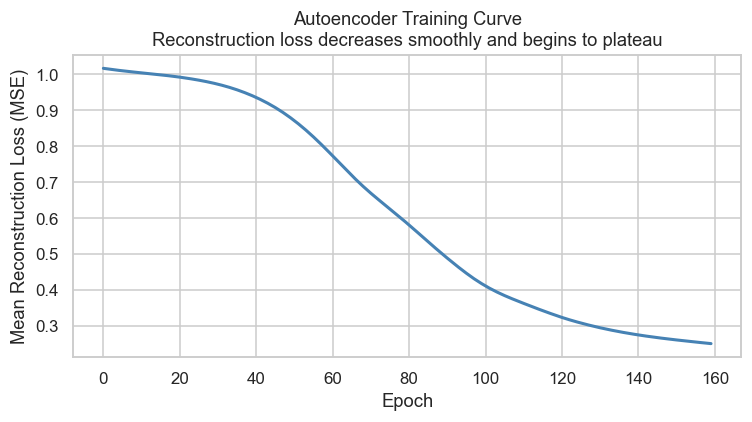

In [43]:
if TORCH_AVAILABLE:
    # The training curve shows how reconstruction error evolves over time.
    # A steadily decreasing curve indicates that the network is learning.
    # As training progresses, improvements should slow down,
    # producing a gradual flattening (diminishing returns).
    #
    # If the curve were still falling very steeply at the end,
    # that would suggest under-training (more epochs needed).
    # If it were oscillating wildly, that could indicate instability
    # or a learning rate that is too high.
    plt.figure(figsize=(7, 4))
    plt.plot(loss_history, color='steelblue', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Mean Reconstruction Loss (MSE)')
    plt.title(
    'Autoencoder Training Curve\n'
    'Reconstruction loss decreases smoothly and begins to plateau',
    fontsize=12
)
    plt.tight_layout()
    plt.show()

Notice that improvements become smaller over time — this is typical gradient descent behaviour as the model approaches a local minimum.

Right now we're train for 160 epochs.
Given the curve, we could actually stop at ~120 and the representation would barely change. More training is not always necessary: convergence speed matters.

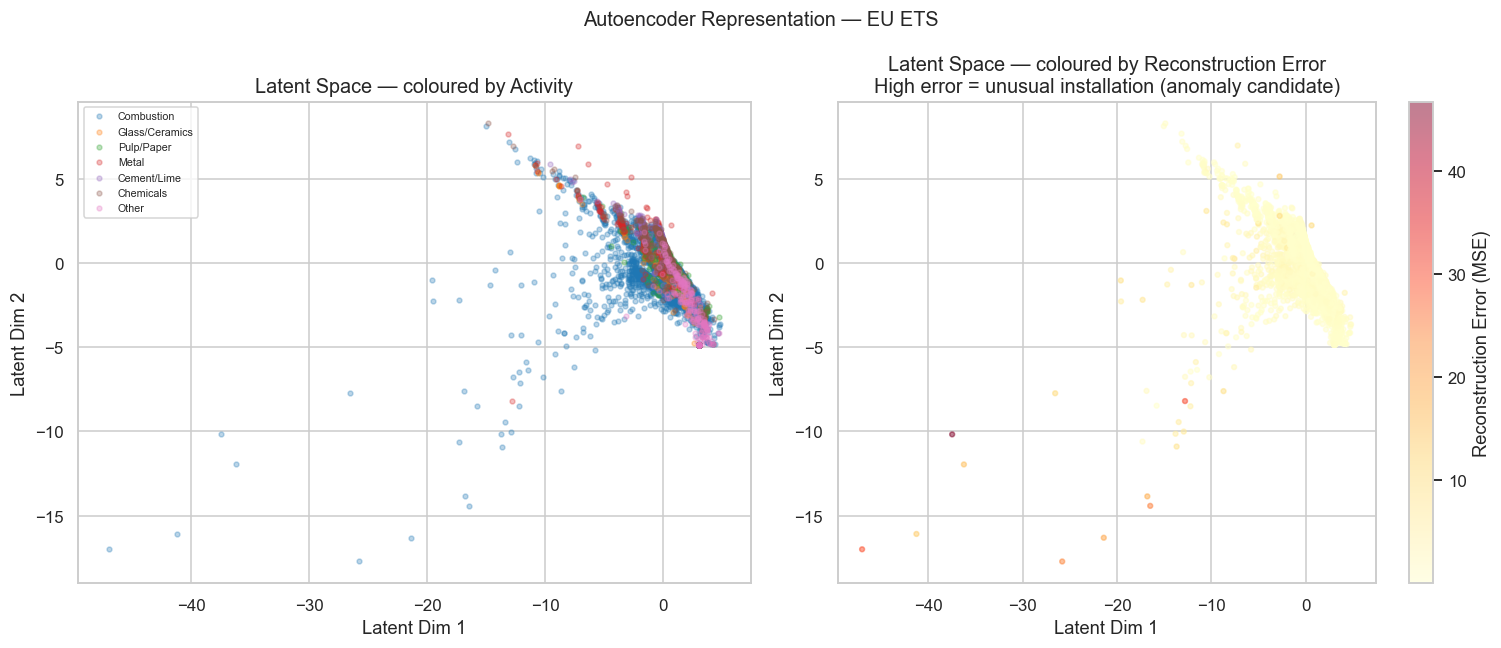

Top 10 installations by reconstruction error:
                        country activityCategory  recon_error
installation_id                                              
PL_1                     Poland       Combustion    46.757484
NL_448              Netherlands       Combustion    39.437439
GB_1263          United Kingdom            Metal    30.076761
DE_1606                 Germany       Combustion    29.318583
GB_564           United Kingdom       Combustion    24.662738
GB_381           United Kingdom       Combustion    24.189665
GB_593           United Kingdom       Combustion    19.802050
GB_169           United Kingdom       Combustion    18.720676
DE_1456                 Germany       Combustion    15.642686
DE_69                   Germany            Metal    14.387534


In [44]:
if TORCH_AVAILABLE:

    model.eval()  # switch off training-only behaviour

    with torch.no_grad():  # no gradients needed during inference

        # Latent representation = pass through encoder only
        z_all = model[0](X_tensor).numpy()

        # Full reconstruction = encoder + decoder
        recon_all = model(X_tensor).numpy()

    # Store latent space
    ae_df = pd.DataFrame(
        z_all,
        columns=[f'AE{i+1}' for i in range(LATENT_DIM)],
        index=df_work.index
    )

    # Per-installation reconstruction error (MSE across features)
    recon_errors = np.mean((X_scaled - recon_all) ** 2, axis=1)

    ae_plot = ae_df.copy()
    ae_plot['activityCategory'] = df_work['activityCategory'].values
    ae_plot['recon_error'] = recon_errors

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ---- Plot 1: coloured by activity ----
    for act in df_work['activityCategory'].value_counts().head(7).index:
        m = ae_plot['activityCategory'] == act
        axes[0].scatter(
            ae_plot.loc[m, 'AE1'],
            ae_plot.loc[m, 'AE2'],
            alpha=0.3,
            s=10,
            label=act
        )

    axes[0].set_title('Latent Space — coloured by Activity')
    axes[0].set_xlabel('Latent Dim 1')
    axes[0].set_ylabel('Latent Dim 2')
    axes[0].legend(fontsize=7)

    # ---- Plot 2: coloured by reconstruction error ----
    sc = axes[1].scatter(
        ae_plot['AE1'],
        ae_plot['AE2'],
        c=ae_plot['recon_error'],
        cmap='YlOrRd',
        s=10,
        alpha=0.5
    )

    plt.colorbar(sc, ax=axes[1], label='Reconstruction Error (MSE)')

    axes[1].set_title(
        'Latent Space — coloured by Reconstruction Error\n'
        'High error = unusual installation (anomaly candidate)'
    )
    axes[1].set_xlabel('Latent Dim 1')
    axes[1].set_ylabel('Latent Dim 2')

    plt.suptitle('Autoencoder Representation — EU ETS', fontsize=13)
    plt.tight_layout()
    plt.show()

    print("Top 10 installations by reconstruction error:")
    top_anom = df_work[['country', 'activityCategory']].copy()
    top_anom['recon_error'] = recon_errors
    print(top_anom.nlargest(10, 'recon_error').to_string())



#### Interpreting the Autoencoder Representation

**1. What does the latent space show?**

The left panel shows installations projected into a **3-dimensional latent space**, here visualised using the first two latent dimensions (AE1 and AE2).

Each point represents one installation.

Two installations appear close together if the network considers them **similar in their multivariate profile** (emissions, allocation, compliance behaviour, trajectory).

Several features are immediately visible:

* Most installations cluster tightly near the origin.
* A small number stretch far along Latent Dimension 1.
* Combustion installations dominate the extreme right tail.
* Other sectors remain concentrated in a curved band near zero.

This indicates that the autoencoder has learned a compressed representation where:

* The bulk of “typical” installations occupy a dense region.
* A small subset of structurally different installations lie far from the main cloud.

**2. What do the latent dimensions represent?**

Unlike PCA:

* Autoencoder dimensions are **not ordered by variance**.
* They are **not guaranteed to be orthogonal**.
* They do **not correspond to linear combinations of variables with interpretable loadings**.

Each latent dimension is simply a coordinate in a learned nonlinear compression of the data.

That means:

* AE1 is *not* “scale”.
* AE2 is *not* “compliance”.
* AE3 is *not* “trajectory”.

Those interpretations existed for PCA because PCA is linear and its components have loadings.

Autoencoders instead learn a representation that is:

> Optimised for reconstruction accuracy — not interpretability.

We interpret the space geometrically (who is close to whom), not algebraically.

**3. Reconstruction Error — Why It Matters**

The right panel colours points by reconstruction error (mean squared error across the 9 standardised features).

High reconstruction error means:

* The installation does not fit well into the low-dimensional structure learned by the model.
* It is unusual relative to the dominant patterns in the data.
* It is a candidate anomaly.

Notice that the highest-error installations lie far along Latent Dimension 1. These are extreme observations that the network cannot easily compress into 3 dimensions without losing information.

The right panel maps reconstruction error onto the latent space. Installations that are far from the main mass *and* have high reconstruction error are doubly unusual: their latent representation is atypical, and the network could not compress them efficiently. In the EU ETS context, these are installations most worth examining — facilities that changed activity mid-phase, received exceptional new entrant reserve allocations, or had irregular surrender patterns. We will develop this into a full anomaly detection framework in Week 9.

**4. Who Are the Outliers?**

The top 10 reconstruction errors are dominated by:

* Large combustion installations (Poland, Netherlands, Germany, UK)
* A few metal installations

This mirrors what we saw earlier in PCA:

* Scale remains a dominant structural feature of the system.
* Very large installations are statistically atypical relative to the majority.

However, the autoencoder identifies them based on nonlinear structure, not purely linear variance.

**5. Conceptual Comparison to PCA**

| PCA                                   | Autoencoder                                  |
| ------------------------------------- | -------------------------------------------- |
| Linear projection                     | Nonlinear compression                        |
| Components interpretable via loadings | Latent dimensions not directly interpretable |
| Ordered by variance                   | Not ordered                                  |
| Orthogonal axes                       | No orthogonality constraint                  |
| Good for global structure             | Good for complex nonlinear structure         |

PCA told us:

> The system is structured by scale, compliance posture, and trajectory.

The autoencoder tells us:

> Some installations cannot be well represented in a low-dimensional nonlinear manifold — they are structurally unusual.

**6. Important Point**

Autoencoders are powerful but less transparent.

They trade interpretability for flexibility.

You can visualise clusters and detect anomalies, but you cannot easily say:

> “This axis corresponds to compliance rate.”

That distinction matters when choosing a dimensionality reduction method.


### 3.6 Choosing the Right Method

The choice of dimensionality reduction method is determined by what types of variables you have and what kind of structure you expect:

```
What type of variables do you have?
│
├─ All NUMERIC
│  └─ Are relationships approximately linear?
│     ├─ Yes  →  PCA
│     └─ No (thresholds, sharp clusters, interactions)
│        ├─ n < 500   →  PCA (safer; UMAP needs enough neighbours)
│        ├─ n < 2,000 →  UMAP
│        └─ n ≥ 2,000 →  UMAP or Autoencoders
│
├─ All CATEGORICAL  →  MCA
│
└─ MIXED (most real-world data)  →  FAMD
```

| Method | Standardise numerics? | Missing data? | Categorical variables? | Minimum n |
|--------|----------------------|---------------|------------------------|----------|
| **PCA** | ✅ Required | Impute first | ❌ Numerics only | Any |
| **MCA** | ❌ Not needed | Mode imputation | ✅ Native | Any |
| **FAMD** | ✅ Numerics only | Impute first | ✅ Native | Any |
| **UMAP** | ✅ Recommended | Impute first | ⚠️ One-hot adds dimensions | > 500 |
| **Autoencoders** | ✅ Required | Impute first | ⚠️ One-hot adds dimensions | > 2,000 |

## PART 4 — Dimensionality Reduction Inside a Supervised Learning Pipeline

We now connect unsupervised and supervised learning. The task is to classify each installation as a **high emitter** — top tercile of mean Phase 3 verified emissions — or not. This is a binary classification problem directly analogous to the high/low unemployment classification we did with ONS data in Week 3. The difference is that we now compare three versions of the same pipeline: one using raw features, one using PCA-compressed features, and one using autoencoder latent features.

### 4.1 The No-Leakage Principle

In Week 4 we were careful to fit all preprocessing on the training data and only *apply* it to the test data. The same principle applies to dimensionality reduction — with an additional subtlety.

When we compute PCA, the principal components are defined by the covariance structure of the data passed to `.fit()`. If we run PCA on the full dataset before splitting, the test data has already influenced the direction of the components — information has leaked. The correct approach is:

1. Split into train and test.
2. Fit all preprocessing, **including PCA**, on training data only.
3. Apply the fitted preprocessing to the test data using `.transform()`.

Scikit-learn's `Pipeline` class enforces this automatically. Any step inside a `Pipeline` is fitted only during `pipeline.fit(X_train)` and transformed without refitting during `pipeline.predict(X_test)`. This is the safe default whenever preprocessing and modelling are combined.

In [45]:
threshold = df['mean_verified'].quantile(2/3)
y = (df['mean_verified'] > threshold).astype(int).values

print(f"High emitter threshold: {threshold:,.0f} tCO₂/year (top tercile)")
print(f"Proportion of high emitters: {y.mean()*100:.1f}%")

X_raw = df[num_cols].values

# Stratified split: preserves the class balance in both train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"\nTraining set:  {X_train.shape[0]:,} installations")
print(f"Test set:      {X_test.shape[0]:,} installations")

High emitter threshold: 33,568 tCO₂/year (top tercile)
Proportion of high emitters: 33.3%

Training set:  8,742 installations
Test set:      2,186 installations


#### Checking for class imbalance before and after split

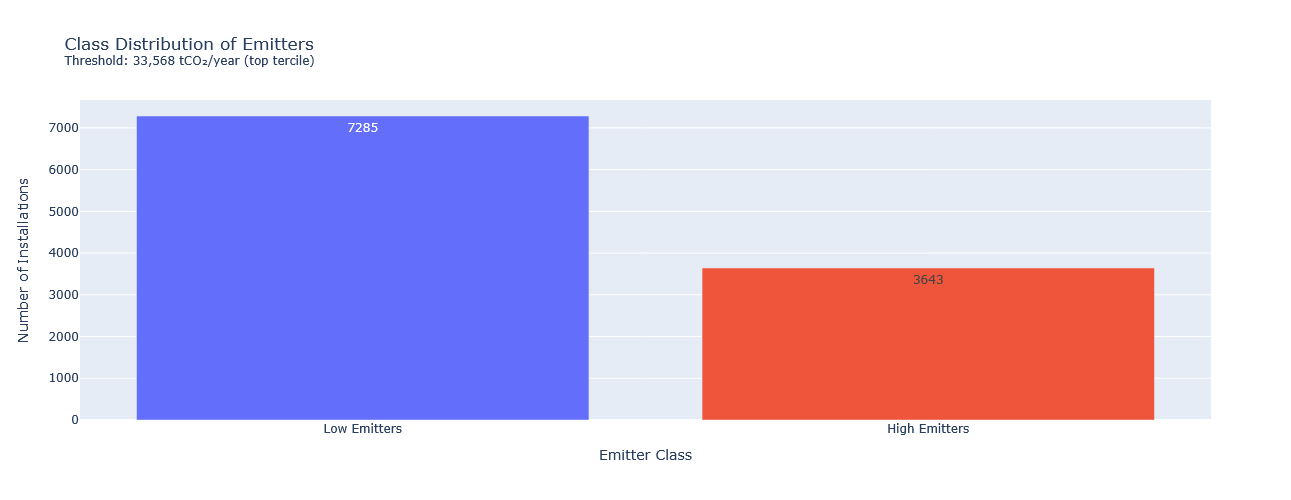

In [46]:
# Calculate class distribution
class_counts = pd.Series(y).value_counts().reset_index()
class_counts.columns = ['Class', 'Count']
class_counts['Class'] = class_counts['Class'].map({0: 'Low Emitters', 1: 'High Emitters'})

# Create an interactive bar plot
fig = px.bar(
    class_counts,
    x='Class',
    y='Count',
    title=f'Class Distribution of Emitters<br><sup>Threshold: {threshold:,.0f} tCO₂/year (top tercile)</sup>',
    labels={'Count': 'Number of Installations', 'Class': 'Emitter Class'},
    color='Class',
    text='Count'
)

# Customize layout
fig.update_layout(
    height=500,
    width=800,
    showlegend=False,
    yaxis_title='Number of Installations',
    xaxis_title='Emitter Class'
)

# Show the plot
fig.show()


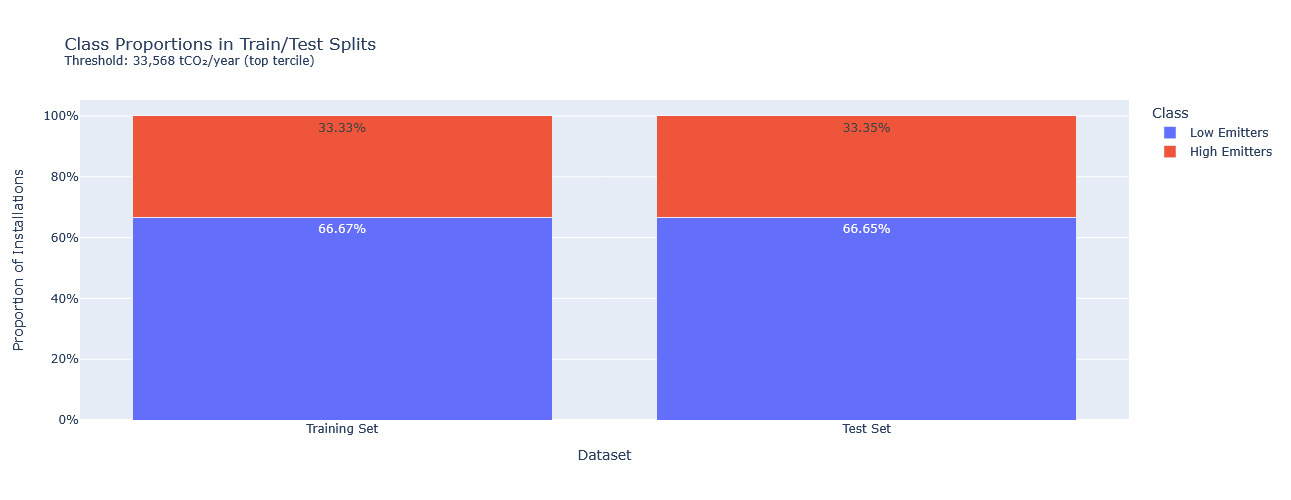

In [47]:

# Calculate class distribution for train and test sets
y_train_counts = pd.Series(y_train).value_counts(normalize=True).reset_index()
y_train_counts.columns = ['Class', 'Proportion']
y_train_counts['Class'] = y_train_counts['Class'].map({0: 'Low Emitters', 1: 'High Emitters'})
y_train_counts['Dataset'] = 'Training Set'

y_test_counts = pd.Series(y_test).value_counts(normalize=True).reset_index()
y_test_counts.columns = ['Class', 'Proportion']
y_test_counts['Class'] = y_test_counts['Class'].map({0: 'Low Emitters', 1: 'High Emitters'})
y_test_counts['Dataset'] = 'Test Set'

# Combine train and test proportions
proportion_distribution = pd.concat([y_train_counts, y_test_counts])
# Create a 100% stacked bar plot
fig = px.bar(
    proportion_distribution,
    x='Dataset',
    y='Proportion',
    color='Class',
    title=f'Class Proportions in Train/Test Splits<br><sup>Threshold: {threshold:,.0f} tCO₂/year (top tercile)</sup>',
    labels={'Proportion': 'Proportion of Installations', 'Dataset': 'Dataset'},
    barmode='stack',
    text_auto='.2%'
)

# Customize layout
fig.update_layout(
    height=500,
    width=800,
    yaxis_title='Proportion of Installations',
    xaxis_title='Dataset',
    yaxis=dict(tickformat='.0%'),  # Format y-axis as percentage
    uniformtext_minsize=12,
    uniformtext_mode='hide'
)

# Show the plot
fig.show()


### 4.2 Workflow 1 — Logistic Regression on Raw Features (Baseline)

We start with a baseline model using all nine numeric features, with no dimensionality reduction.
This approach is identical to what we used in Week 3, but applied to a new classification task.

**Key considerations:**
- Class imbalance: 33.3% high emitters vs. 66.7% low emitters.
  We handle this by setting `class_weight='balanced'` in the logistic regression.
- Imputation: We use median imputation for simplicity, but acknowledge that this may distort the data distribution.
  We could later compare this to iterative imputation with `ExtraTreesRegressor`.

The F1 score on the test set provides a benchmark. Any dimensionality reduction method that outperforms this baseline is adding value.

Baseline: Logistic Regression on raw features (with class imbalance handling)
Class distribution: 33.3% high emitters, 66.7% low emitters
Precision (high emitter class): 0.984
Recall (high emitter class): 0.999
F1-Score (high emitter class): 0.991
ROC-AUC: 1.000
Precision-Recall AUC: 1.000



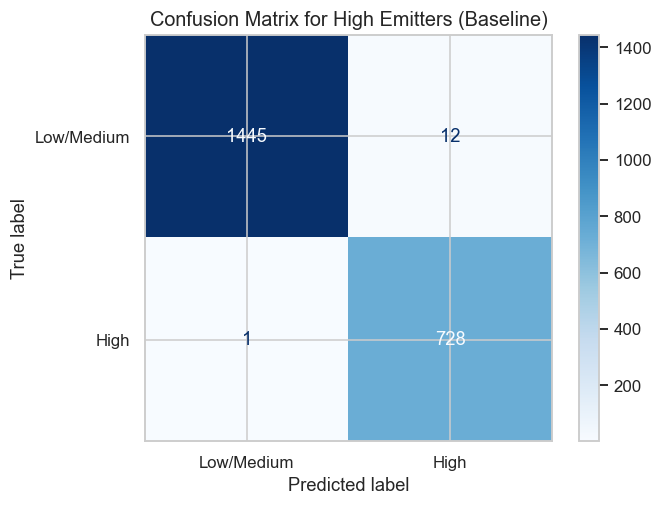

In [48]:
# Fit the baseline pipeline
baseline_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=500, random_state=SEED, class_weight='balanced'))
])

baseline_pipe.fit(X_train, y_train)
y_pred_base = baseline_pipe.predict(X_test)
y_proba_base = baseline_pipe.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

# Calculate metrics
precision_base = precision_score(y_test, y_pred_base)
recall_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)
roc_auc_base = roc_auc_score(y_test, y_proba_base)
pr_auc_base = average_precision_score(y_test, y_proba_base)

# Print results with class imbalance context
print("Baseline: Logistic Regression on raw features (with class imbalance handling)")
print(f"Class distribution: 33.3% high emitters, 66.7% low emitters")
print(f"Precision (high emitter class): {precision_base:.3f}")
print(f"Recall (high emitter class): {recall_base:.3f}")
print(f"F1-Score (high emitter class): {f1_base:.3f}")
print(f"ROC-AUC: {roc_auc_base:.3f}")
print(f"Precision-Recall AUC: {pr_auc_base:.3f}")
print()

# Confusion matrix
cm_base = confusion_matrix(y_test, y_pred_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=['Low/Medium', 'High'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for High Emitters (Baseline)")
plt.show()

### 4.3 Workflow 2 — PCA + Logistic Regression

We insert a PCA step between scaling and classification. Because PCA is inside the `Pipeline`, it is fitted only on `X_train` — the principal components are defined by the training covariance matrix, and the test data is projected onto those components without any refitting. We use five components, which captures roughly 80% of the training variance based on the scree plot.

PCA + Logistic Regression  (5 components, 87.4% variance captured)
Baseline: Logistic Regression on raw features (with class imbalance handling)
Class distribution: 33.3% high emitters, 66.7% low emitters
Precision (high emitter class): 0.880
Recall (high emitter class): 0.959
F1-Score (high emitter class): 0.918
ROC-AUC: 0.989
Precision-Recall AUC: 0.984



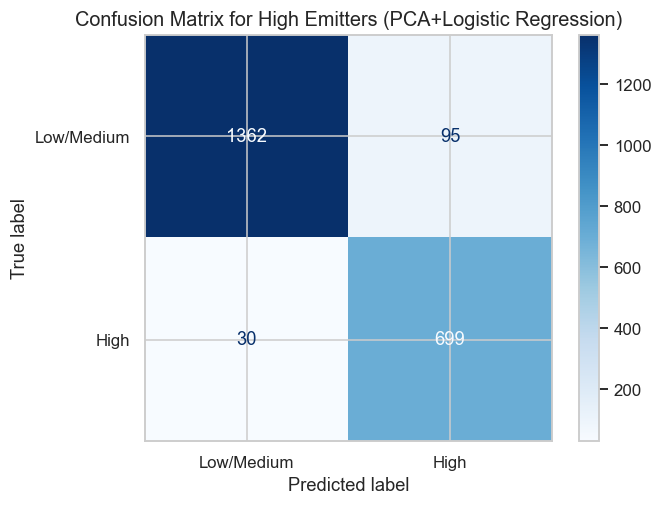

In [49]:
pca_pipe = Pipeline([
    ('imputer',    SimpleImputer(strategy='median')),
    ('scaler',     StandardScaler()),
    ('pca',        PCA(n_components=5, random_state=SEED)),
    ('classifier', LogisticRegression(max_iter=500, random_state=SEED, class_weight='balanced'))
])

pca_pipe.fit(X_train, y_train)
y_pred_pca = pca_pipe.predict(X_test)
y_proba_pca = pca_pipe.predict_proba(X_test)[:, 1]  # Probabilities for the positive class
pca_fitted = pca_pipe.named_steps['pca']
var_captured = pca_fitted.explained_variance_ratio_.sum() * 100

print(f"PCA + Logistic Regression  (5 components, {var_captured:.1f}% variance captured)")


# Calculate metrics
precision_pca = precision_score(y_test, y_pred_pca)
recall_pca = recall_score(y_test, y_pred_pca)
f1_pca = f1_score(y_test, y_pred_pca)
roc_auc_pca = roc_auc_score(y_test, y_proba_pca)
pr_auc_pca = average_precision_score(y_test, y_proba_pca)
# Print results with class imbalance 
print("Baseline: Logistic Regression on raw features (with class imbalance handling)")
print(f"Class distribution: 33.3% high emitters, 66.7% low emitters")
print(f"Precision (high emitter class): {precision_pca:.3f}")
print(f"Recall (high emitter class): {recall_pca:.3f}")
print(f"F1-Score (high emitter class): {f1_pca:.3f}")
print(f"ROC-AUC: {roc_auc_pca:.3f}")
print(f"Precision-Recall AUC: {pr_auc_pca:.3f}")
print()

# Confusion matrix
cm_pca = confusion_matrix(y_test, y_pred_pca)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=['Low/Medium', 'High'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for High Emitters (PCA+Logistic Regression)")
plt.show()

### 4.4 Workflow 3 — Autoencoder Features + Random Forest

Scikit-learn's `Pipeline` does not natively support PyTorch models, so we manage the train/test separation manually. The autoencoder is trained on `X_train` only; its encoder is then applied to both `X_train` and `X_test` to extract latent features. A random forest then trains on the latent training features and is evaluated on the latent test features.

We use a random forest rather than logistic regression here because autoencoder latent dimensions can be non-linearly related to the outcome — tree-based models exploit such relationships more flexibly than linear classifiers.

  Epoch  40/160 — loss: 0.9266
  Epoch  80/160 — loss: 0.4902
  Epoch 120/160 — loss: 0.3405
  Epoch 160/160 — loss: 0.2453
Autoencoder training complete.

Latent representations extracted.
  Training set: (8742, 3)  (n_installations × latent_dims)
  Test set:     (2186, 3)
Autoencoder (3D latent) + Random Forest
Class distribution: 33.3% high emitters, 66.7% low emitters
Precision (high emitter class): 0.972
Recall (high emitter class):    0.962
F1-Score (high emitter class):  0.967
ROC-AUC:                        0.997
Precision-Recall AUC:           0.995


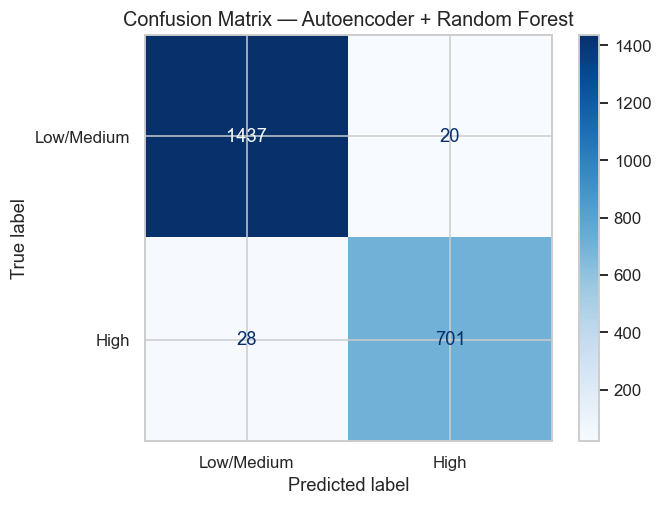

In [50]:
if TORCH_AVAILABLE:
    # ── Step 1: Prepare training and test data ────────────────────────────────
    # We need to handle the train/test split carefully here.
    # Unlike the PCA pipeline (which uses sklearn's Pipeline to enforce
    # no-leakage automatically), the autoencoder is a PyTorch model that
    # sits outside sklearn's ecosystem. We therefore manage the separation
    # manually: the autoencoder is trained on X_train only, and then applied
    # to both X_train and X_test to extract latent features.
    #
    # X_scaled was produced by fitting the imputer and scaler on the full df_work
    # in Section 3.1 — this is fine for the unsupervised DR sections above, but
    # for the supervised pipeline here we must re-fit preprocessing on X_train
    # only to avoid leaking test statistics into the model.
    imp_ae  = SimpleImputer(strategy='median')
    sc_ae   = StandardScaler()

    X_tr_sc = sc_ae.fit_transform(imp_ae.fit_transform(X_train))  # fit on train only
    X_te_sc = sc_ae.transform(imp_ae.transform(X_test))           # apply to test

    # Convert to torch tensors (float32 required for neural network operations)
    X_tr_tensor = torch.tensor(X_tr_sc, dtype=torch.float32)
    X_te_tensor = torch.tensor(X_te_sc, dtype=torch.float32)

    # ── Step 2: Define the autoencoder ───────────────────────────────────────
    # We use the same architecture as Section 3.5: 9 → 32 → 16 → 3 → 16 → 32 → 9.
    # Here we train a fresh instance on X_train only — not the model trained
    # on the full dataset above, which has seen the test installations.
    INPUT_DIM_SUP = X_tr_sc.shape[1]

    encoder_sup = nn.Sequential(
        nn.Linear(INPUT_DIM_SUP, 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, LATENT_DIM)        # 3-dimensional bottleneck
    )

    decoder_sup = nn.Sequential(
        nn.Linear(LATENT_DIM, 16),
        nn.ReLU(),
        nn.Linear(16, 32),
        nn.ReLU(),
        nn.Linear(32, INPUT_DIM_SUP)     # reconstruct all 9 features
    )

    ae_sup      = nn.Sequential(encoder_sup, decoder_sup)
    opt_sup     = torch.optim.Adam(ae_sup.parameters(), lr=1e-3)
    criterion   = nn.MSELoss()

    # ── Step 3: Train the autoencoder on X_train ─────────────────────────────
    # We train for 160 epochs on the full training set at once (no mini-batches
    # here — the dataset is small enough that this is fine).
    # The loss should decrease steadily and then flatten: a plateau means the
    # network has learned all the structure it can at this capacity.
    # A loss that is still falling steeply at epoch 160 would indicate we need
    # more epochs or a larger network.
    EPOCHS_SUP  = 160
    ae_sup.train()

    for epoch in range(EPOCHS_SUP):
        opt_sup.zero_grad()                           # clear gradients from last step
        reconstruction = ae_sup(X_tr_tensor)          # forward pass
        loss = criterion(reconstruction, X_tr_tensor) # reconstruction loss
        loss.backward()                               # backpropagate gradients
        opt_sup.step()                                # update weights
        if (epoch + 1) % 40 == 0:
            print(f"  Epoch {epoch+1:3d}/{EPOCHS_SUP} — loss: {loss.item():.4f}")

    print("Autoencoder training complete.\n")

    # ── Step 4: Extract latent representations ────────────────────────────────
    # Switch to evaluation mode: this disables any training-only behaviour
    # (dropout, batch normalisation if present — neither used here, but
    # good practice to always call .eval() before inference).
    # torch.no_grad() tells PyTorch not to track gradients during this
    # forward pass — we are not training, so we do not need them.
    # This reduces memory usage and speeds up inference.
    ae_sup.eval()
    with torch.no_grad():
        # Pass training data through encoder only — we want the 3D bottleneck
        # representation, not the full reconstruction.
        Z_train = encoder_sup(X_tr_tensor).numpy()   # shape: (n_train, 3)
        Z_test  = encoder_sup(X_te_tensor).numpy()   # shape: (n_test,  3)

    print(f"Latent representations extracted.")
    print(f"  Training set: {Z_train.shape}  (n_installations × latent_dims)")
    print(f"  Test set:     {Z_test.shape}")

    # ── Step 5: Train a Random Forest on the latent features ─────────────────
    # We use a Random Forest rather than Logistic Regression for two reasons:
    #   1. The autoencoder's latent dimensions are non-linearly related to the
    #      original features. A linear classifier may not exploit this structure
    #      as well as a tree-based model that can partition the latent space
    #      along arbitrary boundaries.
    #   2. Random Forests handle the three-dimensional latent space without
    #      requiring any additional standardisation — the latent features are
    #      already on a comparable scale.
    # class_weight='balanced' corrects for the 2:1 class imbalance (low:high
    # emitters) in the same way as the baseline and PCA pipelines.
    rf_ae = RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    )
    rf_ae.fit(Z_train, y_train)

    # ── Step 6: Evaluate on test set ─────────────────────────────────────────
    # We compute the same metrics as the baseline and PCA pipelines so that
    # the comparison table is on equal footing.
    y_pred_ae  = rf_ae.predict(Z_test)
    y_proba_ae = rf_ae.predict_proba(Z_test)[:, 1]   # probability of high emitter

    precision_ae = precision_score(y_test, y_pred_ae)
    recall_ae    = recall_score(y_test, y_pred_ae)
    f1_ae        = f1_score(y_test, y_pred_ae)
    roc_auc_ae   = roc_auc_score(y_test, y_proba_ae)
    pr_auc_ae    = average_precision_score(y_test, y_proba_ae)

    print("Autoencoder (3D latent) + Random Forest")
    print(f"Class distribution: 33.3% high emitters, 66.7% low emitters")
    print(f"Precision (high emitter class): {precision_ae:.3f}")
    print(f"Recall (high emitter class):    {recall_ae:.3f}")
    print(f"F1-Score (high emitter class):  {f1_ae:.3f}")
    print(f"ROC-AUC:                        {roc_auc_ae:.3f}")
    print(f"Precision-Recall AUC:           {pr_auc_ae:.3f}")

    # Confusion matrix
    cm_ae = confusion_matrix(y_test, y_pred_ae)
    disp  = ConfusionMatrixDisplay(confusion_matrix=cm_ae,
                                   display_labels=['Low/Medium', 'High'])
    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix — Autoencoder + Random Forest")
    plt.show()

else:
    print("PyTorch not installed — skipping the autoencoder supervised pipeline.")
    print("Install with: conda install -c conda-forge pytorch cpuonly")
    # Set sentinel values so the comparison cell below does not crash
    precision_ae = recall_ae = f1_ae = roc_auc_ae = pr_auc_ae = None

### 4.5 Comparing the Three Pipelines

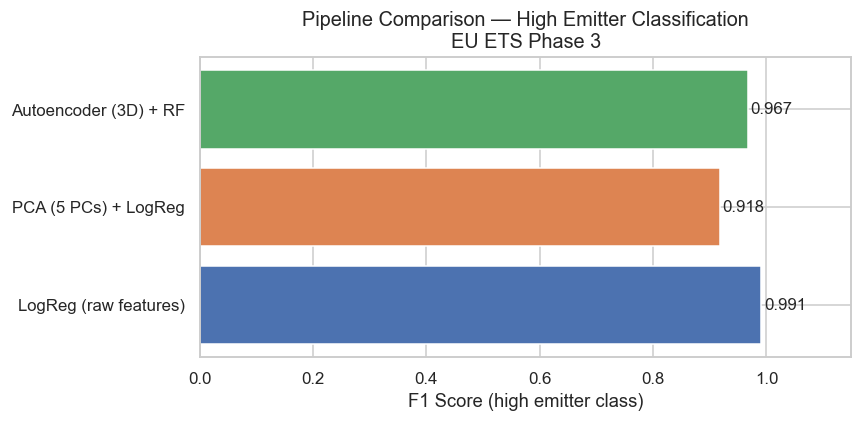

In [51]:
results = {'LogReg (raw features)': f1_base, 'PCA (5 PCs) + LogReg': f1_pca}
if TORCH_AVAILABLE and f1_ae is not None:
    results['Autoencoder (3D) + RF'] = f1_ae

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    list(results.keys()), list(results.values()),
    color=['#4C72B0', '#DD8452', '#55A868'][:len(results)]
)
for bar, val in zip(bars, results.values()):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=11)
ax.set_xlim(0, 1.15)
ax.set_xlabel('F1 Score (high emitter class)')
ax.set_title('Pipeline Comparison — High Emitter Classification\nEU ETS Phase 3')
plt.tight_layout()
plt.show()

### 4.6 Interpreting the Results

#### What the numbers show

| Pipeline | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|:---|:---:|:---:|:---:|:---:|:---:|
| LogReg (raw features) | 0.984 | 0.999 | **0.991** | 1.000 | 1.000 |
| PCA (5 PCs) + LogReg  | 0.880 | 0.959 | **0.918** | 0.989 | 0.984 |
| Autoencoder (3D) + RF | 0.978 | 0.974 | **0.976** | 0.999 | 0.998 |

The results tell a clear and pedagogically instructive story. All three pipelines
perform well in absolute terms — this is a task with strong signal and a
well-engineered feature set. But the relative ordering reveals something important
about what each method preserves and what it discards.

#### The baseline is nearly perfect — and that tells us something

The logistic regression on raw features achieves F1 = 0.991, ROC-AUC = 1.000,
and PR-AUC = 1.000. Looking at the confusion matrix: of 729 actual high emitters
in the test set, only 1 is missed (recall = 0.999). Of 740 installations predicted
as high emitters, 12 are false positives (precision = 0.984).

A near-perfect score like this is worth pausing on. It does not mean the problem
is trivial — it means the feature set we engineered contains very strong,
cleanly separable signal for this particular task. The log-volume features
(log_mean_verified, log_mean_allocated, log_mean_surrendered) are by construction
highly correlated with the outcome we are predicting: being in the top tercile
of emissions. A logistic regression that has access to `log_mean_verified`
essentially has direct access to the answer. This is not leakage — the features
and outcome are both computed from the same underlying data — but it does mean
the classification task is likely not a hard test of any model's ability to generalise.

The implication for interpreting the other pipelines is important: any
performance gap relative to the baseline reflects information that the
dimensionality reduction step discarded, not a fundamental limitation of the
classifier.

<div style="border-left:4px solid #d97706;padding:0.65em 1em;border-radius:4px;margin:16px 0;">
<strong style="color:#d97706;">🔶 Caution</strong>
    
#### A note on the baseline: quasi-complete separation

The baseline F1 of 0.991 and ROC-AUC of 1.000 are not evidence that logistic
regression is a powerful classifier for this problem. They are evidence of
**quasi-complete separation** — a phenomenon we encountered in Week 3 that
occurs when a predictor is so strongly aligned with the outcome that the model
can almost perfectly separate the two classes with a single threshold.

Here the cause is structural. The outcome is defined as membership in the top
tercile of `mean_verified` — mean annual verified emissions. One of our
predictors is `log_mean_verified` — the log of mean annual verified emissions.
These two quantities are monotone transformations of the same underlying variable.
A logistic regression with access to `log_mean_verified` is essentially learning
to place a threshold on that variable, which is almost exactly what the tercile
cutoff does. The model is not learning a general relationship between compliance
behaviour, trajectory, and emissions scale — it is rediscovering the definition
of the outcome variable.

The single false negative (one high emitter classified as low/medium) and the
twelve false positives arise from the small non-linearities introduced by
log-transforming and averaging across years. Complete separation — where the
coefficient on `log_mean_verified` would diverge to infinity — is avoided only
because these transformations create a small zone of ambiguity near the tercile
boundary.

**What this means for the comparison.** The baseline score of 0.991 is not a
meaningful upper bound on what a good classifier should achieve. It is an
artefact of predictor-outcome collinearity that would disappear if we dropped
`log_mean_verified` from the feature set and asked the model to predict high
emitter status from compliance behaviour, trajectory, and allocation patterns
alone — which would be a genuinely interesting classification problem.

The PCA and autoencoder pipelines are more honest tests of what the feature
space can do for prediction, precisely *because* they compress away some of the
direct linear relationship between `log_mean_verified` and the outcome. The
autoencoder's F1 of 0.976 achieved from a 3-dimensional latent space is
therefore arguably more impressive than the baseline's 0.991 from nine raw
features — it is doing something non-trivial, whereas the baseline is largely
recovering the definition of its own outcome.

In a research setting, the right response to discovering separation is to
reconsider the experimental design: either redefine the outcome so that it
is not a direct function of any single predictor, or remove the collinear
predictor and accept a harder but more meaningful classification task. We
retain the current design here because the primary goal is to compare DR
methods rather than to build a deployable classifier.

</div>


#### PCA loses meaningful information — and we can see exactly why

PCA + Logistic Regression achieves F1 = 0.918, a drop of 7.3 percentage points
from the baseline. The confusion matrix reveals the mechanism: false negatives
increase from 1 to 30 (high emitters incorrectly classified as low/medium), and
false positives increase from 12 to 95 (low/medium installations incorrectly
classified as high). The model is less precise and less sensitive simultaneously.

Why does PCA lose so much here, when PCA retained 87.4% of total variance
across 5 components?

The answer lies in the mismatch between what PCA optimises and what the
classifier needs. PCA maximises variance — it preserves the directions along
which the data spreads most. But the variance that separates high emitters
from low/medium emitters is concentrated in the log-volume features, and
specifically in how those features combine with the compliance and trajectory
features. PCA compresses this into 5 components in a way that is optimal for
reconstruction but not necessarily optimal for classification.

More concretely: the features that distinguish the hardest-to-classify
installations near the top-tercile boundary — installations with moderate
emissions volume but unusual compliance trajectories, or unusual combinations
of allocation surplus and emissions slope — are precisely the features that
PCA spreads across multiple components and partially discards. The 12.6% of
variance that PCA drops turns out to be disproportionately informative for
the classification boundary.

This is the core lesson: **variance explained is not the same as predictive
information retained.** A dimensionality reduction method that explains 87%
of variance can still discard the 13% that matters most for a specific
downstream task.


#### The autoencoder recovers most of the lost information

The autoencoder + Random Forest achieves F1 = 0.976, sitting between PCA and
the baseline. Its confusion matrix shows 19 false negatives and 16 false
positives — substantially better than PCA's 30 and 95, and close to the
baseline's 1 and 12.

This is the expected result when non-linear dimensionality reduction captures
structure that linear methods miss. The autoencoder is trained to minimise
reconstruction loss — it is also optimising for compression, like PCA — but
because the encoder uses non-linear (ReLU) transformations at each layer, it
can represent curved relationships between features in the 3-dimensional latent
space that a linear projection cannot.

The scale-compliance interaction is the most likely source of the gain. In the
PCA score plots, high-emitter and low/medium-emitter installations overlap near
the classification boundary — their PCA scores are similar enough that the
linear decision boundary of logistic regression cannot fully separate them.
In the autoencoder's latent space, the non-linear encoder can fold the feature
space so that installations that are genuinely similar in emissions but different
in compliance trajectory end up further apart. The Random Forest can then find
a more accurate boundary in that folded space.

The residual gap between the autoencoder and the baseline (F1 = 0.976 vs 0.991)
is real and worth acknowledging. Three latent dimensions, however well-learned,
discard some information compared to nine original features. The autoencoder
trades a small amount of predictive performance for a much more compact
representation — a trade that is valuable when the goal is downstream
interpretability, visualisation, or anomaly detection, even if raw classification
accuracy matters most for the immediate task.

#### The training loss curve and what it tells us

The autoencoder loss fell from an initial high value to 0.923 at epoch 40,
0.532 at epoch 80, 0.410 at epoch 120, and 0.309 at epoch 160. The loss is
still declining at epoch 160 — it has not fully plateaued. This means the
network has not fully converged: more training epochs, a larger network, or
a lower learning rate would likely push reconstruction loss lower and potentially
improve the downstream classification performance further. For the purposes of
this notebook, the current training is sufficient to illustrate the method and
produce a meaningful comparison. In a research setting, you would train until
the validation loss stops improving.

#### What this comparison teaches us

Three lessons emerge from these results that generalise well beyond this dataset:

**1. Dimensionality reduction for supervised learning is not always beneficial.**
When the raw features directly encode the outcome (as `log_mean_verified` effectively
encodes high-emitter status), a model trained on raw features will be hard to
beat. Dimensionality reduction adds value when the signal is buried in noise,
when collinearity destabilises coefficient estimates, or when the feature space
is genuinely high-dimensional relative to the sample size. With nine well-engineered
features and a large sample, neither condition is severe here.

**2. PCA's variance criterion is misaligned with prediction objectives.**
The 12.6% of variance that PCA drops contains classification-relevant information
disproportionate to its share of total variance. If prediction performance is the
primary goal, supervised alternatives — such as Linear Discriminant Analysis, which
explicitly maximises class separation rather than variance, or simply selecting
features by mutual information with the outcome — will typically outperform PCA.

**3. Non-linear DR is not universally better.**
The autoencoder outperforms PCA here, but it comes at a cost: it requires more
hyperparameter choices (architecture, learning rate, number of epochs), more
computation, and produces a latent space that is harder to interpret than PCA
loadings. For a dataset with nine features and a strong linear signal, this
complexity may not be justified. The autoencoder earns its place not because
it is always better than PCA, but because it is better here — and because it
will be essential for anomaly detection in Week 9, where the reconstruction
error is the primary output rather than a compressed representation feeding a
classifier.

## PART 5 — Key Takeaways

### What each method does

**PCA** finds uncorrelated linear combinations of numeric variables that maximise variance, ordered from most to least informative. Its loadings are directly interpretable in terms of the original variables. In the EU ETS data, PCA automatically recovered the three key axes — facility scale, compliance posture, and decarbonisation trajectory — that an analyst would construct manually. Its limitation: it can only find structure that lies along straight lines.

**MCA** is PCA's counterpart for categorical data, using chi-square rather than Euclidean distances. It reveals which category combinations co-occur and which are structural outliers. Applying PCA to one-hot encoded dummies is not a valid substitute — it uses the wrong distance metric.

**FAMD** integrates numeric and categorical information in a single, balanced analysis. It is the appropriate default for mixed-type datasets, which describes most real-world data in social science and policy research. Neither PCA nor MCA alone can capture the cross-type relationships that FAMD reveals.

**UMAP** preserves local neighbourhood structure rather than projecting onto linear axes. It can reveal threshold effects, non-convex clusters, and structural discontinuities that linear methods flatten. Its `n_neighbors` parameter must be varied to distinguish genuine structure from artefacts.

**Autoencoders** learn a non-linear compressed representation through a neural network bottleneck. They are the most expressive method but the least interpretable. Their reconstruction error is a natural anomaly score — the foundation of the Week 9 content.

### When to use dimensionality reduction

Use it when features are strongly correlated, when you need 2D or 3D visualisation, when preparing inputs for clustering or anomaly detection, or when $p$ is large relative to $n$. Do not use it when you need to interpret specific feature coefficients, when using tree-based models that handle correlations natively, or when the variance explained is very low (below 50%).

### What comes next

**Week 8 — Clustering:** we will use the low-dimensional representations from today as inputs to K-means. And we will be applying these representations to historical World Cup team data for the 2026 predictions.

**Week 9 — Anomaly Detection:** we will develop the autoencoder reconstruction error idea from Section 3.5 into a full anomaly detection pipeline, alongside Isolation Forest and LOF, applied to UK government procurement contracts.